# MAG7 Article-Event Interaction Model

This notebook takes the article-event labels from `article_event_labels.parquet` and combines them with market context and interaction features to classify each MAG7 news event as bullish, bearish or neutral. The classifier is a softmax neural network trained jointly with a Logic Tensor Network (LTN) rule layer. Each row is one ticker-specific article-event label, and forward returns are computed directly from price data.

Sections 1-9 build the main chronological split and evaluate the full classifier on it. Sections 10-11 (and 11b) check whether the LTN's logic penalty and mined rules are adding value beyond a neural equivalent model trained without logic. Section 12 looks at a high-confidence selective classifier. Sections 13-15 (plus 13b, 15b, 15c) repeat all sections on a second, differently-timed split, to see how stable the results are. Section 16 pulls it together and says plainly what does and doesn't hold up.

## 1. Setup

Imports the libraries, fixes random seeds, sets the MAG7 return-label configuration, and defines the chronological train/validation/test windows used throughout.

In [1]:
from __future__ import annotations

import json
from itertools import combinations
from pathlib import Path
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import binomtest

import matplotlib.pyplot as plt
import seaborn as sns

import ltn

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 260)

WORK_DIR = Path.cwd()

# Change these paths if the files aren't in the working folder -- the notebook
# also checks a few common output folders and Downloads as a fallback.
DATA_DIR = Path(globals().get("DATA_DIR", WORK_DIR))
ARTICLE_EVENTS_FILE = globals().get("ARTICLE_EVENTS_FILE", "article_event_labels.parquet")
MAG7_PRICE_FILE = globals().get("MAG7_PRICE_FILE", "mag7_daily_prices.parquet")
SP500_PRICE_FILE = globals().get("SP500_PRICE_FILE", "sp500_daily_prices.parquet")


def find_existing_file(name_or_path, search_roots):
    path = Path(name_or_path)
    if path.is_absolute() and path.exists():
        return path

    candidates = []
    for root in search_roots:
        root = Path(root)
        candidates.extend([
            root / path,
            root / "outputs" / "mag7_prompt_v7_full" / path,
            root / "outputs" / path,
        ])

    for candidate in candidates:
        if candidate.exists():
            return candidate

    for root in search_roots:
        root = Path(root)
        if root.exists():
            matches = sorted(root.rglob(path.name))
            if matches:
                return matches[0]
            numbered_matches = sorted(root.rglob(f"{path.stem} (*){path.suffix}"))
            if numbered_matches:
                return numbered_matches[-1]

    raise FileNotFoundError(
        f"Could not find {name_or_path!r}. Set DATA_DIR or explicit file variables before running this cell."
    )


SEARCH_ROOTS = list(dict.fromkeys([DATA_DIR, WORK_DIR, WORK_DIR.parent, Path.home() / "Downloads"]))

ARTICLE_EVENTS_PATH = find_existing_file(ARTICLE_EVENTS_FILE, SEARCH_ROOTS)
MAG7_PRICE_PATH = find_existing_file(MAG7_PRICE_FILE, SEARCH_ROOTS)
SP500_PRICE_PATH = find_existing_file(SP500_PRICE_FILE, SEARCH_ROOTS)

OUTPUT_DIR = WORK_DIR / "FINAL_v3__17_mag7_article_event_label_interaction_clean_no_robust"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_HORIZON = 3
HORIZON_CANDIDATES = [1, 2, 3, 4, 5]
RETURN_THRESHOLD = 0.005

TRAINING = ("2023-01-01", "2025-12-31")
VALIDATION = ("2026-01-01", "2026-02-28")
TEST = ("2026-03-01", "2026-06-01")

EPOCHS = 500
LR = 0.01
LOGIC_WEIGHT = 0.30
SEED = 7
ROBUST_SEEDS = [1, 2, 3, 4, 5, 7, 11, 13, 17, 19]

LABELS = ["bearish", "bullish", "neutral"]
ANTECEDENT_THRESHOLD = 0.50
MIN_TRAINING_EVENTS = 6
MIN_VALIDATION_EVENTS = 5
MIN_TRAINING_ACCURACY = 60.0
MIN_VALIDATION_ACCURACY = 60.0

PRIMARY_VARIANT = "full_ltn_qwen_context_interaction"
HORIZON_AUDIT_VARIANT = PRIMARY_VARIANT
THRESHOLD_AUDIT_VARIANT = PRIMARY_VARIANT
TUNE_VARIANT = PRIMARY_VARIANT
TRUE_SELECTIVE_FILTER_VARIANT = PRIMARY_VARIANT

SAVE_OUTPUTS = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("working folder:", WORK_DIR)
print("article event labels:", ARTICLE_EVENTS_PATH)
print("mag7 prices:", MAG7_PRICE_PATH)
print("sp500 prices:", SP500_PRICE_PATH)
print("output:", OUTPUT_DIR)
print("primary variant:", PRIMARY_VARIANT)
print("ltn:", getattr(ltn, "__version__", "unknown"))
print("torch:", torch.__version__, "device:", device)

working folder: /home/jovyan/Stock-Sentiment-Prediction
article event labels: /home/jovyan/Stock-Sentiment-Prediction/outputs/mag7_prompt_v7_full/article_event_labels.parquet
mag7 prices: /home/jovyan/Stock-Sentiment-Prediction/mag7_daily_prices.parquet
sp500 prices: /home/jovyan/Stock-Sentiment-Prediction/sp500_daily_prices.parquet
output: /home/jovyan/Stock-Sentiment-Prediction/FINAL_v3__17_mag7_article_event_label_interaction_clean_no_robust
primary variant: full_ltn_qwen_context_interaction
ltn: unknown
torch: 2.12.1+cu126 device: cuda


In [2]:
def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

reset_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True)
except Exception as e:
    print("Could not force all deterministic algorithms:", e)

## 2. Load Article-Event Labels And Price Data

Loads `article_event_labels.parquet` plus MAG7 and S&P 500 prices. One row per ticker-article label is kept, so this is event-conditioned rather than the daily-packet panel setup used elsewhere.

In [ ]:
events_all = pd.read_parquet(ARTICLE_EVENTS_PATH).copy()
prices = pd.read_parquet(MAG7_PRICE_PATH).copy()
sp500 = pd.read_parquet(SP500_PRICE_PATH).copy()

events_all["time_published"] = pd.to_datetime(
    events_all["time_published"],
    utc=True,
    errors="coerce",
)
events_all["event_date"] = pd.to_datetime(events_all["event_date"]).dt.tz_localize(None)
prices["date"] = pd.to_datetime(prices["date"]).dt.tz_localize(None)
sp500["date"] = pd.to_datetime(sp500["date"]).dt.tz_localize(None)

# One row per ticker-article event label (event-conditioned, not daily packets).
# Uses the new extraction output rather than the old event-episode/refinement rows.
events = (
    events_all
    .drop_duplicates(["ticker", "article_uid"], keep="last")
    .sort_values(["ticker", "time_published", "article_uid"])
    .reset_index(drop=True)
)

if "article_event_label_id" not in events.columns:
    events["article_event_label_id"] = (
        events["ticker"].astype(str)
        + "_"
        + events["article_uid"].astype(str)
    )

events["event_id"] = events["article_event_label_id"].astype(str)
events["has_article_event"] = 1.0
events["representative_title"] = events.get("representative_title", "").fillna("")
events["event_type"] = events.get("event_type", "missing").fillna("missing").astype(str)
events["direction"] = events.get("direction", "none").fillna("none").astype(str)
events["confidence"] = events.get("confidence", "missing").fillna("missing").astype(str)
events["company_relevance"] = events.get("company_relevance", "missing").fillna("missing").astype(str)
events["mechanism"] = events.get("mechanism", "").fillna("")
events["event_key"] = events.get("event_key", "").fillna("")

same_day = events.groupby(["ticker", "event_date"])["article_uid"].transform("count")
same_type_dir = events.groupby(
    ["ticker", "event_date", "event_type", "direction"]
)["article_uid"].transform("count")

events["same_day_article_event_count"] = same_day.astype(float)
events["same_day_event_type_direction_count"] = same_type_dir.astype(float)
events["article_event_weight"] = (
    1.0 / events["same_day_event_type_direction_count"].clip(lower=1)
)


def pick_price_column(price_df: pd.DataFrame, candidates: list[str], label: str) -> str:
    for col in candidates:
        if col in price_df.columns:
            return col

    raise RuntimeError(
        f"Could not find a usable {label} column. "
        f"Tried {candidates}. Available columns: {list(price_df.columns)}"
    )


def build_open_to_close_return_table(
    price_df: pd.DataFrame,
    horizons,
) -> pd.DataFrame:
    """
    Event-date open to horizon close return.

    The event_date has already been mapped so that article-event features are
    known before the target trading session opens.

    Horizon meaning:
    - 1 = event_date open -> event_date close
    - 2 = event_date open -> next trading-day close
    - 3 = event_date open -> close two trading days later
    - etc.
    """
    open_col = pick_price_column(
        price_df,
        ["adj_open", "open", "Open", "open_price"],
        "open price",
    )

    close_col = pick_price_column(
        price_df,
        ["adj_close", "close", "Close", "close_price"],
        "close price",
    )

    frames = []

    for horizon in sorted({int(h) for h in horizons if pd.notna(h)}):
        if horizon < 1:
            raise ValueError("Open-to-horizon-close horizons must be >= 1.")

        for ticker, group in price_df.groupby("ticker"):
            g = group.sort_values("date").copy()

            g["event_date"] = g["date"]
            g["event_open"] = pd.to_numeric(g[open_col], errors="coerce")
            g["event_close"] = pd.to_numeric(g[close_col], errors="coerce").shift(
                -(horizon - 1)
            )
            g["horizon_days"] = horizon
            g["simple_return"] = g["event_close"] / g["event_open"] - 1.0

            frames.append(
                g[
                    [
                        "ticker",
                        "event_date",
                        "horizon_days",
                        "simple_return",
                        "event_open",
                        "event_close",
                    ]
                ]
            )

    return pd.concat(frames, ignore_index=True)


def realised_label_from_return(value: float, threshold: float = RETURN_THRESHOLD) -> str:
    if pd.isna(value):
        return "neutral"
    if value > threshold:
        return "bullish"
    if value < -threshold:
        return "bearish"
    return "neutral"


all_return_horizons = sorted(set(HORIZON_CANDIDATES) | {PRIMARY_HORIZON})
simple_returns = build_open_to_close_return_table(
    prices,
    all_return_horizons,
)

print("article-event rows:", len(events))
print("event_date range:", events["event_date"].min(), "to", events["event_date"].max())

display(
    events
    .groupby(events["event_date"].dt.year)
    .size()
    .rename("article_event_labels")
    .to_frame()
)

display(
    events[
        [
            "ticker",
            "time_published",
            "event_date",
            "event_type",
            "direction",
            "confidence",
            "same_day_article_event_count",
            "same_day_event_type_direction_count",
            "representative_title",
        ]
    ].head()
)


article-event rows: 12272
event_date range: 2023-01-03 00:00:00 to 2026-06-01 00:00:00


,article_event_labels
event_date,
2023,467
2024,589
2025,6293
2026,4923


,ticker,time_published,event_date,event_type,direction,confidence,same_day_article_event_count,same_day_event_type_direction_count,representative_title
0,AAPL,2023-01-04 11:52:00+00:00,2023-01-04,major_customer_contract,positive,high,1.0,1.0,Apple to sign Luxshare for iPhone production i...
1,AAPL,2023-01-05 03:59:02+00:00,2023-01-05,novel_product_event,positive,high,1.0,1.0,Apple brings AI narration to audiobooks
2,AAPL,2023-01-06 04:31:08+00:00,2023-01-06,supply_chain_production_disruption,negative,high,1.0,1.0,Apple Analyst Says BOE Will Become Largest Dis...
3,AAPL,2023-01-11 01:39:00+00:00,2023-01-11,novel_product_event,positive,high,3.0,1.0,Apple to start using in-house screens from 202...
4,AAPL,2023-01-11 04:03:16+00:00,2023-01-11,demand_supply_revision,negative,high,3.0,1.0,Inari pares loss as analysts see limited impac...


## 2b. Retained Volume Over Time

Plots the number of retained MAG7 article-event labels by month.

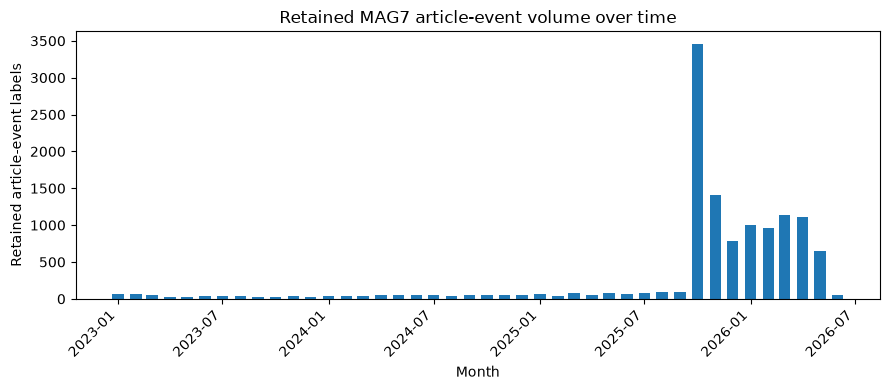

In [ ]:
monthly_counts = (
    events
    .assign(event_month=events["event_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("event_month")
    .size()
    .rename("retained_article_events")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly_counts["event_month"], monthly_counts["retained_article_events"], width=20)
ax.set_xlabel("Month")
ax.set_ylabel("Retained article-event labels")
ax.set_title("Retained MAG7 article-event volume over time")
fig.autofmt_xdate(rotation=45)
fig.tight_layout()

if SAVE_OUTPUTS:
    fig.savefig(OUTPUT_DIR / "retained_article_event_volume_over_time.png", dpi=150)
    monthly_counts.to_csv(OUTPUT_DIR / "retained_article_event_volume_over_time.csv", index=False)

plt.show()

## 4. Build Article-Event Features

Builds the article-event categorical features, market-context features and interaction features, before the final return label gets attached. Same-day article coverage counts are log-scaled.

In [5]:
def add_price_context(price_df: pd.DataFrame, prefix: str, group_col: str | None = None) -> pd.DataFrame:
    out = price_df.sort_values(([group_col] if group_col else []) + ["date"]).copy()
    grouped = out.groupby(group_col, group_keys=False) if group_col else [(None, out)]
    parts = []

    for _, g in grouped:
        g = g.sort_values("date").copy()
        px = pd.to_numeric(g["adj_close"], errors="coerce")
        daily = px.pct_change()

        for window in [1, 3, 5, 20]:
            g[f"{prefix}_ret_{window}d_pre"] = px.pct_change(window).shift(1)

        g[f"{prefix}_abs_ret_1d_pre"] = daily.abs().shift(1)
        g[f"{prefix}_vol_5d_pre"] = daily.rolling(5).std().shift(1)
        g[f"{prefix}_vol_20d_pre"] = daily.rolling(20).std().shift(1)
        parts.append(g)

    return pd.concat(parts, ignore_index=True)


ticker_ctx = add_price_context(prices, "ticker", "ticker")
sp500_ctx = add_price_context(sp500, "sp500", None).drop(columns=["ticker"], errors="ignore")

ctx = events.merge(
    ticker_ctx[[
        "ticker", "date", "ticker_ret_1d_pre", "ticker_ret_3d_pre", "ticker_ret_5d_pre", "ticker_ret_20d_pre",
        "ticker_abs_ret_1d_pre", "ticker_vol_5d_pre", "ticker_vol_20d_pre",
    ]],
    left_on=["ticker", "event_date"],
    right_on=["ticker", "date"],
    how="left",
).drop(columns=["date"], errors="ignore")

ctx = ctx.merge(
    sp500_ctx[[
        "date", "sp500_ret_1d_pre", "sp500_ret_3d_pre", "sp500_ret_5d_pre", "sp500_ret_20d_pre",
        "sp500_abs_ret_1d_pre", "sp500_vol_5d_pre", "sp500_vol_20d_pre",
    ]],
    left_on="event_date",
    right_on="date",
    how="left",
).drop(columns=["date"], errors="ignore")

for h in ["1d", "3d", "5d", "20d"]:
    ctx[f"relative_ret_{h}_pre"] = ctx[f"ticker_ret_{h}_pre"] - ctx[f"sp500_ret_{h}_pre"]

ctx = ctx.sort_values(["ticker", "time_published", "article_uid"]).reset_index(drop=True)
ctx["event_density_ticker_7d"] = 0.0
ctx["event_density_ticker_30d"] = 0.0
ctx["similar_density_ticker_30d"] = 0.0

for ticker, group in ctx.groupby("ticker"):
    for idx, ts, event_type, direction in zip(
        group.index,
        group["time_published"],
        group["event_type"],
        group["direction"],
    ):
        prev = group.loc[group["time_published"].lt(ts)]
        last7 = prev.loc[prev["time_published"].ge(ts - pd.Timedelta(days=7))]
        last30 = prev.loc[prev["time_published"].ge(ts - pd.Timedelta(days=30))]
        similar30 = last30.loc[
            last30["event_type"].eq(event_type)
            | last30["direction"].eq(direction)
        ]

        ctx.loc[idx, "event_density_ticker_7d"] = len(last7)
        ctx.loc[idx, "event_density_ticker_30d"] = len(last30)
        ctx.loc[idx, "similar_density_ticker_30d"] = len(similar30)

hour = ctx["time_published"].dt.hour + ctx["time_published"].dt.minute / 60
ctx["hour_sin_01"] = (np.sin(2 * np.pi * hour / 24) + 1) / 2
ctx["hour_cos_01"] = (np.cos(2 * np.pi * hour / 24) + 1) / 2
ctx["is_monday"] = (ctx["event_date"].dt.weekday == 0).astype(float)
ctx["is_friday"] = (ctx["event_date"].dt.weekday == 4).astype(float)

display(ctx[[
    "ticker", "time_published", "event_date", "event_type", "direction", "confidence",
    "relative_ret_5d_pre", "sp500_vol_5d_pre", "ticker_vol_5d_pre",
    "event_density_ticker_7d", "event_density_ticker_30d", "similar_density_ticker_30d",
]].head(10))

,ticker,time_published,event_date,event_type,direction,confidence,relative_ret_5d_pre,sp500_vol_5d_pre,ticker_vol_5d_pre,event_density_ticker_7d,event_density_ticker_30d,similar_density_ticker_30d
0,AAPL,2023-01-04 11:52:00+00:00,2023-01-04,major_customer_contract,positive,high,NaN,NaN,NaN,0.0,0.0,0.0
1,AAPL,2023-01-05 03:59:02+00:00,2023-01-05,novel_product_event,positive,high,NaN,NaN,NaN,1.0,1.0,1.0
2,AAPL,2023-01-06 04:31:08+00:00,2023-01-06,supply_chain_production_disruption,negative,high,NaN,NaN,NaN,2.0,2.0,0.0
3,AAPL,2023-01-11 01:39:00+00:00,2023-01-11,novel_product_event,positive,high,0.020384,0.012639,0.017345,3.0,3.0,2.0
4,AAPL,2023-01-11 04:03:16+00:00,2023-01-11,demand_supply_revision,negative,high,0.020384,0.012639,0.017345,4.0,4.0,1.0
5,AAPL,2023-01-11 04:31:49+00:00,2023-01-11,regulatory_legal_outcome,negative,high,0.020384,0.012639,0.017345,5.0,5.0,2.0
6,AAPL,2023-01-13 03:59:02+00:00,2023-01-13,management_leadership_change,negative,high,0.021136,0.009179,0.015566,4.0,6.0,3.0
7,AAPL,2023-01-13 03:59:02+00:00,2023-01-13,management_leadership_change,negative,high,0.021136,0.009179,0.015566,4.0,6.0,3.0
8,AAPL,2023-01-13 11:45:00+00:00,2023-01-13,strategy_capital_allocation,positive,high,0.021136,0.009179,0.015566,5.0,8.0,3.0
9,AAPL,2023-01-19 13:12:00+00:00,2023-01-19,supply_chain_production_disruption,negative,high,0.031817,0.010460,0.010278,3.0,9.0,5.0


## 5. Chronological Split And Feature Sets

Assigns each event to train/validation/test and defines the feature groups used by each model variant.

In [ ]:
def assign_period(d):
    d = pd.Timestamp(d)
    if pd.Timestamp(TRAINING[0]) <= d <= pd.Timestamp(TRAINING[1]):
        return "training"
    if pd.Timestamp(VALIDATION[0]) <= d <= pd.Timestamp(VALIDATION[1]):
        return "validation"
    if pd.Timestamp(TEST[0]) <= d <= pd.Timestamp(TEST[1]):
        return "test"
    return "outside"


ctx["period"] = ctx["event_date"].map(assign_period)
fit_mask = ctx["period"].eq("training")


def fit_abs_scale(col, q=0.80):
    s = pd.to_numeric(ctx.loc[fit_mask, col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    scale = s.abs().quantile(q)
    return float(scale) if np.isfinite(scale) and scale != 0 else 1.0


def fit_quantile(col, q, fallback=1.0):
    s = pd.to_numeric(ctx.loc[fit_mask, col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    value = s.quantile(q)
    return float(value) if np.isfinite(value) and value != 0 else fallback


def soft_pos_with_scale(s, scale):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return (s.clip(lower=0) / scale).clip(0, 1).fillna(0)


def soft_neg_with_scale(s, scale):
    return soft_pos_with_scale(-pd.to_numeric(s, errors="coerce"), scale)


def soft_low_with_cutoff(s, cutoff):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return (1 - (s / cutoff)).clip(0, 1).fillna(0)


def soft_high_with_cutoff(s, cutoff):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return (s / cutoff - 1).clip(0, 1).fillna(0)


ticker_5d_scale = fit_abs_scale("ticker_ret_5d_pre")
market_5d_scale = fit_abs_scale("sp500_ret_5d_pre")
relative_5d_scale = fit_abs_scale("relative_ret_5d_pre")

ctx["ticker_prior_up_5d"] = soft_pos_with_scale(ctx["ticker_ret_5d_pre"], ticker_5d_scale)
ctx["ticker_prior_down_5d"] = soft_neg_with_scale(ctx["ticker_ret_5d_pre"], ticker_5d_scale)
ctx["market_prior_up_5d"] = soft_pos_with_scale(ctx["sp500_ret_5d_pre"], market_5d_scale)
ctx["market_prior_down_5d"] = soft_neg_with_scale(ctx["sp500_ret_5d_pre"], market_5d_scale)
ctx["relative_prior_up_5d"] = soft_pos_with_scale(ctx["relative_ret_5d_pre"], relative_5d_scale)
ctx["relative_prior_down_5d"] = soft_neg_with_scale(ctx["relative_ret_5d_pre"], relative_5d_scale)
ctx["quiet_market_5d"] = soft_low_with_cutoff(ctx["sp500_vol_5d_pre"], fit_quantile("sp500_vol_5d_pre", 0.40))
ctx["volatile_market_5d"] = soft_high_with_cutoff(ctx["sp500_vol_5d_pre"], fit_quantile("sp500_vol_5d_pre", 0.70))
ctx["quiet_ticker_5d"] = soft_low_with_cutoff(ctx["ticker_vol_5d_pre"], fit_quantile("ticker_vol_5d_pre", 0.40))
ctx["volatile_ticker_5d"] = soft_high_with_cutoff(ctx["ticker_vol_5d_pre"], fit_quantile("ticker_vol_5d_pre", 0.70))

for col in ["event_density_ticker_7d", "event_density_ticker_30d", "similar_density_ticker_30d"]:
    denom = max(ctx.loc[fit_mask, col].quantile(0.95), 1)
    ctx[col + "_01"] = (ctx[col] / denom).clip(0, 1)

ctx["novel_context_30d"] = (1 - ctx["similar_density_ticker_30d_01"]).clip(0, 1)

dummy_parts = []
dummy_cols = []
categorical_cols = ["event_type", "direction", "confidence", "company_relevance"]

for col in categorical_cols:
    categories = sorted(set(ctx.loc[fit_mask, col].fillna("missing").astype(str)))
    values = ctx[col].fillna("missing").astype(str)
    for category in categories:
        dummy_name = f"{col}_{category}"
        dummy_parts.append(values.eq(category).astype(float).rename(dummy_name))
        dummy_cols.append(dummy_name)

dummies = pd.concat(dummy_parts, axis=1) if dummy_parts else pd.DataFrame(index=ctx.index)
ctx = pd.concat([ctx, dummies], axis=1)

count_feature_cols = []
for col in ["same_day_article_event_count", "same_day_event_type_direction_count"]:
    feature_col = f"log1p_{col}"
    ctx[feature_col] = np.log1p(pd.to_numeric(ctx[col], errors="coerce").fillna(0))
    denom = max(ctx.loc[fit_mask, feature_col].quantile(0.95), 1e-9)
    ctx[feature_col] = (ctx[feature_col] / denom).clip(0, 1)
    count_feature_cols.append(feature_col)

ctx["article_event_weight_01"] = pd.to_numeric(ctx["article_event_weight"], errors="coerce").fillna(0).clip(0, 1)

context_cols = [
    "ticker_prior_up_5d", "ticker_prior_down_5d", "market_prior_up_5d", "market_prior_down_5d",
    "relative_prior_up_5d", "relative_prior_down_5d", "quiet_market_5d", "volatile_market_5d",
    "quiet_ticker_5d", "volatile_ticker_5d",
    "event_density_ticker_7d_01", "event_density_ticker_30d_01", "similar_density_ticker_30d_01",
    "novel_context_30d", "hour_sin_01", "hour_cos_01", "is_monday", "is_friday",
]

# qwen_cols refers to news-derived features
qwen_cols = list(dummies.columns) + count_feature_cols + ["article_event_weight_01", "has_article_event"]

interaction_qwen_cols = [
    c for c in dummy_cols
    if c.startswith("event_type_")
    or c.startswith("direction_")
]

interaction_context_cols = [
    "relative_prior_up_5d", "relative_prior_down_5d", "quiet_market_5d", "volatile_market_5d",
    "quiet_ticker_5d", "volatile_ticker_5d", "event_density_ticker_7d_01", "novel_context_30d",
]

interaction_data = {}
for q in interaction_qwen_cols:
    for c in interaction_context_cols:
        name = f"interaction__{q}__x__{c}"
        interaction_data[name] = ctx[q].fillna(0) * ctx[c].fillna(0)

interaction_cols = list(interaction_data.keys())
if interaction_data:
    ctx = pd.concat([ctx, pd.DataFrame(interaction_data, index=ctx.index)], axis=1)

feature_df = ctx.loc[ctx["period"].isin(["training", "validation", "test"])].copy()

for col in qwen_cols + context_cols + interaction_cols:
    feature_df[col] = pd.to_numeric(feature_df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 1)

rule_block_feature_cols = {
    "qwen_semantic": list(qwen_cols),
    "market_context": list(context_cols),
    "qwen_context_interaction": list(interaction_cols),
}

variant_specs = {
    "full_ltn_qwen_only": {"feature_cols": qwen_cols, "rule_blocks": ["qwen_semantic"]},
    "full_ltn_context_only": {"feature_cols": context_cols, "rule_blocks": ["market_context"]},
    "full_ltn_qwen_plus_context": {"feature_cols": qwen_cols + context_cols, "rule_blocks": ["qwen_semantic", "market_context"]},
    "full_ltn_qwen_context_interaction": {"feature_cols": qwen_cols + context_cols + interaction_cols, "rule_blocks": ["qwen_semantic", "market_context", "qwen_context_interaction"]},
}

for spec in variant_specs.values():
    spec["feature_cols"] = list(dict.fromkeys(spec["feature_cols"]))
    spec["return_col"] = "simple_return"

feature_manifest = pd.DataFrame([
    {
        "variant": name,
        "n_features": len(spec["feature_cols"]),
        "rule_blocks": ", ".join(spec["rule_blocks"]),
        "is_primary_variant": name == PRIMARY_VARIANT,
        "features": ", ".join(spec["feature_cols"]),
    }
    for name, spec in variant_specs.items()
])

display(feature_df["period"].value_counts().rename("article_event_labels").to_frame())
display(feature_manifest)

if SAVE_OUTPUTS:
    feature_manifest.to_csv(OUTPUT_DIR / "full_ltn_feature_manifest.csv", index=False)

,article_event_labels
period,
training,7349
test,2957
validation,1966


,variant,n_features,rule_blocks,is_primary_variant,features
0,full_ltn_qwen_only,22,qwen_semantic,False,"event_type_cybersecurity_privacy_incident, eve..."
1,full_ltn_context_only,18,market_context,False,"ticker_prior_up_5d, ticker_prior_down_5d, mark..."
2,full_ltn_qwen_plus_context,40,"qwen_semantic, market_context",False,"event_type_cybersecurity_privacy_incident, eve..."
3,full_ltn_qwen_context_interaction,160,"qwen_semantic, market_context, qwen_context_in...",True,"event_type_cybersecurity_privacy_incident, eve..."


## 6. Model And Evaluation Helpers

Defines the softmax classifier, LTN predicates, rule-mining utilities, the training loop, and the scoring/summary-metric helpers used everywhere below.

In [ ]:
class OutcomeSoftmaxMLP(nn.Module):
    def __init__(self, input_dim, n_classes=3):
        super().__init__()
        hidden = max(12, min(80, input_dim * 2))
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class ClassPredicate(nn.Module):
    def __init__(self, classifier, class_index):
        super().__init__()
        self.classifier = classifier
        self.class_index = class_index

    def forward(self, x):
        logits = self.classifier(x)
        probs = torch.softmax(logits, dim=1)
        return probs[:, self.class_index].reshape(-1)


def truth_value(obj):
    return obj.value if hasattr(obj, "value") else obj


def feature_tensor(data, cols):
    x = (
        data[cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .clip(0, 1)
        .to_numpy(dtype=np.float32)
    )
    return torch.tensor(x, dtype=torch.float32, device=device)


def target_tensor(data):
    """
        Cross-entropy expects integer class labels, not one-hot MSE targets.
    """
    label_to_idx = {label: i for i, label in enumerate(LABELS)}
    y = data["target_label"].map(label_to_idx).to_numpy()
    return torch.tensor(y, dtype=torch.long, device=device)


def label_return_alignment(data, label, return_col):
    ret = pd.to_numeric(data[return_col], errors="coerce")

    if label == "bullish":
        signed = ret
    elif label == "bearish":
        signed = -ret
    else:
        signed = -ret.abs()

    signed = signed.dropna()

    if len(signed) < 3:
        return np.nan, np.nan

    if label == "neutral":
        p = np.nan
    else:
        p = binomtest(
            int((signed > 0).sum()),
            len(signed),
            0.5,
            alternative="greater",
        ).pvalue

    return float(100 * signed.mean()), float(p) if np.isfinite(p) else np.nan


def empirical_rule_stats(data, condition_cols, label, return_col):
    if len(data) == 0:
        return {
            "n": 0,
            "accuracy_pct": np.nan,
            "aligned_mean_pct": np.nan,
            "aligned_signflip_p": np.nan,
        }

    active = np.ones(len(data), dtype=bool)

    for col in condition_cols:
        active &= (
            pd.to_numeric(data[col], errors="coerce")
            .fillna(0)
            .to_numpy()
            >= ANTECEDENT_THRESHOLD
        )

    subset = data.loc[active].copy()

    if subset.empty:
        return {
            "n": 0,
            "accuracy_pct": np.nan,
            "aligned_mean_pct": np.nan,
            "aligned_signflip_p": np.nan,
        }

    aligned_mean, p = label_return_alignment(subset, label, return_col)

    return {
        "n": int(len(subset)),
        "accuracy_pct": float(100 * subset["target_label"].eq(label).mean()),
        "aligned_mean_pct": aligned_mean,
        "aligned_signflip_p": p,
    }


def infer_rule_block(feature_name):
    if feature_name.startswith("interaction__"):
        return "qwen_context_interaction"

    context_feature_names = {
        "ticker_prior_up_5d", "ticker_prior_down_5d",
        "market_prior_up_5d", "market_prior_down_5d",
        "relative_prior_up_5d", "relative_prior_down_5d",
        "quiet_market_5d", "volatile_market_5d",
        "quiet_ticker_5d", "volatile_ticker_5d",
        "event_density_ticker_7d_01", "event_density_ticker_30d_01",
        "similar_density_ticker_30d_01", "novel_context_30d",
        "hour_sin_01", "hour_cos_01", "is_monday", "is_friday",
    }

    if feature_name in context_feature_names:
        return "market_context"

    qwen_prefixes = (
        "event_type_",
        "direction_",
        "confidence_",
        "company_relevance_",
        "log1p_",
        "article_event_weight_",
    )

    if feature_name.startswith(qwen_prefixes) or feature_name == "has_article_event":
        return "qwen_semantic"

    return "unknown"

def mine_validated_rules(
    data,
    feature_cols,
    return_col,
    rule_blocks=None,
    max_pair_features=36,
    max_rules_per_label=12,
):
    training_df = data.loc[data["period"].eq("training")].copy()
    validation_df = data.loc[data["period"].eq("validation")].copy()

    cols = [c for c in feature_cols if c in data.columns]

    if rule_blocks is not None:
        allowed_blocks = set(rule_blocks)
        cols = [c for c in cols if infer_rule_block(c) in allowed_blocks]

    active_counts = (
        training_df[cols]
        .ge(ANTECEDENT_THRESHOLD)
        .sum()
        .sort_values(ascending=False)
    )

    pair_base = active_counts.head(max_pair_features).index.tolist()
    candidates = [(c,) for c in cols] + list(combinations(pair_base, 2))

    rows = []

    for condition_cols in candidates:
        condition_cols = tuple(condition_cols)

        for label in LABELS:
            disc = empirical_rule_stats(
                training_df,
                condition_cols,
                label,
                return_col,
            )

            if disc["n"] < MIN_TRAINING_EVENTS or not np.isfinite(disc["accuracy_pct"]):
                continue

            val = empirical_rule_stats(
                validation_df,
                condition_cols,
                label,
                return_col,
            )

            if val["n"] < MIN_VALIDATION_EVENTS or not np.isfinite(val["accuracy_pct"]):
                continue

            score = (
                disc["accuracy_pct"] / 100
                + val["accuracy_pct"] / 100
                + min(disc["n"] / 40, 1)
                + min(val["n"] / 30, 1)
            )

            if label != "neutral" and np.isfinite(disc["aligned_mean_pct"]):
                score += min(max(disc["aligned_mean_pct"], 0) / 2, 1)

            if label == "neutral" and np.isfinite(disc["aligned_mean_pct"]):
                score += min(max(-disc["aligned_mean_pct"], 0) / 1, 1)

            rows.append({
                "condition": " & ".join(condition_cols),
                "condition_cols_json": json.dumps(condition_cols),
                "rule_label": label,
                "rule_score": score,
                "rule_blocks": ", ".join(
                    sorted({infer_rule_block(c) for c in condition_cols})
                ),
                **{f"training_{k}": v for k, v in disc.items()},
                **{f"validation_{k}": v for k, v in val.items()},
            })

    candidates_df = pd.DataFrame(rows)

    if candidates_df.empty:
        return candidates_df, candidates_df

    selected = candidates_df.loc[
        candidates_df["training_accuracy_pct"].ge(MIN_TRAINING_ACCURACY)
        & candidates_df["validation_accuracy_pct"].ge(MIN_VALIDATION_ACCURACY)
    ].copy()

    selected = selected.sort_values(
        ["rule_label", "validation_accuracy_pct", "validation_n", "rule_score"],
        ascending=[True, False, False, False],
    )

    selected = selected.groupby("rule_label", group_keys=False).head(max_rules_per_label)

    selected = selected.sort_values(
        ["validation_accuracy_pct", "validation_n", "rule_score"],
        ascending=False,
    ).reset_index(drop=True)

    return (
        candidates_df.sort_values("rule_score", ascending=False).reset_index(drop=True),
        selected,
    )

def mine_training_only_rules(
    data,
    feature_cols,
    return_col,
    rule_blocks=None,
    max_pair_features=36,
    max_rules_per_label=12,
):
    training_df = data.loc[data["period"].eq("training")].copy()

    cols = [c for c in feature_cols if c in data.columns]

    if rule_blocks is not None:
        allowed_blocks = set(rule_blocks)
        cols = [c for c in cols if infer_rule_block(c) in allowed_blocks]

    active_counts = (
        training_df[cols]
        .ge(ANTECEDENT_THRESHOLD)
        .sum()
        .sort_values(ascending=False)
    )

    pair_base = active_counts.head(max_pair_features).index.tolist()
    candidates = [(c,) for c in cols] + list(combinations(pair_base, 2))

    rows = []

    for condition_cols in candidates:
        condition_cols = tuple(condition_cols)

        for label in LABELS:
            disc = empirical_rule_stats(
                training_df,
                condition_cols,
                label,
                return_col,
            )

            if disc["n"] < MIN_TRAINING_EVENTS or not np.isfinite(disc["accuracy_pct"]):
                continue

            score = disc["accuracy_pct"] / 100 + min(disc["n"] / 40, 1)

            rows.append({
                "condition": " & ".join(condition_cols),
                "condition_cols_json": json.dumps(condition_cols),
                "rule_label": label,
                "rule_score": score,
                "rule_selection_scope": "training_only",
                "rule_blocks": ", ".join(sorted({infer_rule_block(c) for c in condition_cols})),
                **{f"training_{k}": v for k, v in disc.items()},
            })

    candidates_df = pd.DataFrame(rows)

    if candidates_df.empty:
        return candidates_df, candidates_df

    selected = candidates_df.loc[
        candidates_df["training_accuracy_pct"].ge(MIN_TRAINING_ACCURACY)
    ].copy()

    selected = selected.sort_values(
        ["rule_label", "training_accuracy_pct", "training_n", "rule_score"],
        ascending=[True, False, False, False],
    )

    selected = selected.groupby("rule_label", group_keys=False).head(max_rules_per_label)

    selected = selected.sort_values(
        ["training_accuracy_pct", "training_n", "rule_score"],
        ascending=False,
    ).reset_index(drop=True)

    return (
        candidates_df.sort_values("rule_score", ascending=False).reset_index(drop=True),
        selected,
    )


class FeaturePredicate(nn.Module):
    def __init__(self, index):
        super().__init__()
        self.index = index

    def forward(self, z):
        return z[:, self.index].reshape(-1, 1)


def make_feature_predicates(feature_cols):
    preds = {}

    for i, col in enumerate(feature_cols):
        preds[col] = ltn.Predicate(model=FeaturePredicate(i).to(device))

    return preds


def antecedent_from_rule(cols, feat_preds, x, AndOp):
    expr = truth_value(feat_preds[cols[0]](x))

    for col in cols[1:]:
        expr = AndOp(expr, truth_value(feat_preds[col](x)))

    return expr


def train_variant(
    name,
    spec,
    train_df,
    use_logic=True,
    logic_weight=LOGIC_WEIGHT,
    seed=SEED,
    mine_rules=True,
):
    reset_seed(seed)

    feature_cols = spec["feature_cols"]
    return_col = spec["return_col"]

    if use_logic and mine_rules:
        candidates, selected_rules = mine_validated_rules(
            train_df,
            feature_cols,
            return_col,
            rule_blocks=spec.get("rule_blocks"),
            max_pair_features=spec.get("max_pair_features", 36),
            max_rules_per_label=spec.get("max_rules_per_label", 12),
        )

    elif use_logic and not mine_rules:
        candidates = pd.DataFrame()

        if "selected_rules" not in spec:
            raise ValueError(
                f"{name} was called with mine_rules=False, "
                "but spec['selected_rules'] was not provided."
            )

        selected_rules = spec["selected_rules"].copy()

    else:
        candidates = pd.DataFrame()
        selected_rules = pd.DataFrame()

    if SAVE_OUTPUTS and use_logic:
        candidates.to_csv(
            OUTPUT_DIR / f"{name}_candidate_mined_rules.csv",
            index=False,
        )
        selected_rules.to_csv(
            OUTPUT_DIR / f"{name}_selected_validated_rules.csv",
            index=False,
        )

    X = feature_tensor(train_df, feature_cols)
    x = ltn.Variable(f"x_{name}", X)
    y = target_tensor(train_df)

    feat_preds = make_feature_predicates(feature_cols)

    classifier = OutcomeSoftmaxMLP(X.shape[1], n_classes=len(LABELS)).to(device)

    Bearish = ltn.Predicate(model=ClassPredicate(classifier, 0).to(device))
    Bullish = ltn.Predicate(model=ClassPredicate(classifier, 1).to(device))
    Neutral = ltn.Predicate(model=ClassPredicate(classifier, 2).to(device))

    AndOp = ltn.fuzzy_ops.AndProd()
    ImpliesOp = ltn.fuzzy_ops.ImpliesReichenbach()
    ForallAgg = ltn.fuzzy_ops.AggregPMeanError(p=2)
    SatAgg = ltn.fuzzy_ops.SatAgg()

    label_predicates = {
        "bearish": Bearish,
        "bullish": Bullish,
        "neutral": Neutral,
    }

    rule_specs = []

    for _, rule in selected_rules.iterrows():
        cols = [
            c for c in json.loads(rule["condition_cols_json"])
            if c in feat_preds
        ]

        if cols:
            rule_specs.append((rule["condition"], cols, rule["rule_label"]))

    opt = torch.optim.Adam(classifier.parameters(), lr=LR)

    history = []

    for epoch in range(EPOCHS):
        opt.zero_grad()

        logits = classifier(X)

        pred_bear = truth_value(Bearish(x)).reshape(-1, 1)
        pred_bull = truth_value(Bullish(x)).reshape(-1, 1)
        pred_neut = truth_value(Neutral(x)).reshape(-1, 1)

        supervised = F.cross_entropy(logits, y)

        exclusivity = torch.tensor(0.0, device=device)

        formulas = []

        if use_logic:
            for rule_name, cols, label in rule_specs:
                formulas.append((
                    rule_name,
                    ForallAgg(
                        ImpliesOp(
                            antecedent_from_rule(cols, feat_preds, x, AndOp),
                            truth_value(label_predicates[label](x)),
                        )
                    ),
                ))

        sat = (
            SatAgg(*[formula for _, formula in formulas])
            if formulas
            else torch.tensor(1.0, device=device)
        )

        logic_penalty = (
            logic_weight * (1.0 - truth_value(sat))
            if use_logic
            else torch.tensor(0.0, device=device)
        )

        loss = supervised + logic_penalty
        loss.backward()
        opt.step()

        if epoch % 50 == 0 or epoch == EPOCHS - 1:
            row = {
                "variant": name,
                "epoch": epoch,
                "seed": seed,
                "use_logic": use_logic,
                "mine_rules": mine_rules,
                "logic_weight": logic_weight,
                "loss": float(loss.detach().cpu()),
                "supervised_cross_entropy": float(supervised.detach().cpu()),
                "exclusivity": float(exclusivity.detach().cpu()),
                "sat": float(truth_value(sat).detach().cpu())
                if hasattr(truth_value(sat), "detach")
                else float(sat),
                "n_selected_rules": len(rule_specs),
            }

            for rule_name, formula in formulas[:20]:
                row[f"sat_{rule_name[:80]}"] = float(
                    truth_value(formula).detach().cpu()
                )

            history.append(row)

    return {
        "name": name,
        "seed": seed,
        "feature_cols": feature_cols,
        "candidate_rules": candidates,
        "selected_rules": selected_rules,
        "use_logic": use_logic,
        "mine_rules": mine_rules,
        "logic_weight": logic_weight,
        "classifier": classifier,
        "Bearish": Bearish,
        "Bullish": Bullish,
        "Neutral": Neutral,
        "history": pd.DataFrame(history),
    }

In [ ]:
def cluster_bootstrap_accuracy_ci(scored_df, cluster_cols=("ticker", "event_date"), prediction_col="prediction", n_boot=5000, seed=0):
    df = scored_df.copy()
    df["_correct"] = (df[prediction_col] == df["target_label"]).astype(int)

    per_cluster = df.groupby(list(cluster_cols))["_correct"].agg(["sum", "count"]).reset_index()
    correct = per_cluster["sum"].to_numpy()
    total = per_cluster["count"].to_numpy()
    n_clusters = len(per_cluster)

    rng = np.random.default_rng(seed)
    boot_acc = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n_clusters, size=n_clusters)
        boot_acc[b] = correct[idx].sum() / total[idx].sum()

    return {
        "n_independent_clusters": n_clusters,
        "accuracy_ci_low_pct": float(100 * np.percentile(boot_acc, 2.5)),
        "accuracy_ci_high_pct": float(100 * np.percentile(boot_acc, 97.5)),
    }


def cluster_bootstrap_aligned_stats(scored_df, cluster_cols=("ticker", "event_date"), prediction_col="prediction", n_boot=5000, seed=0):
    df = scored_df.copy()
    ret = pd.to_numeric(df["simple_return"], errors="coerce")
    pred = df[prediction_col]

    df["_signed"] = np.select(
        [pred.eq("bullish"), pred.eq("bearish")],
        [ret, -ret],
        default=np.nan,
    )
    df = df.dropna(subset=["_signed"])

    if df.empty:
        return {
            "n_independent_clusters": 0,
            "aligned_mean_ci_low_pct": np.nan,
            "aligned_mean_ci_high_pct": np.nan,
            "aligned_bootstrap_p_value": np.nan,
        }

    per_cluster = df.groupby(list(cluster_cols))["_signed"].agg(["sum", "count"]).reset_index()
    cluster_sum = per_cluster["sum"].to_numpy()
    cluster_count = per_cluster["count"].to_numpy()
    n_clusters = len(per_cluster)

    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n_clusters, size=n_clusters)
        boot_means[b] = cluster_sum[idx].sum() / cluster_count[idx].sum()

    return {
        "n_independent_clusters": n_clusters,
        "aligned_mean_ci_low_pct": float(100 * np.percentile(boot_means, 2.5)),
        "aligned_mean_ci_high_pct": float(100 * np.percentile(boot_means, 97.5)),
        "aligned_bootstrap_p_value": float((boot_means <= 0).mean()),
    }

In [ ]:
def score_variant(bundle, df):
    out = df.copy()
    X = feature_tensor(out, bundle["feature_cols"])

    bundle["classifier"].eval()

    with torch.no_grad():
        logits = bundle["classifier"](X)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()

    out["score_bearish"] = probs[:, 0]
    out["score_bullish"] = probs[:, 1]
    out["score_neutral"] = probs[:, 2]

    scores = out[["score_bearish", "score_bullish", "score_neutral"]].to_numpy()

    out["prediction"] = np.array(LABELS)[scores.argmax(axis=1)]

    out["confidence_margin"] = (
        np.sort(scores, axis=1)[:, -1]
        - np.sort(scores, axis=1)[:, -2]
    )

    out["max_class_score"] = scores.max(axis=1)

    return out


def aligned_stats(df):
    ret = pd.to_numeric(df["simple_return"], errors="coerce")
    pred = df["prediction"]

    signed = np.select(
        [pred.eq("bullish"), pred.eq("bearish")],
        [ret, -ret],
        default=np.nan,
    )

    signed = pd.Series(signed, index=df.index).dropna()

    if len(signed) < 3:
        return np.nan, np.nan

    p = binomtest(
        int((signed > 0).sum()),
        len(signed),
        0.5,
        alternative="greater",
    ).pvalue

    return float(signed.mean() * 100), float(p)


def summary_row(variant, period, df, bundle=None):
    aligned_mean, aligned_p = aligned_stats(df)

    # aligned_signflip_p is the p value before bootstrap experiments
    # are conducted
    
    cluster_stats = cluster_bootstrap_aligned_stats(df)

    row = {
        "variant": variant,
        "period": period,
        "n": int(len(df)),
        "accuracy_pct": float(100 * df["prediction"].eq(df["target_label"]).mean()),
        "mean_simple_return_pct": float(
            100 * pd.to_numeric(df["simple_return"], errors="coerce").mean()
        ),
        "aligned_mean_pct": aligned_mean,
        "aligned_signflip_p": aligned_p,
        "bullish_pred_rate_pct": float(100 * df["prediction"].eq("bullish").mean()),
        "bearish_pred_rate_pct": float(100 * df["prediction"].eq("bearish").mean()),
        "neutral_pred_rate_pct": float(100 * df["prediction"].eq("neutral").mean()),
        "mean_confidence_margin": float(df["confidence_margin"].mean()),
        "mean_max_class_score": float(df["max_class_score"].mean()),
        **cluster_stats,
    }

    if bundle is not None:
        row["use_logic"] = bundle["use_logic"]
        row["logic_weight"] = bundle["logic_weight"]
        row["n_selected_rules"] = len(bundle["selected_rules"])

    return row


## 7. Horizon Audit (Validation Only)

Compares candidate MAG7 return horizons on training and validation data only.

In [10]:

HORIZON_AUDIT_VARIANT = PRIMARY_VARIANT


def build_model_df_for_horizon(horizon: int) -> pd.DataFrame:
    horizon_returns = simple_returns.loc[
        simple_returns["horizon_days"].eq(int(horizon)),
        ["ticker", "event_date", "simple_return", "event_open", "event_close"],
    ]

    out = (
        feature_df
        .drop(
            columns=[
                "simple_return",
                                "event_open",
                "event_close",
                "target_label",
            ],
            errors="ignore",
        )
        .merge(
            horizon_returns,
            on=["ticker", "event_date"],
            how="left",
        )
    ).copy()

    missing_returns = int(out["simple_return"].isna().sum())
    if missing_returns:
        print(f"{horizon}d horizon: dropping {missing_returns} rows with missing open-to-close returns")
        out = out.loc[out["simple_return"].notna()].copy()

    out["target_label"] = out["simple_return"].map(
        lambda x: realised_label_from_return(float(x), RETURN_THRESHOLD)
    )

    return out


horizon_ltn_rows = []

for horizon in HORIZON_CANDIDATES:
    print(f"LTN horizon audit: open to {horizon}-day close return")

    model_df_h = build_model_df_for_horizon(horizon)

    train_h = model_df_h.loc[model_df_h["period"].eq("training")].copy()
    validation_h = model_df_h.loc[model_df_h["period"].eq("validation")].copy()

    spec_base_h = variant_specs[HORIZON_AUDIT_VARIANT].copy()

    candidate_rules_h, selected_rules_h = mine_training_only_rules(
        train_h,
        spec_base_h["feature_cols"],
        spec_base_h["return_col"],
        rule_blocks=spec_base_h.get("rule_blocks"),
        max_pair_features=spec_base_h.get("max_pair_features", 36),
        max_rules_per_label=spec_base_h.get("max_rules_per_label", 12),
    )

    spec_h = spec_base_h.copy()
    spec_h["selected_rules"] = selected_rules_h.copy()

    bundle_h = train_variant(
        f"{HORIZON_AUDIT_VARIANT}_horizon_{horizon}d",
        spec_h,
        train_h,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=SEED,
        mine_rules=False,
    )

    scored_validation_h = score_variant(bundle_h, validation_h)

    row_h = summary_row(
        f"LTN horizon {horizon}d",
        "validation",
        scored_validation_h,
        bundle=bundle_h,
    )

    majority_baseline_h = validation_h["target_label"].value_counts(normalize=True).max() * 100

    row_h["horizon_days"] = horizon
    row_h["training_n"] = len(train_h)
    row_h["validation_n"] = len(validation_h)
    row_h["validation_majority_baseline_pct"] = float(majority_baseline_h)
    row_h["validation_bullish_n"] = int(validation_h["target_label"].eq("bullish").sum())
    row_h["validation_bearish_n"] = int(validation_h["target_label"].eq("bearish").sum())
    row_h["validation_neutral_n"] = int(validation_h["target_label"].eq("neutral").sum())
    row_h["n_candidate_rules"] = len(candidate_rules_h)
    row_h["n_selected_rules"] = len(selected_rules_h)

    horizon_ltn_rows.append(row_h)


horizon_ltn_audit = pd.DataFrame(horizon_ltn_rows)

display(
    horizon_ltn_audit.sort_values(
        ["accuracy_pct", "aligned_mean_pct", "n_selected_rules"],
        ascending=False,
    )
)


LTN horizon audit: open to 1-day close return
LTN horizon audit: open to 2-day close return
2d horizon: dropping 57 rows with missing open-to-close returns
LTN horizon audit: open to 3-day close return
3d horizon: dropping 99 rows with missing open-to-close returns
LTN horizon audit: open to 4-day close return
4d horizon: dropping 147 rows with missing open-to-close returns
LTN horizon audit: open to 5-day close return
5d horizon: dropping 182 rows with missing open-to-close returns


,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,mean_max_class_score,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,use_logic,logic_weight,n_selected_rules,horizon_days,training_n,validation_n,validation_majority_baseline_pct,validation_bullish_n,validation_bearish_n,validation_neutral_n,n_candidate_rules
4,LTN horizon 5d,validation,1966,50.152594,-1.141053,0.379725,3.571733e-07,52.746694,41.353001,5.900305,0.808771,0.898621,253,-0.060508,0.830258,0.0416,True,0.3,24,5,7349,1966,54.984741,801,1081,84,2139
3,LTN horizon 4d,validation,1966,48.219736,-0.963437,0.299480,7.294687e-05,51.424212,38.962360,9.613428,0.819577,0.904766,256,-0.145260,0.743486,0.0896,True,0.3,26,4,7349,1966,53.611394,796,1054,116,2139
1,LTN horizon 2d,validation,1966,43.845371,-0.302738,0.211323,3.915452e-02,33.214649,56.663276,10.122075,0.835236,0.912712,253,-0.081774,0.490751,0.0700,True,0.3,36,2,7349,1966,47.456765,741,933,292,2139
2,LTN horizon 3d,validation,1966,36.164802,-0.652869,-0.081412,9.844981e-01,49.186165,35.503561,15.310275,0.802190,0.894785,255,-0.431879,0.254016,0.6840,True,0.3,36,3,7349,1966,48.728383,744,958,264,2139
0,LTN horizon 1d,validation,1966,34.893184,-0.202131,0.014229,4.144145e-01,32.756867,36.876907,30.366226,0.831230,0.910890,243,-0.206274,0.253198,0.4590,True,0.3,36,1,7349,1966,43.133266,611,848,507,2139


In [11]:
if SAVE_OUTPUTS:
    horizon_ltn_audit.to_csv(OUTPUT_DIR / "horizon_ltn_audit.csv", index=False)


5-day wins on both accuracy (50.2%) and aligned mean return (0.38%), and it's the only horizon with a cluster-bootstrap p-value under 0.05 (p = 0.042). 4-day trails a fair way behind (48.2% accuracy, p = 0.090, not significant). Hence `PRIMARY_HORIZON = 5` in Section 8.

## 8. Final Modelling Frame

Attaches the five-day return label to the feature matrix and builds the final train/validation/test datasets.

In [ ]:
PRIMARY_HORIZON = 5


In [13]:

model_df = build_model_df_for_horizon(PRIMARY_HORIZON)

train = model_df.loc[model_df["period"].eq("training")].copy()
validation = model_df.loc[model_df["period"].eq("validation")].copy()
test = model_df.loc[model_df["period"].eq("test")].copy()

display(model_df.groupby("period")["target_label"].value_counts().unstack(fill_value=0))

5d horizon: dropping 182 rows with missing open-to-close returns


target_label,bearish,bullish,neutral
period,,,
test,1108,1412,255
training,2847,3936,566
validation,1081,801,84


In [ ]:
# recomputes the table shown above, no modelling logic here.
period_label_counts = model_df.groupby("period")["target_label"].value_counts().unstack(fill_value=0)

if SAVE_OUTPUTS:
    period_label_counts.to_csv(OUTPUT_DIR / "period_label_counts.csv")


## 9. Full Classifier: Frozen-Rule Evaluation

Rules are selected on training and validation data, frozen, then carried into the final refit before test evaluation.

In [15]:
train_val = model_df.loc[model_df["period"].isin(["training", "validation"])].copy()

frozen_variant_specs = {}

for name, spec in variant_specs.items():
    print("selecting frozen rules", name)

    candidate_rules, selected_rules = mine_validated_rules(
        train_val,
        spec["feature_cols"],
        spec["return_col"],
        rule_blocks=spec.get("rule_blocks"),
        max_pair_features=spec.get("max_pair_features", 36),
        max_rules_per_label=spec.get("max_rules_per_label", 12),
    )

    frozen_spec = spec.copy()
    frozen_spec["selected_rules"] = selected_rules.copy()
    frozen_variant_specs[name] = frozen_spec


trained_final = {}

for name, spec in frozen_variant_specs.items():
    print("final frozen-rule training", name, "rows", len(train_val))

    trained_final[name] = train_variant(
        name,
        spec,
        train_val,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=SEED,
        mine_rules=False,
    )


final_rows = []
final_frames = []

for variant, bundle in trained_final.items():
    scored = score_variant(bundle, test)

    final_rows.append(
        summary_row(
            variant,
            "test_frozen_rules_refit_training_validation",
            scored,
            bundle=bundle,
        )
    )

    final_frames.append(
        scored.assign(
            variant=variant,
            period="test_frozen_rules_refit_training_validation",
        )
    )


final_summary = pd.DataFrame(final_rows)

if SAVE_OUTPUTS:
    final_summary.to_csv(
        OUTPUT_DIR / "full_ltn_final_frozen_rule_test_summary.csv",
        index=False,
    )

    pd.concat(final_frames, ignore_index=True).to_csv(
        OUTPUT_DIR / "full_ltn_final_frozen_rule_test_predictions.csv",
        index=False,
    )


display(
    final_summary.sort_values(
        ["accuracy_pct", "aligned_mean_pct"],
        ascending=False,
    )
)

selecting frozen rules full_ltn_qwen_only
selecting frozen rules full_ltn_context_only
selecting frozen rules full_ltn_qwen_plus_context
selecting frozen rules full_ltn_qwen_context_interaction
final frozen-rule training full_ltn_qwen_only rows 9315
final frozen-rule training full_ltn_context_only rows 9315
final frozen-rule training full_ltn_qwen_plus_context rows 9315
final frozen-rule training full_ltn_qwen_context_interaction rows 9315


,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,mean_max_class_score,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,use_logic,logic_weight,n_selected_rules
1,full_ltn_context_only,test_frozen_rules_refit_training_validation,2775,49.441441,1.09779,0.778287,1.625191e-12,50.918919,41.369369,7.711712,0.592524,0.771567,334,0.099836,1.467865,0.0124,True,0.3,14
2,full_ltn_qwen_plus_context,test_frozen_rules_refit_training_validation,2775,44.684685,1.09779,0.286512,1.069355e-02,52.396396,40.792793,6.810811,0.740647,0.861177,345,-0.298124,0.901505,0.1836,True,0.3,24
0,full_ltn_qwen_only,test_frozen_rules_refit_training_validation,2775,43.027027,1.09779,-0.222804,9.862899e-01,43.099099,56.612613,0.288288,0.224873,0.576125,349,-0.561437,0.108768,0.9078,True,0.3,7
3,full_ltn_qwen_context_interaction,test_frozen_rules_refit_training_validation,2775,42.774775,1.09779,0.226446,7.230329e-01,59.099099,33.477477,7.423423,0.797237,0.890877,346,-0.337746,0.831608,0.2262,True,0.3,24


`full_ltn_context_only`  comes out both the most accurate variant (49.4%) and strongest cluster-bootstrap test (p = 0.012). `full_ltn_qwen_context_interaction`, is used as `PRIMARY_VARIANT` throughout the ablations and selective-classifier sections below, but is actually the least accurate of the four (42.8%) and isn't significant here (p = 0.226). 

In [ ]:

RETURN_THRESHOLD_CANDIDATES = [0.005, 0.0075, 0.01, 0.0125, 0.015, 0.02]
THRESHOLD_AUDIT_HORIZON = PRIMARY_HORIZON
THRESHOLD_AUDIT_VARIANT = PRIMARY_VARIANT
THRESHOLD_AUDIT_SEED = SEED
THRESHOLD_AUDIT_EPOCHS = 250  # sped-up for audit; final model uses EPOCHS

def realised_label_from_return_at_threshold(value, threshold):
    if pd.isna(value):
        return "neutral"
    if value > threshold:
        return "bullish"
    if value < -threshold:
        return "bearish"
    return "neutral"


def build_model_df_for_horizon_and_threshold(horizon, threshold):
    horizon_returns = simple_returns.loc[
        simple_returns["horizon_days"].eq(int(horizon)),
        ["ticker", "event_date", "simple_return", "event_open", "event_close"],
    ]

    out = (
        feature_df
        .drop(
            columns=[
                "simple_return",
                                "event_open",
                "event_close",
                "target_label",
            ],
            errors="ignore",
        )
        .merge(
            horizon_returns,
            on=["ticker", "event_date"],
            how="left",
        )
    ).copy()

    missing_returns = int(out["simple_return"].isna().sum())

    if missing_returns:
        print(
            f"threshold audit: horizon {horizon}, threshold {threshold}: "
            f"dropping {missing_returns} rows with missing open-to-close returns"
        )
        out = out.loc[out["simple_return"].notna()].copy()

    out["target_label"] = out["simple_return"].map(
        lambda x: realised_label_from_return_at_threshold(float(x), threshold)
    )

    return out


threshold_audit_rows = []
threshold_audit_label_rows = []

old_epochs = EPOCHS
EPOCHS = THRESHOLD_AUDIT_EPOCHS

try:
    for threshold in RETURN_THRESHOLD_CANDIDATES:
        print(f"Return-threshold audit: threshold = {threshold:.4f}")

        model_df_t = build_model_df_for_horizon_and_threshold(
            THRESHOLD_AUDIT_HORIZON,
            threshold,
        )

        train_t = model_df_t.loc[model_df_t["period"].eq("training")].copy()
        validation_t = model_df_t.loc[model_df_t["period"].eq("validation")].copy()

        label_counts = (
            model_df_t
            .groupby("period")["target_label"]
            .value_counts()
            .unstack(fill_value=0)
            .reindex(columns=LABELS, fill_value=0)
            .reset_index()
        )

        label_counts["return_threshold"] = threshold
        label_counts["horizon_days"] = THRESHOLD_AUDIT_HORIZON
        threshold_audit_label_rows.append(label_counts)

        majority_baseline = (
            validation_t["target_label"]
            .value_counts(normalize=True)
            .max()
            * 100
        )

        spec_base = variant_specs[THRESHOLD_AUDIT_VARIANT].copy()

        candidate_rules_t, selected_rules_t = mine_training_only_rules(
            train_t,
            spec_base["feature_cols"],
            spec_base["return_col"],
            rule_blocks=spec_base.get("rule_blocks"),
            max_pair_features=spec_base.get("max_pair_features", 36),
            max_rules_per_label=spec_base.get("max_rules_per_label", 12),
        )

        spec_t = spec_base.copy()
        spec_t["selected_rules"] = selected_rules_t.copy()

        ltn_bundle_t = train_variant(
            f"{THRESHOLD_AUDIT_VARIANT}_return_threshold_{str(threshold).replace('.', 'p')}",
            spec_t,
            train_t,
            use_logic=True,
            logic_weight=LOGIC_WEIGHT,
            seed=THRESHOLD_AUDIT_SEED,
            mine_rules=False,
        )

        ltn_validation_scored = score_variant(ltn_bundle_t, validation_t)
        ltn_row = summary_row(
            f"LTN threshold {threshold:.4f}",
            "validation",
            ltn_validation_scored,
            bundle=ltn_bundle_t,
        )

        ltn_row.update({
            "return_threshold": threshold,
            "horizon_days": THRESHOLD_AUDIT_HORIZON,
            "model": "LTN, article-event + context interaction",
            "validation_majority_baseline_pct": float(majority_baseline),
            "training_n": len(train_t),
            "validation_n": len(validation_t),
            "training_bearish_n": int(train_t["target_label"].eq("bearish").sum()),
            "training_bullish_n": int(train_t["target_label"].eq("bullish").sum()),
            "training_neutral_n": int(train_t["target_label"].eq("neutral").sum()),
            "validation_bearish_n": int(validation_t["target_label"].eq("bearish").sum()),
            "validation_bullish_n": int(validation_t["target_label"].eq("bullish").sum()),
            "validation_neutral_n": int(validation_t["target_label"].eq("neutral").sum()),
            "n_candidate_rules": len(candidate_rules_t),
            "n_selected_rules": len(selected_rules_t),
            "accuracy_minus_majority_pct": float(
                ltn_row["accuracy_pct"] - majority_baseline
            ),
            "selection_score": float(
                ltn_row["accuracy_pct"]
                - majority_baseline
                + max(ltn_row["aligned_mean_pct"], 0)
            ),
        })

        threshold_audit_rows.append(ltn_row)

        no_logic_bundle_t = train_variant(
            f"no_logic_return_threshold_{str(threshold).replace('.', 'p')}",
            spec_base,
            train_t,
            use_logic=False,
            logic_weight=0.0,
            seed=THRESHOLD_AUDIT_SEED,
            mine_rules=False,
        )

        no_logic_validation_scored = score_variant(no_logic_bundle_t, validation_t)
        no_logic_row = summary_row(
            f"No-logic threshold {threshold:.4f}",
            "validation",
            no_logic_validation_scored,
            bundle=no_logic_bundle_t,
        )

        no_logic_row.update({
            "return_threshold": threshold,
            "horizon_days": THRESHOLD_AUDIT_HORIZON,
            "model": "Neural classifier, Qwen + context interaction, no logic",
            "validation_majority_baseline_pct": float(majority_baseline),
            "training_n": len(train_t),
            "validation_n": len(validation_t),
            "training_bearish_n": int(train_t["target_label"].eq("bearish").sum()),
            "training_bullish_n": int(train_t["target_label"].eq("bullish").sum()),
            "training_neutral_n": int(train_t["target_label"].eq("neutral").sum()),
            "validation_bearish_n": int(validation_t["target_label"].eq("bearish").sum()),
            "validation_bullish_n": int(validation_t["target_label"].eq("bullish").sum()),
            "validation_neutral_n": int(validation_t["target_label"].eq("neutral").sum()),
            "n_candidate_rules": 0,
            "n_selected_rules": 0,
            "accuracy_minus_majority_pct": float(
                no_logic_row["accuracy_pct"] - majority_baseline
            ),
            "selection_score": float(
                no_logic_row["accuracy_pct"]
                - majority_baseline
                + max(no_logic_row["aligned_mean_pct"], 0)
            ),
        })

        threshold_audit_rows.append(no_logic_row)

finally:
    EPOCHS = old_epochs


return_threshold_audit = pd.DataFrame(threshold_audit_rows)
return_threshold_label_counts = pd.concat(
    threshold_audit_label_rows,
    ignore_index=True,
)

display(
    return_threshold_label_counts[
        [
            "return_threshold",
            "horizon_days",
            "period",
            "bearish",
            "bullish",
            "neutral",
        ]
    ]
)

display(
    return_threshold_audit[
        [
            "model",
            "return_threshold",
            "horizon_days",
            "validation_n",
            "accuracy_pct",
            "validation_majority_baseline_pct",
            "accuracy_minus_majority_pct",
            "aligned_mean_pct",
            "aligned_signflip_p",
            "bullish_pred_rate_pct",
            "bearish_pred_rate_pct",
            "neutral_pred_rate_pct",
            "n_selected_rules",
            "selection_score",
        ]
    ]
    .sort_values(
        ["selection_score", "accuracy_minus_majority_pct", "aligned_mean_pct"],
        ascending=False,
    )
    .reset_index(drop=True)
)

best_return_threshold_config = (
    return_threshold_audit
    .sort_values(
        ["selection_score", "accuracy_minus_majority_pct", "aligned_mean_pct"],
        ascending=False,
    )
    .iloc[0]
    .to_dict()
)

print("Best validation-selected return-threshold config:")
for key in [
    "model",
    "return_threshold",
    "horizon_days",
    "accuracy_pct",
    "validation_majority_baseline_pct",
    "accuracy_minus_majority_pct",
    "aligned_mean_pct",
    "aligned_signflip_p",
    "n_selected_rules",
    "selection_score",
]:
    print(f"{key}: {best_return_threshold_config.get(key)}")


Return-threshold audit: threshold = 0.0050
threshold audit: horizon 5, threshold 0.005: dropping 182 rows with missing open-to-close returns
Return-threshold audit: threshold = 0.0075
threshold audit: horizon 5, threshold 0.0075: dropping 182 rows with missing open-to-close returns
Return-threshold audit: threshold = 0.0100
threshold audit: horizon 5, threshold 0.01: dropping 182 rows with missing open-to-close returns
Return-threshold audit: threshold = 0.0125
threshold audit: horizon 5, threshold 0.0125: dropping 182 rows with missing open-to-close returns
Return-threshold audit: threshold = 0.0150
threshold audit: horizon 5, threshold 0.015: dropping 182 rows with missing open-to-close returns
Return-threshold audit: threshold = 0.0200
threshold audit: horizon 5, threshold 0.02: dropping 182 rows with missing open-to-close returns


target_label,return_threshold,horizon_days,period,bearish,bullish,neutral
0,0.0050,5,test,1108,1412,255
1,0.0050,5,training,2847,3936,566
2,0.0050,5,validation,1081,801,84
3,0.0075,5,test,1069,1327,379
4,0.0075,5,training,2745,3738,866
5,0.0075,5,validation,1037,774,155
6,0.0100,5,test,1036,1264,475
7,0.0100,5,training,2639,3343,1367
8,0.0100,5,validation,983,696,287
9,0.0125,5,test,988,1191,596


,model,return_threshold,horizon_days,validation_n,accuracy_pct,validation_majority_baseline_pct,accuracy_minus_majority_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,n_selected_rules,selection_score
0,"LTN, article-event + context interaction",0.0050,5,1966,50.661241,54.984741,-4.323499,0.511380,1.946718e-08,50.152594,43.896236,5.951170,24,-3.812119
1,"LTN, article-event + context interaction",0.0100,5,1966,44.303154,50.000000,-5.696846,0.656257,2.222445e-13,47.253306,37.029502,15.717192,27,-5.040590
2,"Neural classifier, Qwen + context interaction,...",0.0075,5,1966,46.795524,52.746694,-5.951170,0.370533,2.424556e-10,52.644964,35.757884,11.597152,0,-5.580637
3,"Neural classifier, Qwen + context interaction,...",0.0050,5,1966,48.067141,54.984741,-6.917599,0.314840,6.462703e-04,51.932859,41.709054,6.358087,0,-6.602759
4,"LTN, article-event + context interaction",0.0075,5,1966,45.727365,52.746694,-7.019329,0.318587,3.734118e-06,49.033571,38.809766,12.156663,24,-6.700741
5,"Neural classifier, Qwen + context interaction,...",0.0100,5,1966,42.421160,50.000000,-7.578840,0.769283,1.019867e-07,43.184130,38.555443,18.260427,0,-6.809557
6,"LTN, article-event + context interaction",0.0125,5,1966,38.758901,46.998983,-8.240081,0.281048,1.469081e-06,46.185148,31.078332,22.736521,36,-7.959033
7,"Neural classifier, Qwen + context interaction,...",0.0200,5,1966,33.672431,41.658189,-7.985758,0.006294,1.069253e-01,36.724313,18.616480,44.659207,0,-7.979464
8,"Neural classifier, Qwen + context interaction,...",0.0125,5,1966,38.555443,46.998983,-8.443540,0.369407,2.863136e-06,47.609359,30.874873,21.515768,0,-8.074133
9,"LTN, article-event + context interaction",0.0200,5,1966,31.637843,41.658189,-10.020346,0.070082,2.110634e-01,35.300102,18.056968,46.642930,30,-9.950264


Best validation-selected return-threshold config:
model: LTN, article-event + context interaction
return_threshold: 0.005
horizon_days: 5
accuracy_pct: 50.66124109867752
validation_majority_baseline_pct: 54.984740590030526
accuracy_minus_majority_pct: -4.3234994913530045
aligned_mean_pct: 0.5113803463966744
aligned_signflip_p: 1.9467178164162104e-08
n_selected_rules: 24
selection_score: -3.81211914495633


In [17]:
if SAVE_OUTPUTS:
    return_threshold_audit.to_csv(OUTPUT_DIR / "return_threshold_audit.csv", index=False)


This grid checks the return-threshold choice (fixed at +/-0.5% for the rest of the notebook) against five larger alternatives, at the primary 5-day horizon. This table only carries the naive, non-clustered `aligned_signflip_p`, not the clustered bootstrap p-value. Treat any p-value in this table as indicative, not a validated significance claim.

In [ ]:

TUNE_VARIANT = PRIMARY_VARIANT
TUNE_SEED = SEED
TUNE_EPOCHS = 250  # reduce for tuning speed; final notebook refit with 500

LOGIC_WEIGHT_GRID = [0.00, 0.01, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]

RULE_FILTER_GRID = [
    {
        "rule_setting": "current_like",
        "min_training_events": 6,
        "min_validation_events": 5,
        "min_training_accuracy": 60.0,
        "min_validation_accuracy": 60.0,
        "max_rules_per_label": 12,
    },
    {
        "rule_setting": "moderate_support",
        "min_training_events": 10,
        "min_validation_events": 8,
        "min_training_accuracy": 60.0,
        "min_validation_accuracy": 65.0,
        "max_rules_per_label": 10,
    },
    {
        "rule_setting": "strict_accuracy",
        "min_training_events": 10,
        "min_validation_events": 8,
        "min_training_accuracy": 65.0,
        "min_validation_accuracy": 70.0,
        "max_rules_per_label": 8,
    },
    {
        "rule_setting": "high_support_strict",
        "min_training_events": 15,
        "min_validation_events": 10,
        "min_training_accuracy": 65.0,
        "min_validation_accuracy": 70.0,
        "max_rules_per_label": 8,
    },
]

def mine_validated_rules_with_thresholds(
    data,
    feature_cols,
    return_col,
    rule_blocks=None,
    min_training_events=6,
    min_validation_events=5,
    min_training_accuracy=60.0,
    min_validation_accuracy=60.0,
    max_pair_features=36,
    max_rules_per_label=12,
):
    training_df = data.loc[data["period"].eq("training")].copy()
    validation_df = data.loc[data["period"].eq("validation")].copy()

    cols = [c for c in feature_cols if c in data.columns]

    if rule_blocks is not None:
        allowed_blocks = set(rule_blocks)
        cols = [c for c in cols if infer_rule_block(c) in allowed_blocks]

    active_counts = (
        training_df[cols]
        .ge(ANTECEDENT_THRESHOLD)
        .sum()
        .sort_values(ascending=False)
    )

    pair_base = active_counts.head(max_pair_features).index.tolist()
    candidates = [(c,) for c in cols] + list(combinations(pair_base, 2))

    rows = []

    for condition_cols in candidates:
        condition_cols = tuple(condition_cols)

        for label in LABELS:
            train_stats = empirical_rule_stats(
                training_df,
                condition_cols,
                label,
                return_col,
            )

            if (
                train_stats["n"] < min_training_events
                or not np.isfinite(train_stats["accuracy_pct"])
                or train_stats["accuracy_pct"] < min_training_accuracy
            ):
                continue

            val_stats = empirical_rule_stats(
                validation_df,
                condition_cols,
                label,
                return_col,
            )

            if (
                val_stats["n"] < min_validation_events
                or not np.isfinite(val_stats["accuracy_pct"])
                or val_stats["accuracy_pct"] < min_validation_accuracy
            ):
                continue

            score = (
                train_stats["accuracy_pct"] / 100
                + val_stats["accuracy_pct"] / 100
                + min(train_stats["n"] / 40, 1)
                + min(val_stats["n"] / 30, 1)
            )

            if label != "neutral" and np.isfinite(train_stats["aligned_mean_pct"]):
                score += min(max(train_stats["aligned_mean_pct"], 0) / 2, 1)

            if label == "neutral" and np.isfinite(train_stats["aligned_mean_pct"]):
                score += min(max(-train_stats["aligned_mean_pct"], 0) / 1, 1)

            rows.append({
                "condition": " & ".join(condition_cols),
                "condition_cols_json": json.dumps(condition_cols),
                "rule_label": label,
                "rule_score": score,
                "rule_blocks": ", ".join(sorted({infer_rule_block(c) for c in condition_cols})),
                **{f"training_{k}": v for k, v in train_stats.items()},
                **{f"validation_{k}": v for k, v in val_stats.items()},
            })

    candidates_df = pd.DataFrame(rows)

    if candidates_df.empty:
        return candidates_df, candidates_df

    selected = candidates_df.sort_values(
        ["rule_label", "validation_accuracy_pct", "validation_n", "rule_score"],
        ascending=[True, False, False, False],
    )

    selected = selected.groupby("rule_label", group_keys=False).head(max_rules_per_label)

    selected = selected.sort_values(
        ["validation_accuracy_pct", "validation_n", "rule_score"],
        ascending=False,
    ).reset_index(drop=True)

    return candidates_df.sort_values("rule_score", ascending=False).reset_index(drop=True), selected


tune_train = model_df.loc[model_df["period"].eq("training")].copy()
tune_validation = model_df.loc[model_df["period"].eq("validation")].copy()
tune_train_val = model_df.loc[model_df["period"].isin(["training", "validation"])].copy()

base_spec = variant_specs[TUNE_VARIANT].copy()

tune_rows = []
tune_rule_frames = []

old_epochs = EPOCHS
EPOCHS = TUNE_EPOCHS

try:
    print("Validation tuning: no-logic baseline")

    no_logic_bundle = train_variant(
        "validation_grid_no_logic_baseline",
        base_spec,
        tune_train,
        use_logic=False,
        logic_weight=0.0,
        seed=TUNE_SEED,
        mine_rules=False,
    )

    no_logic_validation = score_variant(no_logic_bundle, tune_validation)
    no_logic_row = summary_row(
        "Neural classifier, Qwen + context interaction, no logic",
        "validation_tuning",
        no_logic_validation,
        bundle=no_logic_bundle,
    )

    no_logic_row.update({
        "rule_setting": "no_logic",
        "logic_weight": 0.0,
        "n_candidate_rules": 0,
        "n_selected_rules": 0,
        "min_training_events": np.nan,
        "min_validation_events": np.nan,
        "min_training_accuracy": np.nan,
        "min_validation_accuracy": np.nan,
        "selection_score": no_logic_row["accuracy_pct"] + max(no_logic_row["aligned_mean_pct"], 0),
    })

    tune_rows.append(no_logic_row)

    for rule_cfg in RULE_FILTER_GRID:
        print("Validation tuning rules:", rule_cfg["rule_setting"])

        candidate_rules, selected_rules = mine_validated_rules_with_thresholds(
            tune_train_val,
            base_spec["feature_cols"],
            base_spec["return_col"],
            rule_blocks=base_spec.get("rule_blocks"),
            min_training_events=rule_cfg["min_training_events"],
            min_validation_events=rule_cfg["min_validation_events"],
            min_training_accuracy=rule_cfg["min_training_accuracy"],
            min_validation_accuracy=rule_cfg["min_validation_accuracy"],
            max_pair_features=base_spec.get("max_pair_features", 36),
            max_rules_per_label=rule_cfg["max_rules_per_label"],
        )

        if len(selected_rules):
            tmp_rules = selected_rules.copy()
            tmp_rules["rule_setting"] = rule_cfg["rule_setting"]
            tune_rule_frames.append(tmp_rules)

        print(
            "candidate rules:",
            len(candidate_rules),
            "selected rules:",
            len(selected_rules),
        )

        tuned_spec = base_spec.copy()
        tuned_spec["selected_rules"] = selected_rules.copy()

        for logic_weight in [w for w in LOGIC_WEIGHT_GRID if w > 0]:
            print(
                "  training",
                rule_cfg["rule_setting"],
                "logic_weight",
                logic_weight,
            )

            bundle = train_variant(
                f"validation_grid_{rule_cfg['rule_setting']}_lw_{str(logic_weight).replace('.', 'p')}",
                tuned_spec,
                tune_train,
                use_logic=True,
                logic_weight=logic_weight,
                seed=TUNE_SEED,
                mine_rules=False,
            )

            validation_scored = score_variant(bundle, tune_validation)
            row = summary_row(
                "LTN, article-event + context interaction",
                "validation_tuning",
                validation_scored,
                bundle=bundle,
            )

            row.update({
                "rule_setting": rule_cfg["rule_setting"],
                "logic_weight": logic_weight,
                "n_candidate_rules": len(candidate_rules),
                "n_selected_rules": len(selected_rules),
                "min_training_events": rule_cfg["min_training_events"],
                "min_validation_events": rule_cfg["min_validation_events"],
                "min_training_accuracy": rule_cfg["min_training_accuracy"],
                "min_validation_accuracy": rule_cfg["min_validation_accuracy"],
                "selection_score": row["accuracy_pct"] + max(row["aligned_mean_pct"], 0),
            })

            tune_rows.append(row)

finally:
    EPOCHS = old_epochs


ltn_validation_grid = pd.DataFrame(tune_rows)

ltn_validation_grid_sorted = (
    ltn_validation_grid
    .sort_values(
        ["selection_score", "accuracy_pct", "aligned_mean_pct", "n_selected_rules"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(ltn_validation_grid_sorted)

if tune_rule_frames:
    ltn_validation_grid_selected_rules = pd.concat(tune_rule_frames, ignore_index=True)
    display(
        ltn_validation_grid_selected_rules
        .groupby(["rule_setting", "rule_label"])
        .agg(
            rules=("condition", "count"),
            validation_n_mean=("validation_n", "mean"),
            validation_accuracy_mean=("validation_accuracy_pct", "mean"),
            training_accuracy_mean=("training_accuracy_pct", "mean"),
        )
        .reset_index()
    )

best_ltn_config = ltn_validation_grid_sorted.iloc[0].to_dict()

print("Best validation-selected config:")
for key in [
    "variant",
    "rule_setting",
    "logic_weight",
    "accuracy_pct",
    "aligned_mean_pct",
    "selection_score",
    "n_selected_rules",
    "min_training_events",
    "min_validation_events",
    "min_training_accuracy",
    "min_validation_accuracy",
]:
    print(f"{key}: {best_ltn_config.get(key)}")

Validation tuning: no-logic baseline
Validation tuning rules: current_like
candidate rules: 91 selected rules: 24
  training current_like logic_weight 0.01
  training current_like logic_weight 0.03
  training current_like logic_weight 0.05
  training current_like logic_weight 0.1
  training current_like logic_weight 0.2
  training current_like logic_weight 0.3
  training current_like logic_weight 0.5
  training current_like logic_weight 0.75
  training current_like logic_weight 1.0
Validation tuning rules: moderate_support
candidate rules: 71 selected rules: 20
  training moderate_support logic_weight 0.01
  training moderate_support logic_weight 0.03
  training moderate_support logic_weight 0.05
  training moderate_support logic_weight 0.1
  training moderate_support logic_weight 0.2
  training moderate_support logic_weight 0.3
  training moderate_support logic_weight 0.5
  training moderate_support logic_weight 0.75
  training moderate_support logic_weight 1.0
Validation tuning rules

,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,mean_max_class_score,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,use_logic,logic_weight,n_selected_rules,rule_setting,n_candidate_rules,min_training_events,min_validation_events,min_training_accuracy,min_validation_accuracy,selection_score
0,"LTN, article-event + context interaction",validation_tuning,1966,54.577823,-1.141053,0.659068,6.449984e-16,51.780264,44.557477,3.662258,0.726207,0.853202,254,0.240025,1.077561,0.0010,True,0.75,16,strict_accuracy,28,10.0,8.0,65.0,70.0,55.236891
1,"LTN, article-event + context interaction",validation_tuning,1966,54.577823,-1.141053,0.659068,6.449984e-16,51.780264,44.557477,3.662258,0.726207,0.853202,254,0.240025,1.077561,0.0010,True,0.75,16,high_support_strict,28,15.0,10.0,65.0,70.0,55.236891
2,"LTN, article-event + context interaction",validation_tuning,1966,53.306205,-1.141053,0.575887,3.502740e-14,50.152594,44.964395,4.883011,0.723801,0.849355,254,0.079965,1.046348,0.0104,True,0.50,24,current_like,91,6.0,5.0,60.0,60.0,53.882092
3,"LTN, article-event + context interaction",validation_tuning,1966,53.357070,-1.141053,0.520486,3.728549e-12,51.322482,45.371312,3.306205,0.707764,0.842068,255,-0.037250,1.034747,0.0356,True,1.00,16,strict_accuracy,28,10.0,8.0,65.0,70.0,53.877556
4,"LTN, article-event + context interaction",validation_tuning,1966,53.357070,-1.141053,0.520486,3.728549e-12,51.322482,45.371312,3.306205,0.707764,0.842068,255,-0.037250,1.034747,0.0356,True,1.00,16,high_support_strict,28,15.0,10.0,65.0,70.0,53.877556
5,"LTN, article-event + context interaction",validation_tuning,1966,52.746694,-1.141053,0.721897,2.749273e-14,50.406918,43.336724,6.256358,0.740088,0.859823,255,0.265398,1.176721,0.0008,True,0.05,16,strict_accuracy,28,10.0,8.0,65.0,70.0,53.468591
6,"LTN, article-event + context interaction",validation_tuning,1966,52.746694,-1.141053,0.721897,2.749273e-14,50.406918,43.336724,6.256358,0.740088,0.859823,255,0.265398,1.176721,0.0008,True,0.05,16,high_support_strict,28,15.0,10.0,65.0,70.0,53.468591
7,"LTN, article-event + context interaction",validation_tuning,1966,52.848423,-1.141053,0.576456,1.964684e-11,49.389624,45.625636,4.984741,0.750667,0.863542,254,0.106362,1.034247,0.0074,True,0.50,16,strict_accuracy,28,10.0,8.0,65.0,70.0,53.424879
8,"LTN, article-event + context interaction",validation_tuning,1966,52.848423,-1.141053,0.576456,1.964684e-11,49.389624,45.625636,4.984741,0.750667,0.863542,254,0.106362,1.034247,0.0074,True,0.50,16,high_support_strict,28,15.0,10.0,65.0,70.0,53.424879
9,"LTN, article-event + context interaction",validation_tuning,1966,52.543235,-1.141053,0.662294,2.384730e-13,47.558494,46.948118,5.493388,0.730658,0.853196,254,0.236717,1.093036,0.0008,True,0.03,16,strict_accuracy,28,10.0,8.0,65.0,70.0,53.205529


,rule_setting,rule_label,rules,validation_n_mean,validation_accuracy_mean,training_accuracy_mean
0,current_like,bearish,12,49.583333,85.963723,68.455492
1,current_like,bullish,12,61.750000,100.000000,68.133488
2,high_support_strict,bearish,8,63.125000,87.089525,71.341022
3,high_support_strict,bullish,8,49.000000,100.000000,76.148026
4,moderate_support,bearish,10,52.900000,88.004953,69.223010
5,moderate_support,bullish,10,68.700000,100.000000,68.481404
6,strict_accuracy,bearish,8,63.125000,87.089525,71.341022
7,strict_accuracy,bullish,8,49.000000,100.000000,76.148026


Best validation-selected config:
variant: LTN, article-event + context interaction
rule_setting: strict_accuracy
logic_weight: 0.75
accuracy_pct: 54.577822990844346
aligned_mean_pct: 0.6590683689212783
selection_score: 55.23689135976562
n_selected_rules: 16
min_training_events: 10.0
min_validation_events: 8.0
min_training_accuracy: 65.0
min_validation_accuracy: 70.0


In [19]:
if SAVE_OUTPUTS:
    ltn_validation_grid_sorted.to_csv(OUTPUT_DIR / "ltn_validation_grid.csv", index=False)
    if "ltn_validation_grid_selected_rules" in globals():
        ltn_validation_grid_selected_rules.to_csv(OUTPUT_DIR / "ltn_validation_grid_selected_rules.csv", index=False)


This grid checks how sensitive the LTN is to `logic_weight` and the rule-filter thresholds, scored on the validation set. This is conducted as a sensitivity check, not which logic weight value to choose.

## 10. LTN vs No-LTN, Single Seed

Compares the LTN Qwen-plus-context model against an equivalent neural classifier with the same inputs but no logic penalty.

In [20]:
train_val = model_df.loc[model_df["period"].isin(["training", "validation"])].copy()
test = model_df.loc[model_df["period"].eq("test")].copy()

ablation_base_spec = variant_specs[PRIMARY_VARIANT]


candidate_rules, selected_rules = mine_validated_rules(
    train_val,
    ablation_base_spec["feature_cols"],
    ablation_base_spec["return_col"],
    rule_blocks=ablation_base_spec.get("rule_blocks"),
    max_pair_features=ablation_base_spec.get("max_pair_features", 36),
    max_rules_per_label=ablation_base_spec.get("max_rules_per_label", 12),
)

ablation_ltn_spec = ablation_base_spec.copy()
ablation_ltn_spec["selected_rules"] = selected_rules.copy()


ltn_bundle = train_variant(
    "ltn_qwen_context_interaction_ablation",
    ablation_ltn_spec,
    train_val,
    use_logic=True,
    logic_weight=LOGIC_WEIGHT,
    seed=SEED,
    mine_rules=False,
)

ltn_scored = score_variant(ltn_bundle, test)


no_logic_bundle = train_variant(
    "no_logic_qwen_context_interaction_ablation",
    ablation_base_spec,
    train_val,
    use_logic=False,
    logic_weight=0.0,
    seed=SEED,
    mine_rules=False,
)

no_logic_scored = score_variant(no_logic_bundle, test)


ltn_ablation_summary = pd.DataFrame([
    summary_row(
        "LTN, article-event + context interaction",
        "heldout_test",
        ltn_scored,
        bundle=ltn_bundle,
    ),
    summary_row(
        "Neural classifier, Qwen + context interaction, no logic",
        "heldout_test",
        no_logic_scored,
        bundle=no_logic_bundle,
    ),
])

display(ltn_ablation_summary)


if SAVE_OUTPUTS:
    ltn_bundle["history"].to_csv(
        OUTPUT_DIR / "ltn_qwen_context_interaction_ablation_training_history.csv",
        index=False,
    )

    no_logic_bundle["history"].to_csv(
        OUTPUT_DIR / "no_logic_qwen_context_interaction_ablation_training_history.csv",
        index=False,
    )

    ltn_scored.to_csv(
        OUTPUT_DIR / "ltn_qwen_context_interaction_ablation_test_predictions.csv",
        index=False,
    )

    no_logic_scored.to_csv(
        OUTPUT_DIR / "no_logic_qwen_context_interaction_ablation_test_predictions.csv",
        index=False,
    )

    ltn_ablation_summary.to_csv(
        OUTPUT_DIR / "ltn_ablation_qwen_context_interaction_summary.csv",
        index=False,
    )

,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,mean_max_class_score,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,use_logic,logic_weight,n_selected_rules
0,"LTN, article-event + context interaction",heldout_test,2775,42.774775,1.09779,0.226446,0.723033,59.099099,33.477477,7.423423,0.797237,0.890877,346,-0.337746,0.831608,0.2262,True,0.3,24
1,"Neural classifier, Qwen + context interaction,...",heldout_test,2775,41.297297,1.09779,0.286859,0.994711,53.837838,39.387387,6.774775,0.770042,0.875581,345,-0.294305,0.906305,0.1716,False,0.0,0


## 11. LTN vs No-LTN, Repeated Seeds

Repeats the LTN/no-logic comparison across multiple seeds to check whether Section 10's result is actually stable.

In [21]:
seed_rows = []
seed_rule_rows = []

train_val = model_df.loc[model_df["period"].isin(["training", "validation"])].copy()
test = model_df.loc[model_df["period"].eq("test")].copy()

base_spec = variant_specs[PRIMARY_VARIANT]

for seed in ROBUST_SEEDS:
    print(f"Main repeated-seed ablation: seed {seed}")

    candidate_rules, selected_rules = mine_validated_rules(
        train_val,
        base_spec["feature_cols"],
        base_spec["return_col"],
        rule_blocks=base_spec.get("rule_blocks"),
        max_pair_features=base_spec.get("max_pair_features", 36),
        max_rules_per_label=base_spec.get("max_rules_per_label", 12),
    )

    ltn_spec = base_spec.copy()
    ltn_spec["selected_rules"] = selected_rules.copy()

    seed_rule_rows.append({
        "seed": seed,
        "model": "LTN, article-event + context interaction",
        "rule_blocks": ", ".join(base_spec.get("rule_blocks", [])),
        "n_candidate_rules": len(candidate_rules),
        "n_selected_rules": len(selected_rules),
        "validation_n_min": selected_rules["validation_n"].min() if len(selected_rules) else np.nan,
        "validation_n_median": selected_rules["validation_n"].median() if len(selected_rules) else np.nan,
        "validation_n_max": selected_rules["validation_n"].max() if len(selected_rules) else np.nan,
        "validation_accuracy_mean": selected_rules["validation_accuracy_pct"].mean() if len(selected_rules) else np.nan,
    })

    ltn_bundle = train_variant(
        f"ltn_qwen_context_interaction_seed_{seed}",
        ltn_spec,
        train_val,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=seed,
        mine_rules=False,
    )

    ltn_scored = score_variant(ltn_bundle, test)

    seed_rows.append({
        "seed": seed,
        "model": "LTN, article-event + context interaction",
        **summary_row("LTN, article-event + context interaction", "heldout_test", ltn_scored, bundle=ltn_bundle),
    })

    no_logic_bundle = train_variant(
        f"no_logic_qwen_context_interaction_seed_{seed}",
        base_spec,
        train_val,
        use_logic=False,
        logic_weight=0.0,
        seed=seed,
        mine_rules=False,
    )

    no_logic_scored = score_variant(no_logic_bundle, test)

    seed_rows.append({
        "seed": seed,
        "model": "Neural classifier, Qwen + context interaction, no logic",
        **summary_row(
            "Neural classifier, Qwen + context interaction, no logic",
            "heldout_test",
            no_logic_scored,
            bundle=no_logic_bundle,
        ),
    })


seed_results = pd.DataFrame(seed_rows)
seed_rule_summary = pd.DataFrame(seed_rule_rows)

seed_summary = (
    seed_results
    .groupby("model")
    .agg(
        runs=("seed", "nunique"),
        accuracy_mean=("accuracy_pct", "mean"),
        accuracy_std=("accuracy_pct", "std"),
        aligned_mean_return_mean=("aligned_mean_pct", "mean"),
        aligned_mean_return_std=("aligned_mean_pct", "std"),
        confidence_margin_mean=("mean_confidence_margin", "mean"),
        confidence_margin_std=("mean_confidence_margin", "std"),
        selected_rules_mean=("n_selected_rules", "mean"),
        selected_rules_min=("n_selected_rules", "min"),
        selected_rules_max=("n_selected_rules", "max"),
    )
    .reset_index()
)

display(seed_rule_summary)
display(seed_results)
display(seed_summary)

Main repeated-seed ablation: seed 1
Main repeated-seed ablation: seed 2
Main repeated-seed ablation: seed 3
Main repeated-seed ablation: seed 4
Main repeated-seed ablation: seed 5
Main repeated-seed ablation: seed 7
Main repeated-seed ablation: seed 11
Main repeated-seed ablation: seed 13
Main repeated-seed ablation: seed 17
Main repeated-seed ablation: seed 19


,seed,model,rule_blocks,n_candidate_rules,n_selected_rules,validation_n_min,validation_n_median,validation_n_max,validation_accuracy_mean
0,1,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1536,24,12,44.0,126,92.981862
1,2,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1536,24,12,44.0,126,92.981862
2,3,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1536,24,12,44.0,126,92.981862
3,4,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1536,24,12,44.0,126,92.981862
4,5,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1536,24,12,44.0,126,92.981862
5,7,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1536,24,12,44.0,126,92.981862
6,11,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1536,24,12,44.0,126,92.981862
7,13,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1536,24,12,44.0,126,92.981862
8,17,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1536,24,12,44.0,126,92.981862
9,19,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1536,24,12,44.0,126,92.981862


,seed,model,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,mean_max_class_score,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,use_logic,logic_weight,n_selected_rules
0,1,"LTN, article-event + context interaction","LTN, article-event + context interaction",heldout_test,2775,42.306306,1.09779,0.135759,0.935761,55.063063,37.405405,7.531532,0.805518,0.897177,346,-0.453293,0.743727,0.3338,True,0.3,24
1,1,"Neural classifier, Qwen + context interaction,...","Neural classifier, Qwen + context interaction,...",heldout_test,2775,46.018018,1.09779,0.495038,0.079960,58.846847,35.747748,5.405405,0.817409,0.903619,344,-0.071852,1.069618,0.0464,False,0.0,0
2,2,"LTN, article-event + context interaction","LTN, article-event + context interaction",heldout_test,2775,42.594595,1.09779,0.309287,0.704069,54.954955,36.432432,8.612613,0.803286,0.894653,342,-0.244567,0.872394,0.1356,True,0.3,24
3,2,"Neural classifier, Qwen + context interaction,...","Neural classifier, Qwen + context interaction,...",heldout_test,2775,38.990991,1.09779,-0.044955,0.999955,53.729730,34.738739,11.531532,0.796122,0.891385,344,-0.621460,0.567617,0.5590,False,0.0,0
4,3,"LTN, article-event + context interaction","LTN, article-event + context interaction",heldout_test,2775,42.090090,1.09779,0.190182,0.956075,55.027027,36.468468,8.504505,0.814940,0.901510,345,-0.355400,0.735639,0.2534,True,0.3,24
5,3,"Neural classifier, Qwen + context interaction,...","Neural classifier, Qwen + context interaction,...",heldout_test,2775,43.783784,1.09779,0.340860,0.406533,53.225225,39.567568,7.207207,0.811163,0.899412,344,-0.172408,0.905690,0.1072,False,0.0,0
6,4,"LTN, article-event + context interaction","LTN, article-event + context interaction",heldout_test,2775,41.189189,1.09779,0.285727,0.991475,54.882883,36.324324,8.792793,0.785075,0.884768,344,-0.294918,0.890527,0.1786,True,0.3,24
7,4,"Neural classifier, Qwen + context interaction,...","Neural classifier, Qwen + context interaction,...",heldout_test,2775,41.549550,1.09779,0.220092,0.812736,50.558559,37.909910,11.531532,0.781820,0.884850,342,-0.340085,0.792104,0.2214,False,0.0,0
8,5,"LTN, article-event + context interaction","LTN, article-event + context interaction",heldout_test,2775,44.612613,1.09779,0.460264,0.009100,53.225225,38.306306,8.468468,0.788972,0.886526,343,-0.095622,1.038743,0.0538,True,0.3,24
9,5,"Neural classifier, Qwen + context interaction,...","Neural classifier, Qwen + context interaction,...",heldout_test,2775,40.648649,1.09779,0.287607,0.940445,52.504505,37.765766,9.729730,0.799749,0.893081,342,-0.323783,0.895128,0.1782,False,0.0,0


,model,runs,accuracy_mean,accuracy_std,aligned_mean_return_mean,aligned_mean_return_std,confidence_margin_mean,confidence_margin_std,selected_rules_mean,selected_rules_min,selected_rules_max
0,"LTN, article-event + context interaction",10,42.695495,1.048808,0.279278,0.12075,0.797415,0.010221,24.0,24,24
1,"Neural classifier, Qwen + context interaction,...",10,42.490090,2.000456,0.283215,0.15093,0.800385,0.015240,0.0,0,0


In [22]:
if SAVE_OUTPUTS:
    seed_results.to_csv(OUTPUT_DIR / "primary_ltn_ablation_repeated_seed_results.csv", index=False)
    seed_rule_summary.to_csv(OUTPUT_DIR / "primary_ltn_ablation_repeated_seed_rule_summary.csv", index=False)
    seed_summary.to_csv(OUTPUT_DIR / "primary_ltn_ablation_repeated_seed_summary.csv", index=False)


Across the 10 seeds, LTN (42.70% $\pm$ 1.05% accuracy, 0.28% $\pm$ 0.12% aligned mean return) and the no-logic network (42.49% $\pm$ 2.00% accuracy, 0.28% $\pm$ 0.15% aligned mean return) are statistically indistinguishable -- both differences sit well inside one standard deviation. Section 15 repeats this on the longer-window robustness split.

## 11b. Do The Mined Rules Actually Generalise?

In [23]:
# Full-classifier rules and how each one performs on the test set

RULE_MATCH_THRESHOLD = ANTECEDENT_THRESHOLD if "ANTECEDENT_THRESHOLD" in globals() else 0.50

rows = []

for variant_name, spec in frozen_variant_specs.items():
    rules = spec.get("selected_rules", pd.DataFrame()).copy()

    if rules.empty:
        continue

    test_eval = score_variant(trained_final[variant_name], test)

    for _, rule in rules.iterrows():
        condition_cols = json.loads(rule["condition_cols_json"])
        rule_label = rule["rule_label"]

        mask = np.ones(len(test_eval), dtype=bool)

        for col in condition_cols:
            mask &= (
                pd.to_numeric(test_eval[col], errors="coerce")
                .fillna(0)
                .ge(RULE_MATCH_THRESHOLD)
                .to_numpy()
            )

        matched = test_eval.loc[mask].copy()

        if len(matched) == 0:
            continue

        rows.append({
            "variant": variant_name,
            "rule": f"{rule['condition']} -> {rule_label}",
            "rule_label": rule_label,

            "training_matches": rule.get("training_n", np.nan),
            "training_accuracy_pct": rule.get("training_accuracy_pct", np.nan),

            "validation_matches": rule.get("validation_n", np.nan),
            "validation_accuracy_pct": rule.get("validation_accuracy_pct", np.nan),

            "test_matches": len(matched),
            "test_accuracy_pct": 100 * matched["target_label"].eq(rule_label).mean(),

            "test_bearish": int(matched["target_label"].eq("bearish").sum()),
            "test_bullish": int(matched["target_label"].eq("bullish").sum()),
            "test_neutral": int(matched["target_label"].eq("neutral").sum()),
        })

full_classifier_rules_on_test = pd.DataFrame(rows)

display(
    full_classifier_rules_on_test
    .sort_values(
        ["variant", "test_accuracy_pct", "test_matches"],
        ascending=[True, False, False],
    )
    .reset_index(drop=True)
)

,variant,rule,rule_label,training_matches,training_accuracy_pct,validation_matches,validation_accuracy_pct,test_matches,test_accuracy_pct,test_bearish,test_bullish,test_neutral
0,full_ltn_context_only,ticker_prior_down_5d & quiet_ticker_5d -> bullish,bullish,664,98.945783,66,62.121212,36,72.222222,10,26,0
1,full_ltn_context_only,market_prior_down_5d & relative_prior_up_5d ->...,bearish,340,65.294118,27,100.000000,155,67.741935,105,44,6
2,full_ltn_context_only,market_prior_down_5d & ticker_prior_down_5d ->...,bullish,1183,62.806424,249,69.879518,295,41.355932,131,122,42
3,full_ltn_context_only,hour_sin_01 & is_monday -> bearish,bearish,1452,62.121212,222,63.963964,625,39.040000,244,356,25
4,full_ltn_context_only,market_prior_down_5d & quiet_ticker_5d -> bullish,bullish,54,70.370370,105,64.761905,125,36.000000,80,45,0
...,...,...,...,...,...,...,...,...,...,...,...,...
63,full_ltn_qwen_plus_context,ticker_prior_up_5d & event_type_regulatory_leg...,bearish,238,64.705882,33,75.757576,88,25.000000,22,55,11
64,full_ltn_qwen_plus_context,log1p_same_day_article_event_count & event_typ...,bullish,1405,83.629893,14,100.000000,59,23.728814,43,14,2
65,full_ltn_qwen_plus_context,relative_prior_up_5d & volatile_ticker_5d -> b...,bearish,129,74.418605,9,100.000000,42,21.428571,9,33,0
66,full_ltn_qwen_plus_context,ticker_prior_up_5d & volatile_ticker_5d -> bea...,bearish,119,72.268908,8,100.000000,42,21.428571,9,33,0


In [24]:
if SAVE_OUTPUTS:
    full_classifier_rules_on_test.to_csv(OUTPUT_DIR / "full_classifier_rules_on_test.csv", index=False)


Several LLM-derived rules collapse sharply from validation to test. For example, a rule conditioned on `event_type_earnings_guidance` drops from 76.2% validation accuracy (n=126) to 27.0% test accuracy (n=278). Some price-context rules hold up better in isolation, e.g. `market_prior_down_5d & relative_prior_up_5d` (bearish): 100% on a small validation sample (n=27) and 67.7% on 155 test rows.

## 12. Selective Classifier

Checks whether the LTN does better if it abstains on low-confidence cases and only keeps high-confidence bullish/bearish predictions.

In [ ]:

TRUE_SELECTIVE_FILTER_VARIANT = PRIMARY_VARIANT
TRUE_SELECTIVE_SIGNAL_LABELS = ["bullish", "bearish"]
TRUE_SELECTIVE_QUANTILES = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]

if TRUE_SELECTIVE_FILTER_VARIANT not in frozen_variant_specs:
    raise KeyError(
        f"{TRUE_SELECTIVE_FILTER_VARIANT!r} was not found in frozen_variant_specs. "
        f"Available variants: {list(frozen_variant_specs)}"
    )


def apply_true_selective_filter(scored, bullish_threshold, bearish_threshold):
    out = scored.copy()

    bullish_signal = (
        out["prediction"].eq("bullish")
        & out["score_bullish"].ge(bullish_threshold)
    )

    bearish_signal = (
        out["prediction"].eq("bearish")
        & out["score_bearish"].ge(bearish_threshold)
    )

    out["selective_prediction"] = "no_signal"
    out.loc[bullish_signal, "selective_prediction"] = "bullish"
    out.loc[bearish_signal, "selective_prediction"] = "bearish"

    out["has_signal"] = out["selective_prediction"].isin(TRUE_SELECTIVE_SIGNAL_LABELS)

    return out

def true_selective_subset_stats(
    df,
    variant,
    period,
    signal_label=None,
    threshold_quantile=None,
):
    if signal_label is None:
        subset = df.loc[df["has_signal"]].copy()
        label_name = "joint"
    else:
        subset = df.loc[df["selective_prediction"].eq(signal_label)].copy()
        label_name = signal_label

    row = {
        "variant": variant,
        "period": period,
        "signal": label_name,
        "threshold_quantile": threshold_quantile,
        "n_total": int(len(df)),
        "n_signal": int(len(subset)),
        "coverage_pct": float(100 * len(subset) / len(df)) if len(df) else np.nan,
        "neutral_events_in_total": int(df["target_label"].eq("neutral").sum()),
        "neutral_event_rate_pct": float(100 * df["target_label"].eq("neutral").mean()) if len(df) else np.nan,
    }

    if subset.empty:
        row.update({
            "accuracy_pct": np.nan,
            "aligned_mean_pct": np.nan,
            "aligned_signflip_p": np.nan,
            "mean_simple_return_pct": np.nan,
            "selected_true_bullish_n": 0,
            "selected_true_bearish_n": 0,
            "selected_true_neutral_n": 0,
            "n_independent_clusters": 0,
            "aligned_mean_ci_low_pct": np.nan,
            "aligned_mean_ci_high_pct": np.nan,
            "aligned_bootstrap_p_value": np.nan,
        })
        return row

    ret = pd.to_numeric(subset["simple_return"], errors="coerce")
    pred = subset["selective_prediction"]

    signed = np.select(
        [pred.eq("bullish"), pred.eq("bearish")],
        [ret, -ret],
        default=np.nan,
    )
    signed = pd.Series(signed, index=subset.index).dropna()

    if len(signed) >= 3:
        p = binomtest(
            int((signed > 0).sum()),
            len(signed),
            0.5,
            alternative="greater",
        ).pvalue
        aligned_mean = float(100 * signed.mean())
    else:
        p = np.nan
        aligned_mean = np.nan

    # Pass the prediction column name explicitly rather than renaming to
    # "prediction" -- subset already has its own "prediction" column from
    # score_variant, so a rename here would collide with it.
    cluster_stats = cluster_bootstrap_aligned_stats(
        subset,
        prediction_col="selective_prediction",
    )

    row.update({
        "accuracy_pct": float(100 * subset["selective_prediction"].eq(subset["target_label"]).mean()),
        "aligned_mean_pct": aligned_mean,
        "aligned_signflip_p": float(p) if np.isfinite(p) else np.nan,
        "mean_simple_return_pct": float(100 * ret.mean()),
        "selected_true_bullish_n": int(subset["target_label"].eq("bullish").sum()),
        "selected_true_bearish_n": int(subset["target_label"].eq("bearish").sum()),
        "selected_true_neutral_n": int(subset["target_label"].eq("neutral").sum()),
        **cluster_stats,
    })

    return row

In [26]:

true_threshold_train = model_df.loc[model_df["period"].eq("training")].copy()
true_threshold_validation = model_df.loc[model_df["period"].eq("validation")].copy()

name = TRUE_SELECTIVE_FILTER_VARIANT
spec = frozen_variant_specs[name]

print("true selective threshold calibration", name)
print("training rows:", len(true_threshold_train))
print("validation rows:", len(true_threshold_validation))
display(true_threshold_validation["target_label"].value_counts().to_frame("validation_labels"))

true_threshold_bundle = train_variant(
    f"{name}_true_selective_threshold_calibration",
    spec,
    true_threshold_train,
    use_logic=True,
    logic_weight=LOGIC_WEIGHT,
    seed=SEED,
    mine_rules=False,
)

true_validation_scored = score_variant(
    true_threshold_bundle,
    true_threshold_validation,
)

true_threshold_grid_rows = []

for q in TRUE_SELECTIVE_QUANTILES:
    bullish_threshold = float(true_validation_scored["score_bullish"].quantile(q))
    bearish_threshold = float(true_validation_scored["score_bearish"].quantile(q))

    validation_q = apply_true_selective_filter(
        true_validation_scored,
        bullish_threshold,
        bearish_threshold,
    )

    for signal_label in ["bullish", "bearish", None]:
        true_threshold_grid_rows.append(
            true_selective_subset_stats(
                validation_q,
                variant=name,
                period="validation_true_selective_grid",
                signal_label=signal_label,
                threshold_quantile=q,
            )
        )

true_threshold_grid_summary = pd.DataFrame(true_threshold_grid_rows)

display(
    true_threshold_grid_summary
    .sort_values(["threshold_quantile", "signal"])
    .loc[:, [
        "variant",
        "period",
        "signal",
        "threshold_quantile",
        "n_total",
        "n_signal",
        "coverage_pct",
        "accuracy_pct",
        "aligned_mean_pct",
        "aligned_signflip_p",
        "selected_true_bullish_n",
        "selected_true_bearish_n",
        "selected_true_neutral_n",
        "neutral_events_in_total",
    ]]
)

true selective threshold calibration full_ltn_qwen_context_interaction
training rows: 7349
validation rows: 1966


,validation_labels
target_label,
bearish,1081
bullish,801
neutral,84


,variant,period,signal,threshold_quantile,n_total,n_signal,coverage_pct,accuracy_pct,aligned_mean_pct,aligned_signflip_p,selected_true_bullish_n,selected_true_bearish_n,selected_true_neutral_n,neutral_events_in_total
1,full_ltn_qwen_context_interaction,validation_true_selective_grid,bearish,0.50,1966,790,40.183113,65.569620,1.891499,7.041374e-21,256,518,16,84
0,full_ltn_qwen_context_interaction,validation_true_selective_grid,bullish,0.50,1966,983,50.000000,47.609359,-0.553561,1.859163e-01,468,456,59,84
2,full_ltn_qwen_context_interaction,validation_true_selective_grid,joint,0.50,1966,1773,90.183113,55.611957,0.535890,3.576207e-12,724,974,75,84
4,full_ltn_qwen_context_interaction,validation_true_selective_grid,bearish,0.60,1966,783,39.827060,65.517241,1.873591,2.618967e-20,255,513,15,84
3,full_ltn_qwen_context_interaction,validation_true_selective_grid,bullish,0.60,1966,787,40.030519,49.428208,-0.452720,1.619436e-02,389,342,56,84
5,full_ltn_qwen_context_interaction,validation_true_selective_grid,joint,0.60,1966,1570,79.857579,57.452229,0.707472,7.525965e-16,644,855,71,84
7,full_ltn_qwen_context_interaction,validation_true_selective_grid,bearish,0.70,1966,590,30.010173,69.491525,2.209270,9.208708e-24,169,410,11,84
6,full_ltn_qwen_context_interaction,validation_true_selective_grid,bullish,0.70,1966,590,30.010173,48.305085,-0.387342,4.566872e-02,285,261,44,84
8,full_ltn_qwen_context_interaction,validation_true_selective_grid,joint,0.70,1966,1180,60.020346,58.898305,0.910964,1.025123e-16,454,671,55,84
10,full_ltn_qwen_context_interaction,validation_true_selective_grid,bearish,0.75,1966,492,25.025432,68.699187,2.074836,6.929356e-18,146,338,8,84


In [27]:
if SAVE_OUTPUTS:
    true_threshold_grid_summary.to_csv(OUTPUT_DIR / "true_threshold_grid_summary.csv", index=False)


In [28]:

TRUE_CONFIDENCE_THRESHOLD = 0.90

In [29]:

true_threshold_test = model_df.loc[model_df["period"].eq("test")].copy()
true_threshold_train_val = model_df.loc[
    model_df["period"].isin(["training", "validation"])
].copy()

name = TRUE_SELECTIVE_FILTER_VARIANT
spec = frozen_variant_specs[name]

bullish_threshold = float(
    true_validation_scored["score_bullish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
)
bearish_threshold = float(
    true_validation_scored["score_bearish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
)

true_manual_threshold_selection_summary = pd.DataFrame([{
    "variant": name,
    "confidence_threshold_quantile": TRUE_CONFIDENCE_THRESHOLD,
    "bullish_threshold": bullish_threshold,
    "bearish_threshold": bearish_threshold,
    "selection_mode": "manual_validation_quantile_true_selective",
    "n_selected_rules": len(spec["selected_rules"]),
}])

display(true_manual_threshold_selection_summary)

print("true selective final refit", name)
print("training+validation rows:", len(true_threshold_train_val))
print("test rows:", len(true_threshold_test))
display(true_threshold_test["target_label"].value_counts().to_frame("test_labels"))

true_final_bundle = train_variant(
    f"{name}_true_selective_final_refit",
    spec,
    true_threshold_train_val,
    use_logic=True,
    logic_weight=LOGIC_WEIGHT,
    seed=SEED,
    mine_rules=False,
)

true_test_scored = score_variant(true_final_bundle, true_threshold_test)

true_test_selective = apply_true_selective_filter(
    true_test_scored,
    bullish_threshold,
    bearish_threshold,
)

true_selective_test_rows = []

for signal_label in ["bullish", "bearish", None]:
    true_selective_test_rows.append(
        true_selective_subset_stats(
            true_test_selective,
            variant=name,
            period="test_true_selective_filter",
            signal_label=signal_label,
            threshold_quantile=TRUE_CONFIDENCE_THRESHOLD,
        )
    )

true_selective_high_confidence_summary = pd.DataFrame(true_selective_test_rows)

display(
    true_selective_high_confidence_summary.sort_values(
        ["signal", "accuracy_pct", "coverage_pct"],
        ascending=[True, False, False],
    )
)


true_selected_display_cols = [
    "publication_timestamp",
    "published_at",
    "datetime",
    "event_date",
    "ticker",
    "representative_title",
    "target_label",
    "prediction",
    "selective_prediction",
    "simple_return",
    "score_bullish",
    "score_bearish",
    "score_neutral",
    "confidence_margin",
]

true_selected_display_cols = [
    col for col in true_selected_display_cols
    if col is not None and col in true_test_selective.columns
]

display(
    true_test_selective
    .loc[true_test_selective["has_signal"], true_selected_display_cols]
    .sort_values("confidence_margin", ascending=False)
)

,variant,confidence_threshold_quantile,bullish_threshold,bearish_threshold,selection_mode,n_selected_rules
0,full_ltn_qwen_context_interaction,0.9,1.0,0.999662,manual_validation_quantile_true_selective,24


true selective final refit full_ltn_qwen_context_interaction
training+validation rows: 9315
test rows: 2775


,test_labels
target_label,
bullish,1412
bearish,1108
neutral,255


,variant,period,signal,threshold_quantile,n_total,n_signal,coverage_pct,neutral_events_in_total,neutral_event_rate_pct,accuracy_pct,aligned_mean_pct,aligned_signflip_p,mean_simple_return_pct,selected_true_bullish_n,selected_true_bearish_n,selected_true_neutral_n,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value
1,full_ltn_qwen_context_interaction,test_true_selective_filter,bearish,0.9,2775,223,8.036036,255,9.189189,56.950673,0.351316,1.129213e-02,-0.351316,85,127,11,54,-2.315346,2.294934,0.4194
0,full_ltn_qwen_context_interaction,test_true_selective_filter,bullish,0.9,2775,227,8.180180,255,9.189189,66.960352,3.184446,8.553511e-08,3.184446,152,55,20,51,1.248297,5.320351,0.0000
2,full_ltn_qwen_context_interaction,test_true_selective_filter,joint,0.9,2775,450,16.216216,255,9.189189,62.000000,1.780472,4.289395e-08,1.432280,237,182,31,103,0.209458,3.181680,0.0114


,event_date,ticker,representative_title,target_label,prediction,selective_prediction,simple_return,score_bullish,score_bearish,score_neutral,confidence_margin
12241,2026-05-22,TSLA,"Tesla to recall over 14,500 Model Y SUVs in US...",bullish,bullish,bullish,0.031041,1.000000,3.767834e-14,2.224933e-18,1.000000
12035,2026-03-20,TSLA,Tesla's robotaxi crash count reaches 15 since ...,bearish,bullish,bullish,-0.020377,1.000000,1.440391e-21,1.457713e-23,1.000000
12036,2026-03-20,TSLA,Tesla faces escalated safety probe over ‘full-...,bearish,bullish,bullish,-0.020377,1.000000,4.619690e-21,3.698114e-23,1.000000
12041,2026-03-20,TSLA,Tesla In Talks To Purchase $2.9 Billion Worth ...,bearish,bullish,bullish,-0.020377,1.000000,1.981845e-08,2.518717e-12,1.000000
12050,2026-03-23,TSLA,'He just sat there in flames': Tesla sued by s...,bearish,bullish,bullish,-0.030180,1.000000,1.172606e-08,1.061622e-10,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
3167,2026-03-23,AMZN,Amazon Stake Increased by Union Bancaire Prive...,bearish,bearish,bearish,-0.049812,0.000287,9.996806e-01,3.216870e-05,0.999393
3071,2026-03-09,AMZN,"Amazon.com, Inc. $AMZN Stock Position Boosted ...",bearish,bearish,bearish,-0.013210,0.000012,9.996846e-01,3.032532e-04,0.999381
10509,2026-04-17,NVDA,Quantum stocks on pace for a massive week afte...,neutral,bearish,bearish,-0.002463,0.000306,9.996653e-01,2.832779e-05,0.999359
3170,2026-03-23,AMZN,Fulcrum Equity Management Boosts Stake in Amaz...,bearish,bearish,bearish,-0.049812,0.000308,9.996639e-01,2.800622e-05,0.999356


In [30]:
if SAVE_OUTPUTS:
    true_selective_high_confidence_summary.to_csv(
        OUTPUT_DIR / "primary_true_selective_high_confidence_summary.csv", index=False,
    )


In [31]:

TRUE_ROBUST_THRESHOLD_SEEDS = [1, 2, 3, 4, 5, 7, 11, 13, 17, 19]

true_robust_threshold_rows = []
true_robust_threshold_rule_rows = []
true_robust_threshold_prediction_frames = []

true_threshold_train = model_df.loc[model_df["period"].eq("training")].copy()
true_threshold_validation = model_df.loc[model_df["period"].eq("validation")].copy()
true_threshold_train_val = model_df.loc[
    model_df["period"].isin(["training", "validation"])
].copy()
true_threshold_test = model_df.loc[model_df["period"].eq("test")].copy()

name = TRUE_SELECTIVE_FILTER_VARIANT
base_spec = variant_specs[name]

for seed in TRUE_ROBUST_THRESHOLD_SEEDS:
    print("true selective-filter robustness seed", seed)

    candidate_rules, selected_rules = mine_validated_rules(
        true_threshold_train_val,
        base_spec["feature_cols"],
        base_spec["return_col"],
        rule_blocks=base_spec.get("rule_blocks"),
        max_pair_features=base_spec.get("max_pair_features", 36),
        max_rules_per_label=base_spec.get("max_rules_per_label", 12),
    )

    true_robust_threshold_rule_rows.append({
        "seed": seed,
        "variant": name,
        "n_candidate_rules": len(candidate_rules),
        "n_selected_rules": len(selected_rules),
        "validation_n_min": selected_rules["validation_n"].min() if len(selected_rules) else np.nan,
        "validation_n_median": selected_rules["validation_n"].median() if len(selected_rules) else np.nan,
        "validation_n_max": selected_rules["validation_n"].max() if len(selected_rules) else np.nan,
        "validation_accuracy_mean": selected_rules["validation_accuracy_pct"].mean() if len(selected_rules) else np.nan,
    })

    robust_spec = base_spec.copy()
    robust_spec["selected_rules"] = selected_rules.copy()

    calibration_bundle = train_variant(
        f"{name}_true_selective_threshold_calibration_seed_{seed}",
        robust_spec,
        true_threshold_train,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=seed,
        mine_rules=False,
    )

    validation_scored = score_variant(calibration_bundle, true_threshold_validation)

    bullish_threshold = float(
        validation_scored["score_bullish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
    )
    bearish_threshold = float(
        validation_scored["score_bearish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
    )

    final_bundle = train_variant(
        f"{name}_true_selective_final_refit_seed_{seed}",
        robust_spec,
        true_threshold_train_val,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=seed,
        mine_rules=False,
    )

    test_scored = score_variant(final_bundle, true_threshold_test)

    test_selective = apply_true_selective_filter(
        test_scored,
        bullish_threshold,
        bearish_threshold,
    )

    true_robust_threshold_prediction_frames.append(
        test_selective.assign(
            seed=seed,
            variant=name,
            period="test_true_selective_repeated_seed",
            confidence_threshold_quantile=TRUE_CONFIDENCE_THRESHOLD,
            bullish_threshold=bullish_threshold,
            bearish_threshold=bearish_threshold,
            n_selected_rules=len(selected_rules),
        )
    )

    for signal_label in ["bullish", "bearish", None]:
        row = true_selective_subset_stats(
            test_selective,
            variant=name,
            period="test_true_selective_repeated_seed",
            signal_label=signal_label,
            threshold_quantile=TRUE_CONFIDENCE_THRESHOLD,
        )
        row.update({
            "seed": seed,
            "bullish_threshold": bullish_threshold,
            "bearish_threshold": bearish_threshold,
            "n_selected_rules": len(selected_rules),
        })
        true_robust_threshold_rows.append(row)

true_robust_threshold_seed_summary = pd.DataFrame(true_robust_threshold_rows)
true_robust_threshold_rule_summary = pd.DataFrame(true_robust_threshold_rule_rows)
true_robust_threshold_predictions = pd.concat(
    true_robust_threshold_prediction_frames,
    ignore_index=True,
)

display(
    true_robust_threshold_seed_summary.sort_values(
        ["seed", "signal"]
    )
)

true_robust_threshold_summary = (
    true_robust_threshold_seed_summary
    .groupby(["variant", "signal"])
    .agg(
        n_seeds=("seed", "nunique"),
        n_total=("n_total", "first"),
        n_signal_mean=("n_signal", "mean"),
        n_signal_min=("n_signal", "min"),
        n_signal_max=("n_signal", "max"),
        coverage_mean=("coverage_pct", "mean"),
        coverage_std=("coverage_pct", "std"),
        accuracy_mean=("accuracy_pct", "mean"),
        accuracy_std=("accuracy_pct", "std"),
        accuracy_min=("accuracy_pct", "min"),
        accuracy_max=("accuracy_pct", "max"),
        aligned_mean_mean=("aligned_mean_pct", "mean"),
        aligned_mean_std=("aligned_mean_pct", "std"),
        p_value_median=("aligned_bootstrap_p_value", "median"),
        selected_rules_mean=("n_selected_rules", "mean"),
        selected_rules_min=("n_selected_rules", "min"),
        selected_rules_max=("n_selected_rules", "max"),
        selected_true_bullish_mean=("selected_true_bullish_n", "mean"),
        selected_true_bearish_mean=("selected_true_bearish_n", "mean"),
        selected_true_neutral_mean=("selected_true_neutral_n", "mean"),
    )
    .reset_index()
)

display(true_robust_threshold_rule_summary)
display(true_robust_threshold_summary)

true selective-filter robustness seed 1
true selective-filter robustness seed 2
true selective-filter robustness seed 3
true selective-filter robustness seed 4
true selective-filter robustness seed 5
true selective-filter robustness seed 7
true selective-filter robustness seed 11
true selective-filter robustness seed 13
true selective-filter robustness seed 17
true selective-filter robustness seed 19


,variant,period,signal,threshold_quantile,n_total,n_signal,coverage_pct,neutral_events_in_total,neutral_event_rate_pct,accuracy_pct,aligned_mean_pct,aligned_signflip_p,mean_simple_return_pct,selected_true_bullish_n,selected_true_bearish_n,selected_true_neutral_n,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,seed,bullish_threshold,bearish_threshold,n_selected_rules
1,full_ltn_qwen_context_interaction,test_true_selective_repeated_seed,bearish,0.9,2775,215,7.747748,255,9.189189,47.906977,-0.360466,7.523335e-01,0.360466,99,103,13,57,-2.500270,1.447188,0.6438,1,1.000000,0.999921,24
0,full_ltn_qwen_context_interaction,test_true_selective_repeated_seed,bullish,0.9,2775,220,7.927928,255,9.189189,62.727273,2.157057,5.085276e-06,2.157057,138,62,20,53,0.419275,3.909279,0.0076,1,1.000000,0.999921,24
2,full_ltn_qwen_context_interaction,test_true_selective_repeated_seed,joint,0.9,2775,435,15.675676,255,9.189189,55.402299,0.912764,3.591845e-03,1.269087,237,165,33,104,-0.454238,2.185462,0.0976,1,1.000000,0.999921,24
4,full_ltn_qwen_context_interaction,test_true_selective_repeated_seed,bearish,0.9,2775,184,6.630631,255,9.189189,54.891304,0.182701,6.067642e-02,-0.182701,76,101,7,43,-2.847712,2.397148,0.4928,2,1.000000,0.999991,24
3,full_ltn_qwen_context_interaction,test_true_selective_repeated_seed,bullish,0.9,2775,262,9.441441,255,9.189189,61.832061,2.968783,5.108142e-06,2.968783,162,77,23,60,1.110826,4.903732,0.0004,2,1.000000,0.999991,24
5,full_ltn_qwen_context_interaction,test_true_selective_repeated_seed,joint,0.9,2775,446,16.072072,255,9.189189,58.968610,1.819368,4.956692e-06,1.668619,238,178,30,99,0.246034,3.236539,0.0114,2,1.000000,0.999991,24
7,full_ltn_qwen_context_interaction,test_true_selective_repeated_seed,bearish,0.9,2775,251,9.045045,255,9.189189,50.996016,0.040256,3.524894e-01,-0.040256,105,128,18,64,-2.477282,2.092177,0.5174,3,1.000000,0.999862,24
6,full_ltn_qwen_context_interaction,test_true_selective_repeated_seed,bullish,0.9,2775,288,10.378378,255,9.189189,60.416667,2.383935,7.665615e-06,2.383935,174,91,23,57,0.635007,4.066334,0.0036,3,1.000000,0.999862,24
8,full_ltn_qwen_context_interaction,test_true_selective_repeated_seed,joint,0.9,2775,539,19.423423,255,9.189189,56.029685,1.292537,2.785506e-04,1.255045,279,219,41,113,-0.080905,2.456583,0.0330,3,1.000000,0.999862,24
10,full_ltn_qwen_context_interaction,test_true_selective_repeated_seed,bearish,0.9,2775,207,7.459459,255,9.189189,42.512077,-0.118450,9.369829e-01,0.118450,100,88,19,58,-2.578141,1.984322,0.5808,4,1.000000,0.999599,24


,seed,variant,n_candidate_rules,n_selected_rules,validation_n_min,validation_n_median,validation_n_max,validation_accuracy_mean
0,1,full_ltn_qwen_context_interaction,1536,24,12,44.0,126,92.981862
1,2,full_ltn_qwen_context_interaction,1536,24,12,44.0,126,92.981862
2,3,full_ltn_qwen_context_interaction,1536,24,12,44.0,126,92.981862
3,4,full_ltn_qwen_context_interaction,1536,24,12,44.0,126,92.981862
4,5,full_ltn_qwen_context_interaction,1536,24,12,44.0,126,92.981862
5,7,full_ltn_qwen_context_interaction,1536,24,12,44.0,126,92.981862
6,11,full_ltn_qwen_context_interaction,1536,24,12,44.0,126,92.981862
7,13,full_ltn_qwen_context_interaction,1536,24,12,44.0,126,92.981862
8,17,full_ltn_qwen_context_interaction,1536,24,12,44.0,126,92.981862
9,19,full_ltn_qwen_context_interaction,1536,24,12,44.0,126,92.981862


,variant,signal,n_seeds,n_total,n_signal_mean,n_signal_min,n_signal_max,coverage_mean,coverage_std,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,aligned_mean_mean,aligned_mean_std,p_value_median,selected_rules_mean,selected_rules_min,selected_rules_max,selected_true_bullish_mean,selected_true_bearish_mean,selected_true_neutral_mean
0,full_ltn_qwen_context_interaction,bearish,10,2775,220.9,160,287,7.960360,1.481666,52.131869,7.213838,42.512077,66.250000,0.059708,0.771694,0.5057,24.0,24,24,94.1,114.0,12.8
1,full_ltn_qwen_context_interaction,bullish,10,2775,250.0,204,320,9.009009,1.459447,63.990336,4.208957,58.333333,71.770335,2.596873,0.394741,0.0016,24.0,24,24,159.8,71.6,18.6
2,full_ltn_qwen_context_interaction,joint,10,2775,470.9,382,539,16.969369,1.764944,58.269013,4.106498,50.107527,64.136126,1.383668,0.559010,0.0128,24.0,24,24,253.9,185.6,31.4


In [ ]:
if SAVE_OUTPUTS:
    true_robust_threshold_seed_summary.to_csv(OUTPUT_DIR / "primary_selective_ltn_repeated_seed_results.csv", index=False)
    true_robust_threshold_rule_summary.to_csv(OUTPUT_DIR / "primary_selective_ltn_repeated_seed_rule_summary.csv", index=False)
    true_robust_threshold_summary.to_csv(OUTPUT_DIR / "primary_selective_ltn_repeated_seed_summary.csv", index=False)


Across the same 10 seeds, high-confidence (0.90 quantile) bullish selective predictions are significant in every single seed under the cluster-bootstrap test (median p = 0.0016, aligned mean return 2.60% $\pm$ 0.39%, accuracy 58.3%-71.8%). Bearish selective predictions are not (median p = 0.506, aligned mean return close to zero). The validation-only threshold grid earlier in this section, showed the opposite pattern with bearish labels doing better than bullish. The fact the class label results invert like this suggests the bullish/bearish split might just be a feature of this test window rather than something stable about the model's confidence calibration generally.

In [33]:
# Inspect rules and successful selective predictions

if "true_test_selective" not in globals():
    raise NameError("Run the selective classifier cells first so true_test_selective exists.")

if "spec" not in globals() or "selected_rules" not in spec:
    raise NameError("Run the frozen-rule / selective cells first so spec['selected_rules'] exists.")

selected_rules_display = spec["selected_rules"].copy()

print("Selected rules columns:")
display(pd.DataFrame({"columns": selected_rules_display.columns}))

# Auto-detect the useful columns
label_col_candidates = [
    "label", "target_label", "consequent", "class", "prediction", "outcome"
]
acc_col_candidates = [
    "validation_accuracy_pct", "accuracy_pct", "val_accuracy_pct",
    "validation_accuracy", "accuracy"
]

label_col = next(
    (c for c in label_col_candidates if c in selected_rules_display.columns),
    None
)

acc_col = next(
    (c for c in acc_col_candidates if c in selected_rules_display.columns),
    None
)

sort_cols = []
ascending = []

if label_col:
    sort_cols.append(label_col)
    ascending.append(True)

if acc_col:
    sort_cols.append(acc_col)
    ascending.append(False)

print("Detected label column:", label_col)
print("Detected accuracy column:", acc_col)

print("Selected LTN rules used by the selective model")
if sort_cols:
    display(
        selected_rules_display
        .sort_values(sort_cols, ascending=ascending)
        .reset_index(drop=True)
    )
else:
    display(selected_rules_display.reset_index(drop=True))

successful_selective = true_test_selective.loc[
    true_test_selective["has_signal"]
    & true_test_selective["selective_prediction"].eq(true_test_selective["target_label"])
].copy()

failed_selective = true_test_selective.loc[
    true_test_selective["has_signal"]
    & ~true_test_selective["selective_prediction"].eq(true_test_selective["target_label"])
].copy()

print("Selective prediction summary")
display(pd.DataFrame([{
    "total_test_events": len(true_test_selective),
    "selected_events": int(true_test_selective["has_signal"].sum()),
    "successful_selected_events": len(successful_selective),
    "failed_selected_events": len(failed_selective),
    "selective_accuracy_pct": 100 * len(successful_selective) / max(1, int(true_test_selective["has_signal"].sum())),
    "coverage_pct": 100 * int(true_test_selective["has_signal"].sum()) / max(1, len(true_test_selective)),
}]))

cols_to_show = [
    "event_date",
    "ticker",
    "representative_title",
    "target_label",
    "prediction",
    "selective_prediction",
    "simple_return",
    "score_bullish",
    "score_bearish",
    "score_neutral",
    "confidence_margin",
]

cols_to_show = [c for c in cols_to_show if c in true_test_selective.columns]

print("Successful selective predictions")
display(
    successful_selective[cols_to_show]
    .sort_values("confidence_margin", ascending=False)
    .reset_index(drop=True)
)

print("Failed selective predictions")
display(
    failed_selective[cols_to_show]
    .sort_values("confidence_margin", ascending=False)
    .reset_index(drop=True)
)

# Break rules down by bullish/bearish where a label column exists
if label_col:
    for signal in ["bullish", "bearish"]:
        print(f"\nRules associated with {signal.upper()}")
        signal_rules = selected_rules_display.loc[
            selected_rules_display[label_col].astype(str).str.lower().eq(signal)
        ].copy()

        if len(signal_rules) == 0:
            print(f"No selected rules found for {signal}.")
        else:
            display(signal_rules.reset_index(drop=True))

        print(f"Successful {signal.upper()} selective events")
        display(
            successful_selective.loc[
                successful_selective["selective_prediction"].eq(signal),
                cols_to_show
            ]
            .sort_values("confidence_margin", ascending=False)
            .reset_index(drop=True)
        )
else:
    print("Could not find a label/class column in selected_rules, so rule breakdown by bullish/bearish was skipped.")

Selected rules columns:


,columns
0,condition
1,condition_cols_json
2,rule_label
3,rule_score
4,rule_blocks
5,training_n
6,training_accuracy_pct
7,training_aligned_mean_pct
8,training_aligned_signflip_p
9,validation_n


Detected label column: None
Detected accuracy column: validation_accuracy_pct
Selected LTN rules used by the selective model


,condition,condition_cols_json,rule_label,rule_score,rule_blocks,training_n,training_accuracy_pct,training_aligned_mean_pct,training_aligned_signflip_p,validation_n,validation_accuracy_pct,validation_aligned_mean_pct,validation_aligned_signflip_p
0,novel_context_30d & log1p_same_day_article_eve...,"[""novel_context_30d"", ""log1p_same_day_article_...",bullish,4.268611,"market_context, qwen_semantic",2776,69.344380,1.150335,6.603166e-109,86,100.000000,2.675768,1.292470e-26
1,log1p_same_day_article_event_count,"[""log1p_same_day_article_event_count""]",bullish,3.600519,qwen_semantic,3850,60.051948,-0.369321,4.647784e-47,86,100.000000,2.675768,1.292470e-26
2,has_article_event & log1p_same_day_article_eve...,"[""has_article_event"", ""log1p_same_day_article_...",bullish,3.600519,qwen_semantic,3850,60.051948,-0.369321,4.647784e-47,86,100.000000,2.675768,1.292470e-26
3,company_relevance_direct_company & log1p_same_...,"[""company_relevance_direct_company"", ""log1p_sa...",bullish,3.600519,qwen_semantic,3850,60.051948,-0.369321,4.647784e-47,86,100.000000,2.675768,1.292470e-26
4,confidence_high & log1p_same_day_article_event...,"[""confidence_high"", ""log1p_same_day_article_ev...",bullish,3.606061,qwen_semantic,3597,60.606061,-0.444858,2.280395e-47,74,100.000000,2.772048,5.293956e-23
5,log1p_same_day_article_event_count & ticker_pr...,"[""log1p_same_day_article_event_count"", ""ticker...",bullish,4.629755,"market_context, qwen_semantic",1447,81.340705,1.632696,5.779862e-152,61,100.000000,3.414603,4.336809e-19
6,log1p_same_day_article_event_count & relative_...,"[""log1p_same_day_article_event_count"", ""relati...",bullish,4.333374,"market_context, qwen_semantic",1112,78.507194,1.096604,2.356332e-100,61,100.000000,3.414603,4.336809e-19
7,interaction__direction_positive__x__novel_cont...,"[""interaction__direction_positive__x__novel_co...",bullish,4.335764,"qwen_context_interaction, qwen_semantic",1931,70.792336,1.255681,1.639087e-86,59,100.000000,2.862050,1.734723e-18
8,log1p_same_day_article_event_count & interacti...,"[""log1p_same_day_article_event_count"", ""intera...",bullish,4.406128,"qwen_context_interaction, qwen_semantic",993,80.060423,1.211048,2.602816e-94,46,100.000000,3.424170,1.421085e-14
9,log1p_same_day_article_event_count & interacti...,"[""log1p_same_day_article_event_count"", ""intera...",bullish,4.104416,"qwen_context_interaction, qwen_semantic",564,64.007092,0.928690,1.460283e-14,42,100.000000,2.614004,2.273737e-13


Selective prediction summary


...

Successful selective predictions


,event_date,ticker,representative_title,target_label,prediction,selective_prediction,simple_return,score_bullish,score_bearish,score_neutral,confidence_margin
0,2026-05-22,TSLA,"Tesla to recall over 14,500 Model Y SUVs in US...",bullish,bullish,bullish,0.031041,1.000000,3.767834e-14,2.224933e-18,1.000000
1,2026-05-07,TSLA,"Tesla Recalls 218,000-Plus Vehicles for Rearvi...",bullish,bullish,bullish,0.092741,1.000000,1.335935e-10,5.160467e-12,1.000000
2,2026-03-27,AAPL,"Apple Taps Bosch, TDK For US iPhone Parts As D...",bullish,bullish,bullish,0.007028,1.000000,4.294161e-15,3.114598e-09,1.000000
3,2026-03-27,AAPL,Cirrus Logic Shares up 7.2% After Apple Adds,bullish,bullish,bullish,0.007028,1.000000,4.476171e-15,2.676673e-09,1.000000
4,2026-03-27,AAPL,Apple Gives iPhone Designers Rare Bonuses to F...,bullish,bullish,bullish,0.007028,1.000000,3.472295e-15,2.433988e-13,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
274,2026-05-05,AMZN,Why C.H. Robinson Worldwide (CHRW) Shares Are ...,bearish,bearish,bearish,-0.025681,0.000297,9.997028e-01,1.248953e-08,0.999406
275,2026-03-23,AMZN,Amazon Stake Increased by Union Bancaire Prive...,bearish,bearish,bearish,-0.049812,0.000287,9.996806e-01,3.216870e-05,0.999393
276,2026-03-09,AMZN,"Amazon.com, Inc. $AMZN Stock Position Boosted ...",bearish,bearish,bearish,-0.013210,0.000012,9.996846e-01,3.032532e-04,0.999381
277,2026-03-23,AMZN,Fulcrum Equity Management Boosts Stake in Amaz...,bearish,bearish,bearish,-0.049812,0.000308,9.996639e-01,2.800622e-05,0.999356


Failed selective predictions


,event_date,ticker,representative_title,target_label,prediction,selective_prediction,simple_return,score_bullish,score_bearish,score_neutral,confidence_margin
0,2026-03-05,AAPL,"Hands-On: Apple’s New MacBook Neo, iPhone 17e ...",neutral,bullish,bullish,-0.000844,1.000000,3.698210e-13,4.307850e-09,1.000000
1,2026-03-05,AAPL,Apple's New MacBook Neo Is Really Cheap (And P...,neutral,bullish,bullish,-0.000844,1.000000,4.736791e-13,5.518469e-09,1.000000
2,2026-03-05,AAPL,Wedbush maintains $350 Apple target as product...,neutral,bullish,bullish,-0.000844,1.000000,8.636253e-13,1.029451e-08,1.000000
3,2026-03-05,AAPL,Apple announces its cheapest-ever new MacBook,neutral,bullish,bullish,-0.000844,1.000000,1.006623e-12,1.278658e-08,1.000000
4,2026-03-05,AAPL,Apple just dropped 6 new products. What are they?,neutral,bullish,bullish,-0.000844,1.000000,1.787155e-12,2.119573e-08,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
166,2026-04-22,MSFT,Microsoft vs. Alibaba: Which Cloud Titan Is th...,bullish,bearish,bearish,0.005003,0.000123,9.997930e-01,8.413987e-05,0.999670
167,2026-04-22,MSFT,Is Microsoft Stock a Buy Before Q3? Cloud and ...,bullish,bearish,bearish,0.005003,0.000139,9.997647e-01,9.662921e-05,0.999626
168,2026-03-02,NVDA,Nvidia's blowout results and Salesforce's Agen...,bullish,bearish,bearish,0.014819,0.000011,9.997758e-01,2.129562e-04,0.999563
169,2026-03-03,AMZN,Amazon.com Remains a Top Holding for Prospera ...,bullish,bearish,bearish,0.051157,0.000101,9.996635e-01,2.357202e-04,0.999428


Could not find a label/class column in selected_rules, so rule breakdown by bullish/bearish was skipped.


In [ ]:

# Evaluate the selected rules on test data

if "true_test_scored" not in globals():
    raise NameError("Run the selective final refit cell first so true_test_scored exists.")

if "spec" not in globals() or "selected_rules" not in spec:
    raise NameError("Run the selective/frozen-rule cells first so spec['selected_rules'] exists.")

rules = spec["selected_rules"].copy()
test_eval = true_test_scored.copy()

rows = []

for idx, rule in rules.iterrows():
    rule_label = rule.get("rule_label", rule.get("label", None))
    condition = rule.get("condition", "")

    # condition_cols_json holds the feature columns the rule is built on
    raw_cols = rule.get("condition_cols_json", None)

    if isinstance(raw_cols, str):
        try:
            condition_cols = json.loads(raw_cols)
        except Exception:
            condition_cols = []
    elif isinstance(raw_cols, list):
        condition_cols = raw_cols
    else:
        condition_cols = []

    missing_cols = [c for c in condition_cols if c not in test_eval.columns]

    if missing_cols or not condition_cols:
        rows.append({
            "condition": condition,
            "rule_label": rule_label,
            "test_n": 0,
            "test_accuracy_pct": np.nan,
            "test_aligned_mean_pct": np.nan,
            "test_aligned_signflip_p": np.nan,
            "missing_cols": missing_cols,
        })
        continue

    # a row matches if all its condition columns are active/positive (> 0.5)
    antecedent_threshold = globals().get("ANTECEDENT_THRESHOLD", 0.50)

    # i.e. all antecedent predicates clear the rule-mining threshold
    mask = np.ones(len(test_eval), dtype=bool)
    for col in condition_cols:
        mask &= (
            pd.to_numeric(test_eval[col], errors="coerce")
            .fillna(0)
            .ge(antecedent_threshold)
        )

    subset = test_eval.loc[mask].copy()

    if subset.empty:
        rows.append({
            "condition": condition,
            "rule_label": rule_label,
            "test_n": 0,
            "test_accuracy_pct": np.nan,
            "test_aligned_mean_pct": np.nan,
            "test_aligned_signflip_p": np.nan,
            "missing_cols": [],
        })
        continue

    test_accuracy = 100 * subset["target_label"].eq(rule_label).mean()

    # aligned return, signed for bullish/bearish
    if rule_label in ["bullish", "bearish"]:
        ret = pd.to_numeric(subset["simple_return"], errors="coerce")
        signed = ret if rule_label == "bullish" else -ret
        signed = signed.dropna()

        if len(signed) >= 3:
            aligned_mean = 100 * signed.mean()
            p_value = binomtest(
                int((signed > 0).sum()),
                len(signed),
                0.5,
                alternative="greater"
            ).pvalue
        else:
            aligned_mean = np.nan
            p_value = np.nan
    else:
        aligned_mean = np.nan
        p_value = np.nan

    rows.append({
        "condition": condition,
        "rule_label": rule_label,
        "training_n": rule.get("training_n", np.nan),
        "training_accuracy_pct": rule.get("training_accuracy_pct", np.nan),
        "validation_n": rule.get("validation_n", np.nan),
        "validation_accuracy_pct": rule.get("validation_accuracy_pct", np.nan),
        "test_n": int(len(subset)),
        "test_accuracy_pct": test_accuracy,
        "test_aligned_mean_pct": aligned_mean,
        "test_aligned_signflip_p": p_value,
        "missing_cols": [],
    })

rule_test_eval = pd.DataFrame(rows)

display(
    rule_test_eval
    .sort_values(["rule_label", "test_accuracy_pct", "test_n"], ascending=[True, False, False])
    .reset_index(drop=True)
)

,condition,rule_label,training_n,training_accuracy_pct,validation_n,validation_accuracy_pct,test_n,test_accuracy_pct,test_aligned_mean_pct,test_aligned_signflip_p,missing_cols
0,market_prior_down_5d & relative_prior_up_5d,bearish,340,65.294118,27,100.000000,155,67.741935,0.932751,2.235818e-07,[]
1,market_prior_down_5d & interaction__direction_...,bearish,273,73.626374,16,100.000000,108,67.592593,0.975441,1.380393e-05,[]
2,interaction__direction_positive__x__relative_p...,bearish,41,60.975610,12,91.666667,15,60.000000,1.333357,3.036194e-01,[]
3,interaction__direction_positive__x__relative_p...,bearish,38,60.526316,12,91.666667,15,60.000000,1.333357,3.036194e-01,[]
4,interaction__event_type_regulatory_legal_outco...,bearish,223,66.367713,37,89.189189,72,33.333333,-1.467984,9.936127e-01,[]
5,relative_prior_up_5d & event_type_regulatory_l...,bearish,223,66.367713,37,89.189189,72,33.333333,-1.467984,9.936127e-01,[]
6,relative_prior_up_5d & interaction__event_type...,bearish,220,66.363636,37,89.189189,72,33.333333,-1.467984,9.936127e-01,[]
7,interaction__event_type_earnings_guidance__x__...,bearish,642,77.258567,126,76.190476,278,26.978417,-1.957570,1.000000e+00,[]
8,event_type_earnings_guidance & relative_prior_...,bearish,642,77.258567,126,76.190476,278,26.978417,-1.957570,1.000000e+00,[]
9,event_type_earnings_guidance & interaction__di...,bearish,564,78.191489,99,76.767677,236,25.000000,-2.086009,1.000000e+00,[]


In [35]:
if SAVE_OUTPUTS:
    rule_test_eval.to_csv(OUTPUT_DIR / "selective_classifier_rules_on_test.csv", index=False)


In [36]:
# Full + selective classifier diagnostics: accuracy, majority baseline,
# confusion matrix, precision/recall/F1, prediction distribution, aligned return.

DIAGNOSTIC_LABELS = list(globals().get("LABELS", ["bearish", "bullish", "neutral"]))


def aligned_return_stats(df, prediction_col, return_col="simple_return"):
    ret = pd.to_numeric(df[return_col], errors="coerce")
    pred = df[prediction_col].astype(str)

    signed = np.select(
        [pred.eq("bullish"), pred.eq("bearish")],
        [ret, -ret],
        default=np.nan,
    )

    signed = pd.Series(signed, index=df.index).dropna()

    if len(signed) >= 3:
        aligned_mean_pct = float(100 * signed.mean())
        aligned_signflip_p = binomtest(
            int((signed > 0).sum()),
            len(signed),
            0.5,
            alternative="greater",
        ).pvalue
    else:
        aligned_mean_pct = np.nan
        aligned_signflip_p = np.nan

    neutral_mask = pred.eq("neutral")
    neutral_abs_return = ret.loc[neutral_mask].abs().dropna()

    return {
        "directional_prediction_n": int(len(signed)),
        "aligned_mean_pct": aligned_mean_pct,
        "aligned_signflip_p": float(aligned_signflip_p) if pd.notna(aligned_signflip_p) else np.nan,
        "neutral_prediction_n": int(neutral_mask.sum()),
        "neutral_mean_abs_return_pct": (
            float(100 * neutral_abs_return.mean()) if len(neutral_abs_return) else np.nan
        ),
    }


def classifier_diagnostics(
    df,
    diagnostic_name,
    prediction_col,
    target_col="target_label",
    return_col="simple_return",
    labels=DIAGNOSTIC_LABELS,
):
    work = df.copy()

    missing = [
        col for col in [prediction_col, target_col, return_col]
        if col not in work.columns
    ]
    if missing:
        raise ValueError(f"{diagnostic_name} missing columns: {missing}")

    work = work.loc[
        work[prediction_col].notna()
        & work[target_col].notna()
        & work[return_col].notna()
    ].copy()

    if work.empty:
        raise ValueError(f"{diagnostic_name} has no valid rows.")

    y_true = work[target_col].astype(str)
    y_pred = work[prediction_col].astype(str)

    accuracy_pct = float(100 * y_pred.eq(y_true).mean())
    majority_label = y_true.value_counts().idxmax()
    majority_baseline_pct = float(100 * y_true.value_counts(normalize=True).max())

    summary = {
        "diagnostic": diagnostic_name,
        "n": int(len(work)),
        "accuracy_pct": accuracy_pct,
        "majority_label": majority_label,
        "majority_baseline_pct": majority_baseline_pct,
        "accuracy_minus_majority_pct": accuracy_pct - majority_baseline_pct,
        "mean_simple_return_pct": float(100 * pd.to_numeric(work[return_col], errors="coerce").mean()),
    }

    summary.update(
        aligned_return_stats(
            work,
            prediction_col=prediction_col,
            return_col=return_col,
        )
    )

    summary = pd.DataFrame([summary])

    confusion = pd.crosstab(
        y_true,
        y_pred,
        rownames=["actual"],
        colnames=["predicted"],
        dropna=False,
    ).reindex(index=labels, columns=labels, fill_value=0)

    per_class_rows = []

    for label in labels:
        tp = int(((y_true == label) & (y_pred == label)).sum())
        fp = int(((y_true != label) & (y_pred == label)).sum())
        fn = int(((y_true == label) & (y_pred != label)).sum())
        tn = int(((y_true != label) & (y_pred != label)).sum())

        precision = tp / (tp + fp) if (tp + fp) else np.nan
        recall = tp / (tp + fn) if (tp + fn) else np.nan
        f1 = (
            2 * precision * recall / (precision + recall)
            if pd.notna(precision) and pd.notna(recall) and (precision + recall)
            else np.nan
        )

        per_class_rows.append({
            "diagnostic": diagnostic_name,
            "class": label,
            "support": int((y_true == label).sum()),
            "predicted_n": int((y_pred == label).sum()),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "precision_pct": float(100 * precision) if pd.notna(precision) else np.nan,
            "recall_pct": float(100 * recall) if pd.notna(recall) else np.nan,
            "f1_pct": float(100 * f1) if pd.notna(f1) else np.nan,
        })

    per_class = pd.DataFrame(per_class_rows)

    actual_distribution = (
        y_true.value_counts()
        .reindex(labels, fill_value=0)
        .rename_axis("class")
        .reset_index(name="actual_n")
    )
    actual_distribution["actual_pct"] = (
        100 * actual_distribution["actual_n"] / len(work)
    )

    prediction_distribution = (
        y_pred.value_counts()
        .reindex(labels, fill_value=0)
        .rename_axis("class")
        .reset_index(name="predicted_n")
    )
    prediction_distribution["predicted_pct"] = (
        100 * prediction_distribution["predicted_n"] / len(work)
    )

    distribution = actual_distribution.merge(
        prediction_distribution,
        on="class",
        how="outer",
    )
    distribution["diagnostic"] = diagnostic_name

    return summary, confusion, per_class, distribution


diagnostic_tables = {}

# true_test_scored comes from the final selective refit cell and holds the
# full classifier's prediction for every test row.
if "true_test_scored" not in globals():
    raise NameError(
        "Run the final test scoring cell first. Expected dataframe: true_test_scored"
    )

full_summary, full_confusion, full_per_class, full_distribution = classifier_diagnostics(
    true_test_scored,
    diagnostic_name="full_classifier_test",
    prediction_col="prediction",
)

diagnostic_tables["full_classifier_summary"] = full_summary
diagnostic_tables["full_classifier_confusion"] = full_confusion
diagnostic_tables["full_classifier_per_class"] = full_per_class
diagnostic_tables["full_classifier_distribution"] = full_distribution

print("FULL CLASSIFIER SUMMARY")
display(full_summary)

print("FULL CLASSIFIER CONFUSION MATRIX")
display(full_confusion)

print("FULL CLASSIFIER PER-CLASS PRECISION / RECALL / F1")
display(full_per_class)

print("FULL CLASSIFIER CLASS DISTRIBUTION")
display(full_distribution)


# true_test_selective comes from the selective threshold cell and holds
# selective_prediction plus has_signal.
if "true_test_selective" not in globals():
    raise NameError(
        "Run the selective test cell first. Expected dataframe: true_test_selective"
    )

selective_test = true_test_selective.loc[
    true_test_selective["has_signal"].astype(bool)
].copy()

selective_summary, selective_confusion, selective_per_class, selective_distribution = classifier_diagnostics(
    selective_test,
    diagnostic_name="selective_classifier_test",
    prediction_col="selective_prediction",
)

selective_summary["selected_n"] = len(selective_test)
selective_summary["total_test_n"] = len(true_test_selective)
selective_summary["coverage_pct"] = (
    100 * len(selective_test) / len(true_test_selective)
)

diagnostic_tables["selective_classifier_summary"] = selective_summary
diagnostic_tables["selective_classifier_confusion"] = selective_confusion
diagnostic_tables["selective_classifier_per_class"] = selective_per_class
diagnostic_tables["selective_classifier_distribution"] = selective_distribution

print("SELECTIVE CLASSIFIER SUMMARY")
display(selective_summary)

print("SELECTIVE CLASSIFIER CONFUSION MATRIX")
display(selective_confusion)

print("SELECTIVE CLASSIFIER PER-CLASS PRECISION / RECALL / F1")
display(selective_per_class)

print("SELECTIVE CLASSIFIER CLASS DISTRIBUTION")
display(selective_distribution)


# Combined summary tables for the write-up.
combined_summary = pd.concat(
    [full_summary, selective_summary],
    ignore_index=True,
)

combined_per_class = pd.concat(
    [full_per_class, selective_per_class],
    ignore_index=True,
)

combined_distribution = pd.concat(
    [full_distribution, selective_distribution],
    ignore_index=True,
)

print("COMBINED SUMMARY")
display(combined_summary)

print("COMBINED PER-CLASS METRICS")
display(combined_per_class)

print("COMBINED CLASS DISTRIBUTION")
display(combined_distribution)


if "SAVE_OUTPUTS" in globals() and SAVE_OUTPUTS and "OUTPUT_DIR" in globals():
    combined_summary.to_csv(
        OUTPUT_DIR / "full_and_selective_classifier_summary.csv",
        index=False,
    )
    combined_per_class.to_csv(
        OUTPUT_DIR / "full_and_selective_classifier_per_class_metrics.csv",
        index=False,
    )
    combined_distribution.to_csv(
        OUTPUT_DIR / "full_and_selective_classifier_class_distribution.csv",
        index=False,
    )
    full_confusion.to_csv(
        OUTPUT_DIR / "full_classifier_confusion_matrix.csv",
    )
    selective_confusion.to_csv(
        OUTPUT_DIR / "selective_classifier_confusion_matrix.csv",
    )

    print("Saved full and selective classifier diagnostics to:", OUTPUT_DIR)

FULL CLASSIFIER SUMMARY


,diagnostic,n,accuracy_pct,majority_label,majority_baseline_pct,accuracy_minus_majority_pct,mean_simple_return_pct,directional_prediction_n,aligned_mean_pct,aligned_signflip_p,neutral_prediction_n,neutral_mean_abs_return_pct
0,full_classifier_test,2775,42.774775,bullish,50.882883,-8.108108,1.09779,2569,0.226446,0.723033,206,3.216629


FULL CLASSIFIER CONFUSION MATRIX


predicted,bearish,bullish,neutral
actual,,,
bearish,344,673,91
bullish,498,821,93
neutral,87,146,22


FULL CLASSIFIER PER-CLASS PRECISION / RECALL / F1


...

COMBINED PER-CLASS METRICS


,diagnostic,class,support,predicted_n,tp,fp,fn,tn,precision_pct,recall_pct,f1_pct
0,full_classifier_test,bearish,1108,929,344,585,764,1082,37.029064,31.046931,33.775160
1,full_classifier_test,bullish,1412,1640,821,819,591,544,50.060976,58.144476,53.800786
2,full_classifier_test,neutral,255,206,22,184,233,2336,10.679612,8.627451,9.544469
3,selective_classifier_test,bearish,182,223,127,96,55,172,56.950673,69.780220,62.716049
4,selective_classifier_test,bullish,237,227,152,75,85,138,66.960352,64.135021,65.517241
5,selective_classifier_test,neutral,31,0,0,0,31,419,NaN,0.000000,NaN


COMBINED CLASS DISTRIBUTION


,class,actual_n,actual_pct,predicted_n,predicted_pct,diagnostic
0,bearish,1108,39.927928,929,33.477477,full_classifier_test
1,bullish,1412,50.882883,1640,59.099099,full_classifier_test
2,neutral,255,9.189189,206,7.423423,full_classifier_test
3,bearish,182,40.444444,223,49.555556,selective_classifier_test
4,bullish,237,52.666667,227,50.444444,selective_classifier_test
5,neutral,31,6.888889,0,0.000000,selective_classifier_test


Saved full and selective classifier diagnostics to: /home/jovyan/Stock-Sentiment-Prediction/FINAL_v3__17_mag7_article_event_label_interaction_clean_no_robust


## 13. Robustness Test On A Secondary Test Window


In [37]:
def build_feature_frame_for_windows(training, validation, test):
    """
    Parameterised rebuild of the Section 4/5 feature pipeline for an
    arbitrary (training, validation, test) window. Reuses the already-loaded
    `ctx` price/context/event columns and the module-level scaling helper
    functions (soft_pos_with_scale, soft_neg_with_scale, soft_low_with_cutoff,
    soft_high_with_cutoff), but refits all training-only scales, dummy
    categories, and interaction features on the new window's own training
    period rather than the primary split's.
    """

    def assign_period_r(d):
        d = pd.Timestamp(d)
        if pd.Timestamp(training[0]) <= d <= pd.Timestamp(training[1]):
            return "training"
        if pd.Timestamp(validation[0]) <= d <= pd.Timestamp(validation[1]):
            return "validation"
        if pd.Timestamp(test[0]) <= d <= pd.Timestamp(test[1]):
            return "test"
        return "outside"

    ctx_r = ctx.drop(columns=["period"], errors="ignore").copy()
    ctx_r["period"] = ctx_r["event_date"].map(assign_period_r)
    fit_mask_r = ctx_r["period"].eq("training")

    def fit_abs_scale_r(col, q=0.80):
        s = pd.to_numeric(ctx_r.loc[fit_mask_r, col], errors="coerce").replace([np.inf, -np.inf], np.nan)
        scale = s.abs().quantile(q)
        return float(scale) if np.isfinite(scale) and scale != 0 else 1.0

    def fit_quantile_r(col, q, fallback=1.0):
        s = pd.to_numeric(ctx_r.loc[fit_mask_r, col], errors="coerce").replace([np.inf, -np.inf], np.nan)
        value = s.quantile(q)
        return float(value) if np.isfinite(value) and value != 0 else fallback

    ticker_5d_scale_r = fit_abs_scale_r("ticker_ret_5d_pre")
    market_5d_scale_r = fit_abs_scale_r("sp500_ret_5d_pre")
    relative_5d_scale_r = fit_abs_scale_r("relative_ret_5d_pre")

    ctx_r["ticker_prior_up_5d"] = soft_pos_with_scale(ctx_r["ticker_ret_5d_pre"], ticker_5d_scale_r)
    ctx_r["ticker_prior_down_5d"] = soft_neg_with_scale(ctx_r["ticker_ret_5d_pre"], ticker_5d_scale_r)
    ctx_r["market_prior_up_5d"] = soft_pos_with_scale(ctx_r["sp500_ret_5d_pre"], market_5d_scale_r)
    ctx_r["market_prior_down_5d"] = soft_neg_with_scale(ctx_r["sp500_ret_5d_pre"], market_5d_scale_r)
    ctx_r["relative_prior_up_5d"] = soft_pos_with_scale(ctx_r["relative_ret_5d_pre"], relative_5d_scale_r)
    ctx_r["relative_prior_down_5d"] = soft_neg_with_scale(ctx_r["relative_ret_5d_pre"], relative_5d_scale_r)
    ctx_r["quiet_market_5d"] = soft_low_with_cutoff(ctx_r["sp500_vol_5d_pre"], fit_quantile_r("sp500_vol_5d_pre", 0.40))
    ctx_r["volatile_market_5d"] = soft_high_with_cutoff(ctx_r["sp500_vol_5d_pre"], fit_quantile_r("sp500_vol_5d_pre", 0.70))
    ctx_r["quiet_ticker_5d"] = soft_low_with_cutoff(ctx_r["ticker_vol_5d_pre"], fit_quantile_r("ticker_vol_5d_pre", 0.40))
    ctx_r["volatile_ticker_5d"] = soft_high_with_cutoff(ctx_r["ticker_vol_5d_pre"], fit_quantile_r("ticker_vol_5d_pre", 0.70))

    for col in ["event_density_ticker_7d", "event_density_ticker_30d", "similar_density_ticker_30d"]:
        denom = max(ctx_r.loc[fit_mask_r, col].quantile(0.95), 1)
        ctx_r[col + "_01"] = (ctx_r[col] / denom).clip(0, 1)

    ctx_r["novel_context_30d"] = (1 - ctx_r["similar_density_ticker_30d_01"]).clip(0, 1)

    dummy_parts_r = []
    dummy_cols_r = []
    categorical_cols_r = ["event_type", "direction", "confidence", "company_relevance"]

    for col in categorical_cols_r:
        categories = sorted(set(ctx_r.loc[fit_mask_r, col].fillna("missing").astype(str)))
        values = ctx_r[col].fillna("missing").astype(str)
        for category in categories:
            dummy_name = f"{col}_{category}"
            dummy_parts_r.append(values.eq(category).astype(float).rename(dummy_name))
            dummy_cols_r.append(dummy_name)

    dummies_r = pd.concat(dummy_parts_r, axis=1) if dummy_parts_r else pd.DataFrame(index=ctx_r.index)
    ctx_r = ctx_r.drop(columns=dummy_cols_r, errors="ignore")
    ctx_r = pd.concat([ctx_r, dummies_r], axis=1)

    count_feature_cols_r = []
    for col in ["same_day_article_event_count", "same_day_event_type_direction_count"]:
        feature_col = f"log1p_{col}"
        ctx_r[feature_col] = np.log1p(pd.to_numeric(ctx_r[col], errors="coerce").fillna(0))
        denom = max(ctx_r.loc[fit_mask_r, feature_col].quantile(0.95), 1e-9)
        ctx_r[feature_col] = (ctx_r[feature_col] / denom).clip(0, 1)
        count_feature_cols_r.append(feature_col)

    ctx_r["article_event_weight_01"] = pd.to_numeric(ctx_r["article_event_weight"], errors="coerce").fillna(0).clip(0, 1)

    context_cols_r = [
        "ticker_prior_up_5d", "ticker_prior_down_5d", "market_prior_up_5d", "market_prior_down_5d",
        "relative_prior_up_5d", "relative_prior_down_5d", "quiet_market_5d", "volatile_market_5d",
        "quiet_ticker_5d", "volatile_ticker_5d",
        "event_density_ticker_7d_01", "event_density_ticker_30d_01", "similar_density_ticker_30d_01",
        "novel_context_30d", "hour_sin_01", "hour_cos_01", "is_monday", "is_friday",
    ]

    qwen_cols_r = list(dummies_r.columns) + count_feature_cols_r + ["article_event_weight_01", "has_article_event"]

    interaction_qwen_cols_r = [
        c for c in dummy_cols_r
        if c.startswith("event_type_")
        or c.startswith("direction_")
    ]

    interaction_context_cols_r = [
        "relative_prior_up_5d", "relative_prior_down_5d", "quiet_market_5d", "volatile_market_5d",
        "quiet_ticker_5d", "volatile_ticker_5d", "event_density_ticker_7d_01", "novel_context_30d",
    ]

    interaction_data_r = {}
    for q in interaction_qwen_cols_r:
        for c in interaction_context_cols_r:
            name = f"interaction__{q}__x__{c}"
            interaction_data_r[name] = ctx_r[q].fillna(0) * ctx_r[c].fillna(0)

    interaction_cols_r = list(interaction_data_r.keys())
    ctx_r = ctx_r.drop(columns=interaction_cols_r, errors="ignore")
    if interaction_data_r:
        ctx_r = pd.concat([ctx_r, pd.DataFrame(interaction_data_r, index=ctx_r.index)], axis=1)

    feature_df_r = ctx_r.loc[ctx_r["period"].isin(["training", "validation", "test"])].copy()

    for col in qwen_cols_r + context_cols_r + interaction_cols_r:
        feature_df_r[col] = pd.to_numeric(feature_df_r[col], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 1)

    variant_specs_r = {
        "full_ltn_qwen_only": {"feature_cols": qwen_cols_r, "rule_blocks": ["qwen_semantic"]},
        "full_ltn_context_only": {"feature_cols": context_cols_r, "rule_blocks": ["market_context"]},
        "full_ltn_qwen_plus_context": {"feature_cols": qwen_cols_r + context_cols_r, "rule_blocks": ["qwen_semantic", "market_context"]},
        "full_ltn_qwen_context_interaction": {"feature_cols": qwen_cols_r + context_cols_r + interaction_cols_r, "rule_blocks": ["qwen_semantic", "market_context", "qwen_context_interaction"]},
    }

    for spec in variant_specs_r.values():
        spec["feature_cols"] = list(dict.fromkeys(spec["feature_cols"]))
        spec["return_col"] = "simple_return"

    return feature_df_r, variant_specs_r


def build_model_df_for_horizon_from_feature_frame(feature_frame, horizon: int) -> pd.DataFrame:
    horizon_returns = simple_returns.loc[
        simple_returns["horizon_days"].eq(int(horizon)),
        ["ticker", "event_date", "simple_return", "event_open", "event_close"],
    ]

    out = (
        feature_frame
        .drop(
            columns=["simple_return", "event_open", "event_close", "target_label"],
            errors="ignore",
        )
        .merge(horizon_returns, on=["ticker", "event_date"], how="left")
    ).copy()

    missing_returns = int(out["simple_return"].isna().sum())
    if missing_returns:
        print(f"robust {horizon}d horizon: dropping {missing_returns} rows with missing open-to-close returns")
        out = out.loc[out["simple_return"].notna()].copy()

    out["target_label"] = out["simple_return"].map(
        lambda x: realised_label_from_return(float(x), RETURN_THRESHOLD)
    )

    return out


ROBUST_TRAINING = ("2025-10-01", "2026-02-28")
ROBUST_VALIDATION = ("2026-03-01", "2026-03-31")
ROBUST_TEST = ("2026-04-01", "2026-06-01")

robust_feature_df, robust_variant_specs = build_feature_frame_for_windows(
    ROBUST_TRAINING,
    ROBUST_VALIDATION,
    ROBUST_TEST,
)

model_df_robust = build_model_df_for_horizon_from_feature_frame(
    robust_feature_df,
    PRIMARY_HORIZON,
)

print("Robust split window:")
print("  training:", ROBUST_TRAINING)
print("  validation:", ROBUST_VALIDATION)
print("  test:", ROBUST_TEST)

display(model_df_robust.groupby("period")["target_label"].value_counts().unstack(fill_value=0))

robust_feature_manifest = pd.DataFrame([
    {
        "variant": name,
        "n_features": len(spec["feature_cols"]),
        "rule_blocks": ", ".join(spec["rule_blocks"]),
    }
    for name, spec in robust_variant_specs.items()
])
display(robust_feature_manifest)

train_val_robust = model_df_robust.loc[model_df_robust["period"].isin(["training", "validation"])].copy()
test_robust = model_df_robust.loc[model_df_robust["period"].eq("test")].copy()

frozen_robust_variant_specs = {}

for name, spec in robust_variant_specs.items():
    print("selecting robust frozen rules", name)

    candidate_rules, selected_rules = mine_validated_rules(
        train_val_robust,
        spec["feature_cols"],
        spec["return_col"],
        rule_blocks=spec.get("rule_blocks"),
        max_pair_features=spec.get("max_pair_features", 36),
        max_rules_per_label=spec.get("max_rules_per_label", 12),
    )

    frozen_spec = spec.copy()
    frozen_spec["selected_rules"] = selected_rules.copy()
    frozen_robust_variant_specs[name] = frozen_spec

trained_robust = {}

for name, spec in frozen_robust_variant_specs.items():
    print("robust frozen-rule training", name, "rows", len(train_val_robust))

    trained_robust[name] = train_variant(
        f"robust_{name}",
        spec,
        train_val_robust,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=SEED,
        mine_rules=False,
    )

robust_rows = []
robust_frames = []

for variant, bundle in trained_robust.items():
    scored = score_variant(bundle, test_robust)

    robust_rows.append(
        summary_row(
            variant,
            "robust_test_frozen_rules_refit_training_validation",
            scored,
            bundle=bundle,
        )
    )

    robust_frames.append(
        scored.assign(
            variant=variant,
            period="robust_test_frozen_rules_refit_training_validation",
        )
    )

robust_final_summary = pd.DataFrame(robust_rows)

if SAVE_OUTPUTS:
    robust_final_summary.to_csv(
        OUTPUT_DIR / "robust_full_ltn_final_frozen_rule_test_summary.csv",
        index=False,
    )
    pd.concat(robust_frames, ignore_index=True).to_csv(
        OUTPUT_DIR / "robust_full_ltn_final_frozen_rule_test_predictions.csv",
        index=False,
    )

display(
    robust_final_summary.sort_values(
        ["accuracy_pct", "aligned_mean_pct"],
        ascending=False,
    )
)


robust 5d horizon: dropping 182 rows with missing open-to-close returns
Robust split window:
  training: ('2025-10-01', '2026-02-28')
  validation: ('2026-03-01', '2026-03-31')
  test: ('2026-04-01', '2026-06-01')


target_label,bearish,bullish,neutral
period,,,
test,395,1095,143
training,3206,3940,456
validation,713,317,112


,variant,n_features,rule_blocks
0,full_ltn_qwen_only,22,qwen_semantic
1,full_ltn_context_only,18,market_context
2,full_ltn_qwen_plus_context,40,"qwen_semantic, market_context"
3,full_ltn_qwen_context_interaction,160,"qwen_semantic, market_context, qwen_context_in..."


selecting robust frozen rules full_ltn_qwen_only
selecting robust frozen rules full_ltn_context_only
selecting robust frozen rules full_ltn_qwen_plus_context
selecting robust frozen rules full_ltn_qwen_context_interaction
robust frozen-rule training full_ltn_qwen_only rows 8744
robust frozen-rule training full_ltn_context_only rows 8744
robust frozen-rule training full_ltn_qwen_plus_context rows 8744
robust frozen-rule training full_ltn_qwen_context_interaction rows 8744


,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,mean_max_class_score,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,use_logic,logic_weight,n_selected_rules
3,full_ltn_qwen_context_interaction,robust_test_frozen_rules_refit_training_valida...,1633,48.009798,2.72948,0.708462,0.001780,47.336191,46.417636,6.246173,0.863624,0.927779,205,-0.096700,1.539332,0.0430,True,0.3,15
2,full_ltn_qwen_plus_context,robust_test_frozen_rules_refit_training_valida...,1633,45.744029,2.72948,0.420205,0.034067,44.151868,46.050214,9.797918,0.821279,0.905933,205,-0.413552,1.276268,0.1576,True,0.3,20
1,full_ltn_context_only,robust_test_frozen_rules_refit_training_valida...,1633,42.314758,2.72948,-0.074644,0.879567,43.110839,55.235762,1.653399,0.663032,0.811841,205,-1.035344,0.893420,0.5734,True,0.3,13
0,full_ltn_qwen_only,robust_test_frozen_rules_refit_training_valida...,1633,33.925291,2.72948,-1.517422,1.000000,21.616656,78.260870,0.122474,0.233059,0.578032,207,-2.042642,-1.000893,1.0000,True,0.3,3


On this window, the Section 9 ranking flips. `full_ltn_qwen_context_interaction` is now the most accurate variant (48.0%) and the only significant one (p = 0.043). `full_ltn_context_only` drops to a negative, non-significant aligned return (-0.07%, p = 0.573).

## 13b. Accuracy Confidence Intervals, Both Splits

In [ ]:
# Cluster-bootstrap 95% CI for accuracy, for both splits and all four variants.
# reuses the bundles already trained in Section 9 (trained_final/test) and
# Section 13 (trained_robust/test_robust)

accuracy_ci_rows = []

for variant, bundle in trained_final.items():
    scored = score_variant(bundle, test)
    ci = cluster_bootstrap_accuracy_ci(scored)
    point_accuracy = 100 * scored["prediction"].eq(scored["target_label"]).mean()
    accuracy_ci_rows.append({
        "split": "primary",
        "variant": variant,
        "n": len(scored),
        "accuracy_pct": point_accuracy,
        **ci,
    })

for variant, bundle in trained_robust.items():
    scored = score_variant(bundle, test_robust)
    ci = cluster_bootstrap_accuracy_ci(scored)
    point_accuracy = 100 * scored["prediction"].eq(scored["target_label"]).mean()
    accuracy_ci_rows.append({
        "split": "robust",
        "variant": variant,
        "n": len(scored),
        "accuracy_pct": point_accuracy,
        **ci,
    })

accuracy_ci_summary = pd.DataFrame(accuracy_ci_rows)

display(
    accuracy_ci_summary.sort_values(["split", "accuracy_pct"], ascending=[True, False])
)

if SAVE_OUTPUTS:
    accuracy_ci_summary.to_csv(
        OUTPUT_DIR / "full_classifier_accuracy_bootstrap_ci.csv",
        index=False,
    )

,split,variant,n,accuracy_pct,n_independent_clusters,accuracy_ci_low_pct,accuracy_ci_high_pct
1,primary,full_ltn_context_only,2775,49.441441,349,42.719068,55.925379
2,primary,full_ltn_qwen_plus_context,2775,44.684685,349,38.704653,50.655265
0,primary,full_ltn_qwen_only,2775,43.027027,349,38.995841,47.079788
3,primary,full_ltn_qwen_context_interaction,2775,42.774775,349,37.313249,48.299201
7,robust,full_ltn_qwen_context_interaction,1633,48.009798,207,41.222229,54.687569
6,robust,full_ltn_qwen_plus_context,1633,45.744029,207,38.585956,52.704731
5,robust,full_ltn_context_only,1633,42.314758,207,34.072264,50.409615
4,robust,full_ltn_qwen_only,1633,33.925291,207,28.624088,39.352198


## 14. LTN vs No-LTN On The Secondary Window, Single Seed

Repeats Section 10's comparison on the robustness split, using the same seed as the primary ablation.

In [39]:
robust_ablation_base_spec = robust_variant_specs[PRIMARY_VARIANT]

robust_candidate_rules, robust_selected_rules = mine_validated_rules(
    train_val_robust,
    robust_ablation_base_spec["feature_cols"],
    robust_ablation_base_spec["return_col"],
    rule_blocks=robust_ablation_base_spec.get("rule_blocks"),
    max_pair_features=robust_ablation_base_spec.get("max_pair_features", 36),
    max_rules_per_label=robust_ablation_base_spec.get("max_rules_per_label", 12),
)

robust_ablation_ltn_spec = robust_ablation_base_spec.copy()
robust_ablation_ltn_spec["selected_rules"] = robust_selected_rules.copy()

robust_ltn_bundle = train_variant(
    "robust_ltn_qwen_context_interaction_ablation",
    robust_ablation_ltn_spec,
    train_val_robust,
    use_logic=True,
    logic_weight=LOGIC_WEIGHT,
    seed=SEED,
    mine_rules=False,
)

robust_ltn_scored = score_variant(robust_ltn_bundle, test_robust)

robust_no_logic_bundle = train_variant(
    "robust_no_logic_qwen_context_interaction_ablation",
    robust_ablation_base_spec,
    train_val_robust,
    use_logic=False,
    logic_weight=0.0,
    seed=SEED,
    mine_rules=False,
)

robust_no_logic_scored = score_variant(robust_no_logic_bundle, test_robust)

robust_ltn_ablation_summary = pd.DataFrame([
    summary_row(
        "LTN, article-event + context interaction",
        "robust_heldout_test",
        robust_ltn_scored,
        bundle=robust_ltn_bundle,
    ),
    summary_row(
        "Neural classifier, Qwen + context interaction, no logic",
        "robust_heldout_test",
        robust_no_logic_scored,
        bundle=robust_no_logic_bundle,
    ),
])

display(robust_ltn_ablation_summary)

if SAVE_OUTPUTS:
    robust_ltn_bundle["history"].to_csv(
        OUTPUT_DIR / "robust_ltn_qwen_context_interaction_ablation_training_history.csv",
        index=False,
    )
    robust_no_logic_bundle["history"].to_csv(
        OUTPUT_DIR / "robust_no_logic_qwen_context_interaction_ablation_training_history.csv",
        index=False,
    )
    robust_ltn_scored.to_csv(
        OUTPUT_DIR / "robust_ltn_qwen_context_interaction_ablation_test_predictions.csv",
        index=False,
    )
    robust_no_logic_scored.to_csv(
        OUTPUT_DIR / "robust_no_logic_qwen_context_interaction_ablation_test_predictions.csv",
        index=False,
    )
    robust_ltn_ablation_summary.to_csv(
        OUTPUT_DIR / "robust_ltn_ablation_qwen_context_interaction_summary.csv",
        index=False,
    )


,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,mean_max_class_score,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,use_logic,logic_weight,n_selected_rules
0,"LTN, article-event + context interaction",robust_heldout_test,1633,48.009798,2.72948,0.708462,0.001780,47.336191,46.417636,6.246173,0.863624,0.927779,205,-0.096700,1.539332,0.0430,True,0.3,15
1,"Neural classifier, Qwen + context interaction,...",robust_heldout_test,1633,42.131047,2.72948,0.049964,0.972584,45.070423,48.377220,6.552358,0.836759,0.913863,205,-0.721906,0.872603,0.4584,False,0.0,0


## 15. LTN vs No-LTN On The Secondary Window, Repeated Seeds

Repeats Section 11's ten-seed comparison on the robustness split, to check whether the LTN-versus-no-logic result holds under a different held-out window.

In [40]:
robust_seed_rows = []
robust_seed_rule_rows = []

robust_base_spec = robust_variant_specs[PRIMARY_VARIANT]

for seed in ROBUST_SEEDS:
    print(f"Longer-window repeated-seed ablation: seed {seed}")

    candidate_rules, selected_rules = mine_validated_rules(
        train_val_robust,
        robust_base_spec["feature_cols"],
        robust_base_spec["return_col"],
        rule_blocks=robust_base_spec.get("rule_blocks"),
        max_pair_features=robust_base_spec.get("max_pair_features", 36),
        max_rules_per_label=robust_base_spec.get("max_rules_per_label", 12),
    )

    robust_ltn_spec = robust_base_spec.copy()
    robust_ltn_spec["selected_rules"] = selected_rules.copy()

    robust_seed_rule_rows.append({
        "seed": seed,
        "model": "LTN, article-event + context interaction",
        "rule_blocks": ", ".join(robust_base_spec.get("rule_blocks", [])),
        "n_candidate_rules": len(candidate_rules),
        "n_selected_rules": len(selected_rules),
        "validation_n_min": selected_rules["validation_n"].min() if len(selected_rules) else np.nan,
        "validation_n_median": selected_rules["validation_n"].median() if len(selected_rules) else np.nan,
        "validation_n_max": selected_rules["validation_n"].max() if len(selected_rules) else np.nan,
        "validation_accuracy_mean": selected_rules["validation_accuracy_pct"].mean() if len(selected_rules) else np.nan,
    })

    robust_ltn_bundle = train_variant(
        f"robust_ltn_qwen_context_interaction_seed_{seed}",
        robust_ltn_spec,
        train_val_robust,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=seed,
        mine_rules=False,
    )

    robust_ltn_scored = score_variant(robust_ltn_bundle, test_robust)

    robust_seed_rows.append({
        "seed": seed,
        "model": "LTN, article-event + context interaction",
        **summary_row(
            "LTN, article-event + context interaction",
            "robust_heldout_test",
            robust_ltn_scored,
            bundle=robust_ltn_bundle,
        ),
    })

    robust_no_logic_bundle = train_variant(
        f"robust_no_logic_qwen_context_interaction_seed_{seed}",
        robust_base_spec,
        train_val_robust,
        use_logic=False,
        logic_weight=0.0,
        seed=seed,
        mine_rules=False,
    )

    robust_no_logic_scored = score_variant(robust_no_logic_bundle, test_robust)

    robust_seed_rows.append({
        "seed": seed,
        "model": "Neural classifier, Qwen + context interaction, no logic",
        **summary_row(
            "Neural classifier, Qwen + context interaction, no logic",
            "robust_heldout_test",
            robust_no_logic_scored,
            bundle=robust_no_logic_bundle,
        ),
    })


robust_seed_results = pd.DataFrame(robust_seed_rows)
robust_seed_rule_summary = pd.DataFrame(robust_seed_rule_rows)

robust_seed_summary = (
    robust_seed_results
    .groupby("model")
    .agg(
        runs=("seed", "nunique"),
        accuracy_mean=("accuracy_pct", "mean"),
        accuracy_std=("accuracy_pct", "std"),
        aligned_mean_return_mean=("aligned_mean_pct", "mean"),
        aligned_mean_return_std=("aligned_mean_pct", "std"),
        confidence_margin_mean=("mean_confidence_margin", "mean"),
        confidence_margin_std=("mean_confidence_margin", "std"),
        selected_rules_mean=("n_selected_rules", "mean"),
        selected_rules_min=("n_selected_rules", "min"),
        selected_rules_max=("n_selected_rules", "max"),
    )
    .reset_index()
)

display(robust_seed_rule_summary)
display(robust_seed_results)
display(robust_seed_summary)


Longer-window repeated-seed ablation: seed 1
Longer-window repeated-seed ablation: seed 2
Longer-window repeated-seed ablation: seed 3
Longer-window repeated-seed ablation: seed 4
Longer-window repeated-seed ablation: seed 5
Longer-window repeated-seed ablation: seed 7
Longer-window repeated-seed ablation: seed 11
Longer-window repeated-seed ablation: seed 13
Longer-window repeated-seed ablation: seed 17
Longer-window repeated-seed ablation: seed 19


,seed,model,rule_blocks,n_candidate_rules,n_selected_rules,validation_n_min,validation_n_median,validation_n_max,validation_accuracy_mean
0,1,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1290,15,5,16.0,78,80.694979
1,2,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1290,15,5,16.0,78,80.694979
2,3,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1290,15,5,16.0,78,80.694979
3,4,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1290,15,5,16.0,78,80.694979
4,5,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1290,15,5,16.0,78,80.694979
5,7,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1290,15,5,16.0,78,80.694979
6,11,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1290,15,5,16.0,78,80.694979
7,13,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1290,15,5,16.0,78,80.694979
8,17,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1290,15,5,16.0,78,80.694979
9,19,"LTN, article-event + context interaction","qwen_semantic, market_context, qwen_context_in...",1290,15,5,16.0,78,80.694979


,seed,model,variant,period,n,accuracy_pct,mean_simple_return_pct,aligned_mean_pct,aligned_signflip_p,bullish_pred_rate_pct,bearish_pred_rate_pct,neutral_pred_rate_pct,mean_confidence_margin,mean_max_class_score,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,use_logic,logic_weight,n_selected_rules
0,1,"LTN, article-event + context interaction","LTN, article-event + context interaction",robust_heldout_test,1633,41.947336,2.72948,0.273686,0.669007,45.009186,47.581139,7.409675,0.837087,0.915593,203,-0.508716,1.135053,0.2602,True,0.3,15
1,1,"Neural classifier, Qwen + context interaction,...","Neural classifier, Qwen + context interaction,...",robust_heldout_test,1633,46.172688,2.72948,0.496163,0.004708,49.112064,43.600735,7.287201,0.832194,0.912889,199,-0.284423,1.291430,0.1150,False,0.0,0
2,2,"LTN, article-event + context interaction","LTN, article-event + context interaction",robust_heldout_test,1633,45.376607,2.72948,0.518825,0.083492,48.009798,45.499081,6.491121,0.858656,0.926439,203,-0.238630,1.362041,0.1050,True,0.3,15
3,2,"Neural classifier, Qwen + context interaction,...","Neural classifier, Qwen + context interaction,...",robust_heldout_test,1633,45.009186,2.72948,0.327113,0.419468,48.805879,46.050214,5.143907,0.850604,0.922418,205,-0.441100,1.122576,0.2166,False,0.0,0
4,3,"LTN, article-event + context interaction","LTN, article-event + context interaction",robust_heldout_test,1633,41.396203,2.72948,0.065295,0.998374,47.152480,49.724434,3.123086,0.857964,0.926525,205,-0.670766,0.839837,0.4480,True,0.3,15
5,3,"Neural classifier, Qwen + context interaction,...","Neural classifier, Qwen + context interaction,...",robust_heldout_test,1633,43.661972,2.72948,0.309563,0.076419,45.254133,42.131047,12.614819,0.849708,0.921387,197,-0.467460,1.100244,0.2332,False,0.0,0
6,4,"LTN, article-event + context interaction","LTN, article-event + context interaction",robust_heldout_test,1633,45.376607,2.72948,0.351345,0.510035,45.376607,51.377832,3.245560,0.874524,0.934699,205,-0.485462,1.225162,0.2246,True,0.3,15
7,4,"Neural classifier, Qwen + context interaction,...","Neural classifier, Qwen + context interaction,...",robust_heldout_test,1633,47.336191,2.72948,0.585716,0.018220,47.030006,47.091243,5.878751,0.833105,0.910983,206,-0.215600,1.426161,0.0826,False,0.0,0
8,5,"LTN, article-event + context interaction","LTN, article-event + context interaction",robust_heldout_test,1633,47.703613,2.72948,0.632838,0.000469,51.806491,41.396203,6.797306,0.835225,0.912917,201,-0.078470,1.410938,0.0444,True,0.3,15
9,5,"Neural classifier, Qwen + context interaction,...","Neural classifier, Qwen + context interaction,...",robust_heldout_test,1633,41.886099,2.72948,-0.070640,0.914711,42.375995,49.234538,8.389467,0.832423,0.912679,203,-0.715471,0.575360,0.5942,False,0.0,0


,model,runs,accuracy_mean,accuracy_std,aligned_mean_return_mean,aligned_mean_return_std,confidence_margin_mean,confidence_margin_std,selected_rules_mean,selected_rules_min,selected_rules_max
0,"LTN, article-event + context interaction",10,45.186773,2.510044,0.423521,0.227791,0.854425,0.016842,15.0,15,15
1,"Neural classifier, Qwen + context interaction,...",10,44.121249,2.348793,0.237361,0.260613,0.841339,0.010949,0.0,0,0


In [41]:
if SAVE_OUTPUTS:
    robust_seed_results.to_csv(OUTPUT_DIR / "secondary_ltn_ablation_repeated_seed_results.csv", index=False)
    robust_seed_rule_summary.to_csv(OUTPUT_DIR / "secondary_ltn_ablation_repeated_seed_rule_summary.csv", index=False)
    robust_seed_summary.to_csv(OUTPUT_DIR / "secondary_ltn_ablation_repeated_seed_summary.csv", index=False)


On the robustness split, LTN (45.19% $\pm$ 2.51% accuracy, 0.42% $\pm$ 0.23% aligned mean return) beats no-logic (44.12% $\pm$ 2.35% accuracy, 0.24% $\pm$ 0.26% aligned mean return). Both differences sit inside one standard deviation either way.

## 15b. Selective Classifier On The Secondary Window

Repeats Section 12's selective-classifier evaluation on the robustness split (Section 13's window), to check whether the primary split's high-confidence bullish signal (significant in all 10 seeds, median p = 0.0016, aligned mean return 2.60%) replicates on an independently-positioned window, rather than being an artefact of the primary test period. Same rule-mining, threshold-calibration and repeated-seed procedure as Section 12, just applied to `model_df_robust` / `robust_variant_specs` instead of `model_df` / `variant_specs`.

In [ ]:

robust_true_threshold_train = model_df_robust.loc[model_df_robust["period"].eq("training")].copy()
robust_true_threshold_validation = model_df_robust.loc[model_df_robust["period"].eq("validation")].copy()

robust_true_name = TRUE_SELECTIVE_FILTER_VARIANT
robust_true_spec = frozen_robust_variant_specs[robust_true_name]

print("robust true selective threshold calibration", robust_true_name)
print("training rows:", len(robust_true_threshold_train))
print("validation rows:", len(robust_true_threshold_validation))
display(robust_true_threshold_validation["target_label"].value_counts().to_frame("validation_labels"))

robust_true_threshold_bundle = train_variant(
    f"{robust_true_name}_robust_true_selective_threshold_calibration",
    robust_true_spec,
    robust_true_threshold_train,
    use_logic=True,
    logic_weight=LOGIC_WEIGHT,
    seed=SEED,
    mine_rules=False,
)

robust_true_validation_scored = score_variant(
    robust_true_threshold_bundle,
    robust_true_threshold_validation,
)

robust_true_threshold_grid_rows = []

for q in TRUE_SELECTIVE_QUANTILES:
    bullish_threshold = float(robust_true_validation_scored["score_bullish"].quantile(q))
    bearish_threshold = float(robust_true_validation_scored["score_bearish"].quantile(q))

    validation_q = apply_true_selective_filter(
        robust_true_validation_scored,
        bullish_threshold,
        bearish_threshold,
    )

    for signal_label in ["bullish", "bearish", None]:
        robust_true_threshold_grid_rows.append(
            true_selective_subset_stats(
                validation_q,
                variant=robust_true_name,
                period="robust_validation_true_selective_grid",
                signal_label=signal_label,
                threshold_quantile=q,
            )
        )

robust_true_threshold_grid_summary = pd.DataFrame(robust_true_threshold_grid_rows)

display(
    robust_true_threshold_grid_summary
    .sort_values(["threshold_quantile", "signal"])
    .loc[:, [
        "variant", "period", "signal", "threshold_quantile", "n_total", "n_signal",
        "coverage_pct", "accuracy_pct", "aligned_mean_pct", "aligned_signflip_p",
        "selected_true_bullish_n", "selected_true_bearish_n", "selected_true_neutral_n",
        "neutral_events_in_total",
    ]]
)

robust true selective threshold calibration full_ltn_qwen_context_interaction
training rows: 7602
validation rows: 1142


,validation_labels
target_label,
bearish,713
bullish,317
neutral,112


,variant,period,signal,threshold_quantile,n_total,n_signal,coverage_pct,accuracy_pct,aligned_mean_pct,aligned_signflip_p,selected_true_bullish_n,selected_true_bearish_n,selected_true_neutral_n,neutral_events_in_total
1,full_ltn_qwen_context_interaction,robust_validation_true_selective_grid,bearish,0.50,1142,315,27.583187,69.523810,2.263468,1.309867e-22,73,219,23,112
0,full_ltn_qwen_context_interaction,robust_validation_true_selective_grid,bullish,0.50,1142,571,50.000000,32.749562,-0.630671,1.000000e+00,187,322,62,112
2,full_ltn_qwen_context_interaction,robust_validation_true_selective_grid,joint,0.50,1142,886,77.583187,45.823928,0.398284,4.333062e-01,260,541,85,112
4,full_ltn_qwen_context_interaction,robust_validation_true_selective_grid,bearish,0.60,1142,315,27.583187,69.523810,2.263468,1.309867e-22,73,219,23,112
3,full_ltn_qwen_context_interaction,robust_validation_true_selective_grid,bullish,0.60,1142,457,40.017513,34.792123,-0.466825,1.000000e+00,159,248,50,112
5,full_ltn_qwen_context_interaction,robust_validation_true_selective_grid,joint,0.60,1142,772,67.600701,48.963731,0.647220,2.819201e-02,232,467,73,112
7,full_ltn_qwen_context_interaction,robust_validation_true_selective_grid,bearish,0.70,1142,314,27.495622,69.426752,2.228327,2.016118e-22,73,218,23,112
6,full_ltn_qwen_context_interaction,robust_validation_true_selective_grid,bullish,0.70,1142,343,30.035026,37.317784,-0.288555,9.999253e-01,128,177,38,112
8,full_ltn_qwen_context_interaction,robust_validation_true_selective_grid,joint,0.70,1142,657,57.530648,52.663623,0.914338,6.407118e-05,201,395,61,112
10,full_ltn_qwen_context_interaction,robust_validation_true_selective_grid,bearish,0.75,1142,286,25.043783,70.979021,2.350412,8.003904e-21,66,203,17,112


In [43]:
if SAVE_OUTPUTS:
    robust_true_threshold_grid_summary.to_csv(OUTPUT_DIR / "secondary_true_threshold_grid_summary.csv", index=False)


In [ ]:
robust_true_threshold_test = model_df_robust.loc[model_df_robust["period"].eq("test")].copy()
robust_true_threshold_train_val = model_df_robust.loc[
    model_df_robust["period"].isin(["training", "validation"])
].copy()

bullish_threshold = float(
    robust_true_validation_scored["score_bullish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
)
bearish_threshold = float(
    robust_true_validation_scored["score_bearish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
)

robust_true_manual_threshold_selection_summary = pd.DataFrame([{
    "variant": robust_true_name,
    "confidence_threshold_quantile": TRUE_CONFIDENCE_THRESHOLD,
    "bullish_threshold": bullish_threshold,
    "bearish_threshold": bearish_threshold,
    "selection_mode": "manual_validation_quantile_true_selective_robust",
    "n_selected_rules": len(robust_true_spec["selected_rules"]),
}])

display(robust_true_manual_threshold_selection_summary)

print("robust true selective final refit", robust_true_name)
print("training+validation rows:", len(robust_true_threshold_train_val))
print("test rows:", len(robust_true_threshold_test))
display(robust_true_threshold_test["target_label"].value_counts().to_frame("test_labels"))

robust_true_final_bundle = train_variant(
    f"{robust_true_name}_robust_true_selective_final_refit",
    robust_true_spec,
    robust_true_threshold_train_val,
    use_logic=True,
    logic_weight=LOGIC_WEIGHT,
    seed=SEED,
    mine_rules=False,
)

robust_true_test_scored = score_variant(robust_true_final_bundle, robust_true_threshold_test)

robust_true_test_selective = apply_true_selective_filter(
    robust_true_test_scored,
    bullish_threshold,
    bearish_threshold,
)

robust_true_selective_test_rows = []

for signal_label in ["bullish", "bearish", None]:
    robust_true_selective_test_rows.append(
        true_selective_subset_stats(
            robust_true_test_selective,
            variant=robust_true_name,
            period="robust_test_true_selective_filter",
            signal_label=signal_label,
            threshold_quantile=TRUE_CONFIDENCE_THRESHOLD,
        )
    )

robust_true_selective_high_confidence_summary = pd.DataFrame(robust_true_selective_test_rows)

display(
    robust_true_selective_high_confidence_summary.sort_values(
        ["signal", "accuracy_pct", "coverage_pct"],
        ascending=[True, False, False],
    )
)

robust_true_selected_display_cols = [
    "event_date", "ticker", "representative_title", "target_label", "prediction",
    "selective_prediction", "simple_return", "score_bullish", "score_bearish",
    "score_neutral", "confidence_margin",
]
robust_true_selected_display_cols = [
    c for c in robust_true_selected_display_cols if c in robust_true_test_selective.columns
]

display(
    robust_true_test_selective
    .loc[robust_true_test_selective["has_signal"], robust_true_selected_display_cols]
    .sort_values("confidence_margin", ascending=False)
)

if SAVE_OUTPUTS:
    robust_true_test_selective.to_csv(
        OUTPUT_DIR / "robust_true_selective_final_refit_test_predictions.csv",
        index=False,
    )
    robust_true_selective_high_confidence_summary.to_csv(
        OUTPUT_DIR / "robust_true_selective_high_confidence_summary.csv",
        index=False,
    )

,variant,confidence_threshold_quantile,bullish_threshold,bearish_threshold,selection_mode,n_selected_rules
0,full_ltn_qwen_context_interaction,0.9,0.999994,0.999352,manual_validation_quantile_true_selective_robust,15


robust true selective final refit full_ltn_qwen_context_interaction
training+validation rows: 8744
test rows: 1633


,test_labels
target_label,
bullish,1095
bearish,395
neutral,143


,variant,period,signal,threshold_quantile,n_total,n_signal,coverage_pct,neutral_events_in_total,neutral_event_rate_pct,accuracy_pct,aligned_mean_pct,aligned_signflip_p,mean_simple_return_pct,selected_true_bullish_n,selected_true_bearish_n,selected_true_neutral_n,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value
1,full_ltn_qwen_context_interaction,robust_test_true_selective_filter,bearish,0.9,1633,323,19.779547,143,8.756889,34.365325,-1.550405,9.999993e-01,1.550405,172,111,40,88,-2.735907,-0.493188,0.9984
0,full_ltn_qwen_context_interaction,robust_test_true_selective_filter,bullish,0.9,1633,272,16.656461,143,8.756889,70.220588,4.080246,2.076208e-15,4.080246,191,72,9,46,1.540248,6.575857,0.0014
2,full_ltn_qwen_context_interaction,robust_test_true_selective_filter,joint,0.9,1633,595,36.436007,143,8.756889,50.756303,1.023607,4.250702e-02,2.706904,363,183,49,123,-0.446040,2.585119,0.0956


,event_date,ticker,representative_title,target_label,prediction,selective_prediction,simple_return,score_bullish,score_bearish,score_neutral,confidence_margin
10525,2026-05-15,TSLA,Tesla Solar Roof is on life support as it pivo...,bearish,bearish,bearish,-0.037168,1.810018e-10,1.000000e+00,6.302473e-12,1.000000
10522,2026-05-11,TSLA,"Weekend Round-Up: Uber's Massive Quarter, Tesl...",neutral,bearish,bearish,0.000189,3.194519e-18,1.000000e+00,1.158623e-11,1.000000
10521,2026-05-11,TSLA,Tesla recalls Cybertrucks over fears wheels co...,neutral,bearish,bearish,0.000189,2.003698e-18,1.000000e+00,2.340210e-11,1.000000
1385,2026-04-02,AAPL,Apple at 50: Tech giant shows no signs of slow...,bullish,bullish,bullish,0.023801,1.000000e+00,5.581170e-15,1.488158e-08,1.000000
10520,2026-05-11,TSLA,"Tesla recalls more than 200,000 EVs, 173 Cyber...",neutral,bearish,bearish,0.000189,7.866193e-19,1.000000e+00,1.636200e-11,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
10533,2026-05-26,TSLA,"Private Capital Advisors Inc. Buys 12,417 Shar...",bearish,bearish,bearish,-0.033422,5.746983e-04,9.994253e-01,8.555349e-10,0.998851
6882,2026-04-24,MSFT,"Stock Market Today: SPY, QQQ Post Losses on U....",bearish,bearish,bearish,-0.024154,5.856681e-04,9.994130e-01,1.275575e-06,0.998827
10535,2026-05-26,TSLA,"Legal & General Group Plc Acquires 1,043,213 S...",bearish,bearish,bearish,-0.033422,6.007353e-04,9.993993e-01,9.127822e-10,0.998799
9056,2026-04-14,NVDA,TUG ETF Volume Surges 23x as Nvidia-Led AI Tra...,bullish,bearish,bearish,0.057560,4.676801e-07,9.993947e-01,6.049123e-04,0.998790


In [ ]:

robust_true_seed_rows = []
robust_true_seed_rule_rows = []
robust_true_seed_prediction_frames = []

robust_true_base_spec = robust_variant_specs[robust_true_name]

for seed in TRUE_ROBUST_THRESHOLD_SEEDS:
    print("robust true selective-filter repeated seed", seed)

    candidate_rules, selected_rules = mine_validated_rules(
        robust_true_threshold_train_val,
        robust_true_base_spec["feature_cols"],
        robust_true_base_spec["return_col"],
        rule_blocks=robust_true_base_spec.get("rule_blocks"),
        max_pair_features=robust_true_base_spec.get("max_pair_features", 36),
        max_rules_per_label=robust_true_base_spec.get("max_rules_per_label", 12),
    )

    robust_true_seed_rule_rows.append({
        "seed": seed,
        "variant": robust_true_name,
        "n_candidate_rules": len(candidate_rules),
        "n_selected_rules": len(selected_rules),
        "validation_n_min": selected_rules["validation_n"].min() if len(selected_rules) else np.nan,
        "validation_n_median": selected_rules["validation_n"].median() if len(selected_rules) else np.nan,
        "validation_n_max": selected_rules["validation_n"].max() if len(selected_rules) else np.nan,
        "validation_accuracy_mean": selected_rules["validation_accuracy_pct"].mean() if len(selected_rules) else np.nan,
    })

    robust_true_spec_seed = robust_true_base_spec.copy()
    robust_true_spec_seed["selected_rules"] = selected_rules.copy()

    calibration_bundle = train_variant(
        f"{robust_true_name}_robust_true_selective_threshold_calibration_seed_{seed}",
        robust_true_spec_seed,
        robust_true_threshold_train,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=seed,
        mine_rules=False,
    )

    validation_scored = score_variant(calibration_bundle, robust_true_threshold_validation)

    bullish_threshold_seed = float(
        validation_scored["score_bullish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
    )
    bearish_threshold_seed = float(
        validation_scored["score_bearish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
    )

    final_bundle = train_variant(
        f"{robust_true_name}_robust_true_selective_final_refit_seed_{seed}",
        robust_true_spec_seed,
        robust_true_threshold_train_val,
        use_logic=True,
        logic_weight=LOGIC_WEIGHT,
        seed=seed,
        mine_rules=False,
    )

    test_scored = score_variant(final_bundle, robust_true_threshold_test)

    test_selective = apply_true_selective_filter(
        test_scored,
        bullish_threshold_seed,
        bearish_threshold_seed,
    )

    robust_true_seed_prediction_frames.append(
        test_selective.assign(
            seed=seed,
            variant=robust_true_name,
            period="robust_test_true_selective_repeated_seed",
            confidence_threshold_quantile=TRUE_CONFIDENCE_THRESHOLD,
            bullish_threshold=bullish_threshold_seed,
            bearish_threshold=bearish_threshold_seed,
            n_selected_rules=len(selected_rules),
        )
    )

    for signal_label in ["bullish", "bearish", None]:
        row = true_selective_subset_stats(
            test_selective,
            variant=robust_true_name,
            period="robust_test_true_selective_repeated_seed",
            signal_label=signal_label,
            threshold_quantile=TRUE_CONFIDENCE_THRESHOLD,
        )
        row.update({
            "seed": seed,
            "bullish_threshold": bullish_threshold_seed,
            "bearish_threshold": bearish_threshold_seed,
            "n_selected_rules": len(selected_rules),
        })
        robust_true_seed_rows.append(row)

robust_true_seed_summary = pd.DataFrame(robust_true_seed_rows)
robust_true_seed_rule_summary = pd.DataFrame(robust_true_seed_rule_rows)
robust_true_seed_predictions = pd.concat(robust_true_seed_prediction_frames, ignore_index=True)

display(robust_true_seed_summary.sort_values(["seed", "signal"]))

robust_true_repeated_summary = (
    robust_true_seed_summary
    .groupby(["variant", "signal"])
    .agg(
        n_seeds=("seed", "nunique"),
        n_total=("n_total", "first"),
        n_signal_mean=("n_signal", "mean"),
        n_signal_min=("n_signal", "min"),
        n_signal_max=("n_signal", "max"),
        coverage_mean=("coverage_pct", "mean"),
        coverage_std=("coverage_pct", "std"),
        accuracy_mean=("accuracy_pct", "mean"),
        accuracy_std=("accuracy_pct", "std"),
        accuracy_min=("accuracy_pct", "min"),
        accuracy_max=("accuracy_pct", "max"),
        aligned_mean_mean=("aligned_mean_pct", "mean"),
        aligned_mean_std=("aligned_mean_pct", "std"),
        p_value_median=("aligned_bootstrap_p_value", "median"),
        selected_rules_mean=("n_selected_rules", "mean"),
        selected_rules_min=("n_selected_rules", "min"),
        selected_rules_max=("n_selected_rules", "max"),
        selected_true_bullish_mean=("selected_true_bullish_n", "mean"),
        selected_true_bearish_mean=("selected_true_bearish_n", "mean"),
        selected_true_neutral_mean=("selected_true_neutral_n", "mean"),
    )
    .reset_index()
)

display(robust_true_seed_rule_summary)
display(robust_true_repeated_summary)

if SAVE_OUTPUTS:
    robust_true_seed_summary.to_csv(
        OUTPUT_DIR / "robust_true_selective_repeated_seed_results.csv",
        index=False,
    )
    robust_true_repeated_summary.to_csv(
        OUTPUT_DIR / "robust_true_selective_repeated_seed_summary.csv",
        index=False,
    )
    robust_true_seed_predictions.to_csv(
        OUTPUT_DIR / "robust_true_selective_repeated_seed_predictions.csv",
        index=False,
    )

robust true selective-filter repeated seed 1
robust true selective-filter repeated seed 2
robust true selective-filter repeated seed 3
robust true selective-filter repeated seed 4
robust true selective-filter repeated seed 5
robust true selective-filter repeated seed 7
robust true selective-filter repeated seed 11
robust true selective-filter repeated seed 13
robust true selective-filter repeated seed 17
robust true selective-filter repeated seed 19


,variant,period,signal,threshold_quantile,n_total,n_signal,coverage_pct,neutral_events_in_total,neutral_event_rate_pct,accuracy_pct,aligned_mean_pct,aligned_signflip_p,mean_simple_return_pct,selected_true_bullish_n,selected_true_bearish_n,selected_true_neutral_n,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,seed,bullish_threshold,bearish_threshold,n_selected_rules
1,full_ltn_qwen_context_interaction,robust_test_true_selective_repeated_seed,bearish,0.9,1633,319,19.534599,143,8.756889,31.034483,-1.856651,1.000000e+00,1.856651,194,99,26,82,-3.110058,-0.750089,0.9994,1,1.000000,0.998273,15
0,full_ltn_qwen_context_interaction,robust_test_true_selective_repeated_seed,bullish,0.9,1633,237,14.513166,143,8.756889,67.932489,3.677471,4.523537e-13,3.677471,161,64,12,35,1.162268,6.104624,0.0018,1,1.000000,0.998273,15
2,full_ltn_qwen_context_interaction,robust_test_true_selective_repeated_seed,joint,0.9,1633,556,34.047765,143,8.756889,46.762590,0.502318,3.513657e-01,2.632792,355,163,38,112,-0.864595,1.790810,0.2548,1,1.000000,0.998273,15
4,full_ltn_qwen_context_interaction,robust_test_true_selective_repeated_seed,bearish,0.9,1633,310,18.983466,143,8.756889,30.645161,-1.772534,1.000000e+00,1.772534,187,95,28,74,-3.010605,-0.612017,0.9982,2,1.000000,0.998337,15
3,full_ltn_qwen_context_interaction,robust_test_true_selective_repeated_seed,bullish,0.9,1633,230,14.084507,143,8.756889,66.521739,3.763754,3.215073e-13,3.763754,153,61,16,36,1.032315,6.578618,0.0024,2,1.000000,0.998337,15
5,full_ltn_qwen_context_interaction,robust_test_true_selective_repeated_seed,joint,0.9,1633,540,33.067973,143,8.756889,45.925926,0.585515,4.828402e-01,2.620646,340,156,44,106,-0.996524,2.168860,0.2560,2,1.000000,0.998337,15
7,full_ltn_qwen_context_interaction,robust_test_true_selective_repeated_seed,bearish,0.9,1633,268,16.411513,143,8.756889,29.477612,-1.687224,1.000000e+00,1.687224,161,79,28,64,-3.059860,-0.461598,0.9976,3,0.999999,0.999512,15
6,full_ltn_qwen_context_interaction,robust_test_true_selective_repeated_seed,bullish,0.9,1633,272,16.656461,143,8.756889,63.235294,3.076317,6.184874e-09,3.076317,172,87,13,45,0.524676,5.687299,0.0078,3,0.999999,0.999512,15
8,full_ltn_qwen_context_interaction,robust_test_true_selective_repeated_seed,joint,0.9,1633,540,33.067973,143,8.756889,46.481481,0.712189,6.183651e-01,2.386915,333,166,41,101,-0.874797,2.345218,0.2122,3,0.999999,0.999512,15
10,full_ltn_qwen_context_interaction,robust_test_true_selective_repeated_seed,bearish,0.9,1633,340,20.820576,143,8.756889,27.058824,-2.003327,1.000000e+00,2.003327,206,92,42,80,-3.157672,-0.984387,1.0000,4,0.999995,0.998884,15


,seed,variant,n_candidate_rules,n_selected_rules,validation_n_min,validation_n_median,validation_n_max,validation_accuracy_mean
0,1,full_ltn_qwen_context_interaction,1290,15,5,16.0,78,80.694979
1,2,full_ltn_qwen_context_interaction,1290,15,5,16.0,78,80.694979
2,3,full_ltn_qwen_context_interaction,1290,15,5,16.0,78,80.694979
3,4,full_ltn_qwen_context_interaction,1290,15,5,16.0,78,80.694979
4,5,full_ltn_qwen_context_interaction,1290,15,5,16.0,78,80.694979
5,7,full_ltn_qwen_context_interaction,1290,15,5,16.0,78,80.694979
6,11,full_ltn_qwen_context_interaction,1290,15,5,16.0,78,80.694979
7,13,full_ltn_qwen_context_interaction,1290,15,5,16.0,78,80.694979
8,17,full_ltn_qwen_context_interaction,1290,15,5,16.0,78,80.694979
9,19,full_ltn_qwen_context_interaction,1290,15,5,16.0,78,80.694979


,variant,signal,n_seeds,n_total,n_signal_mean,n_signal_min,n_signal_max,coverage_mean,coverage_std,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,aligned_mean_mean,aligned_mean_std,p_value_median,selected_rules_mean,selected_rules_min,selected_rules_max,selected_true_bullish_mean,selected_true_bearish_mean,selected_true_neutral_mean
0,full_ltn_qwen_context_interaction,bearish,10,1633,337.6,268,388,20.673607,2.234978,30.903240,4.586549,22.797927,40.606061,-1.824470,0.345246,0.9989,15.0,15,15,199.5,103.9,34.2
1,full_ltn_qwen_context_interaction,bullish,10,1633,250.0,194,298,15.309247,2.100388,68.100819,2.454563,63.235294,70.609319,3.785658,0.360251,0.0014,15.0,15,15,170.5,67.0,12.5
2,full_ltn_qwen_context_interaction,joint,10,1633,587.6,524,665,35.982854,3.177407,46.764069,2.317489,42.857143,50.756303,0.555268,0.330564,0.2554,15.0,15,15,370.0,170.9,46.7


On this robustness window the bullish signal replicates, and if anything it's stronger: significant in all 10 seeds again (median p = 0.0014), aligned mean return 3.79% $\pm$ 0.36%, accuracy 63.2%-70.6%. Bearish stays non-significant here too (median p = 0.999, aligned mean return -1.82% $\pm$ 0.35%), matching Section 12. Unlike the full classifier's ranking (Section 13), which flips between windows, the high-confidence bullish selective signal holds up on both.

## 15c. Selective Classifier LTN Ablation, Both Splits

Sections 11 and 15 show the LTN's logic penalty doesn't give the full-classifier a significant advantage over an equivalent no-logic network on either split. This section asks the same question on the high-confidence bullish selective signal (Sections 12, 15b). 

In [ ]:
no_logic_true_seed_rows = []
no_logic_true_seed_prediction_frames = []

no_logic_true_base_spec = variant_specs[TRUE_SELECTIVE_FILTER_VARIANT]

for seed in TRUE_ROBUST_THRESHOLD_SEEDS:
    print("no-logic selective-filter seed", seed)

    calibration_bundle = train_variant(
        f"{TRUE_SELECTIVE_FILTER_VARIANT}_no_logic_true_selective_threshold_calibration_seed_{seed}",
        no_logic_true_base_spec,
        true_threshold_train,
        use_logic=False,
        logic_weight=0.0,
        seed=seed,
        mine_rules=False,
    )

    validation_scored = score_variant(calibration_bundle, true_threshold_validation)

    bullish_threshold_seed = float(
        validation_scored["score_bullish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
    )
    bearish_threshold_seed = float(
        validation_scored["score_bearish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
    )

    final_bundle = train_variant(
        f"{TRUE_SELECTIVE_FILTER_VARIANT}_no_logic_true_selective_final_refit_seed_{seed}",
        no_logic_true_base_spec,
        true_threshold_train_val,
        use_logic=False,
        logic_weight=0.0,
        seed=seed,
        mine_rules=False,
    )

    test_scored = score_variant(final_bundle, true_threshold_test)

    test_selective = apply_true_selective_filter(
        test_scored,
        bullish_threshold_seed,
        bearish_threshold_seed,
    )

    no_logic_true_seed_prediction_frames.append(
        test_selective.assign(
            seed=seed,
            variant=TRUE_SELECTIVE_FILTER_VARIANT,
            period="test_no_logic_true_selective_repeated_seed",
            confidence_threshold_quantile=TRUE_CONFIDENCE_THRESHOLD,
            bullish_threshold=bullish_threshold_seed,
            bearish_threshold=bearish_threshold_seed,
        )
    )

    for signal_label in ["bullish", "bearish", None]:
        row = true_selective_subset_stats(
            test_selective,
            variant=TRUE_SELECTIVE_FILTER_VARIANT,
            period="test_no_logic_true_selective_repeated_seed",
            signal_label=signal_label,
            threshold_quantile=TRUE_CONFIDENCE_THRESHOLD,
        )
        row.update({
            "seed": seed,
            "bullish_threshold": bullish_threshold_seed,
            "bearish_threshold": bearish_threshold_seed,
        })
        no_logic_true_seed_rows.append(row)

no_logic_true_seed_summary = pd.DataFrame(no_logic_true_seed_rows)
no_logic_true_seed_predictions = pd.concat(no_logic_true_seed_prediction_frames, ignore_index=True)

display(no_logic_true_seed_summary.sort_values(["seed", "signal"]))

no_logic_true_repeated_summary = (
    no_logic_true_seed_summary
    .groupby(["variant", "signal"])
    .agg(
        n_seeds=("seed", "nunique"),
        n_total=("n_total", "first"),
        n_signal_mean=("n_signal", "mean"),
        coverage_mean=("coverage_pct", "mean"),
        coverage_std=("coverage_pct", "std"),
        accuracy_mean=("accuracy_pct", "mean"),
        accuracy_std=("accuracy_pct", "std"),
        accuracy_min=("accuracy_pct", "min"),
        accuracy_max=("accuracy_pct", "max"),
        aligned_mean_mean=("aligned_mean_pct", "mean"),
        aligned_mean_std=("aligned_mean_pct", "std"),
        bootstrap_p_value_median=("aligned_bootstrap_p_value", "median"),
    )
    .reset_index()
)

display(no_logic_true_repeated_summary)

if SAVE_OUTPUTS:
    no_logic_true_seed_summary.to_csv(
        OUTPUT_DIR / "no_logic_true_selective_repeated_seed_results.csv", index=False,
    )
    no_logic_true_repeated_summary.to_csv(
        OUTPUT_DIR / "no_logic_true_selective_repeated_seed_summary.csv", index=False,
    )

no-logic selective-filter seed 1
no-logic selective-filter seed 2
no-logic selective-filter seed 3
no-logic selective-filter seed 4
no-logic selective-filter seed 5
no-logic selective-filter seed 7
no-logic selective-filter seed 11
no-logic selective-filter seed 13
no-logic selective-filter seed 17
no-logic selective-filter seed 19


,variant,period,signal,threshold_quantile,n_total,n_signal,coverage_pct,neutral_events_in_total,neutral_event_rate_pct,accuracy_pct,aligned_mean_pct,aligned_signflip_p,mean_simple_return_pct,selected_true_bullish_n,selected_true_bearish_n,selected_true_neutral_n,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,seed,bullish_threshold,bearish_threshold
1,full_ltn_qwen_context_interaction,test_no_logic_true_selective_repeated_seed,bearish,0.9,2775,242,8.720721,255,9.189189,53.305785,-0.058423,1.109349e-01,0.058423,101,129,12,53,-2.949753,2.019024,0.5488,1,1.0,0.999922
0,full_ltn_qwen_context_interaction,test_no_logic_true_selective_repeated_seed,bullish,0.9,2775,239,8.612613,255,9.189189,67.782427,3.283733,8.375824e-10,3.283733,162,59,18,49,1.440339,5.212097,0.0000,1,1.0,0.999922
2,full_ltn_qwen_context_interaction,test_no_logic_true_selective_repeated_seed,joint,0.9,2775,481,17.333333,255,9.189189,60.498960,1.602232,1.453367e-07,1.661020,263,188,30,94,-0.003017,2.994104,0.0252,1,1.0,0.999922
4,full_ltn_qwen_context_interaction,test_no_logic_true_selective_repeated_seed,bearish,0.9,2775,185,6.666667,255,9.189189,50.270270,0.014931,4.415748e-01,-0.014931,82,93,10,45,-3.154711,2.279420,0.5168,2,1.0,0.999910
3,full_ltn_qwen_context_interaction,test_no_logic_true_selective_repeated_seed,bullish,0.9,2775,277,9.981982,255,9.189189,69.314079,3.232927,1.819293e-12,3.232927,192,75,10,64,1.457436,4.970680,0.0000,2,1.0,0.999910
5,full_ltn_qwen_context_interaction,test_no_logic_true_selective_repeated_seed,joint,0.9,2775,462,16.648649,255,9.189189,61.688312,1.944335,2.223471e-08,1.932377,274,168,20,104,0.390185,3.330193,0.0062,2,1.0,0.999910
7,full_ltn_qwen_context_interaction,test_no_logic_true_selective_repeated_seed,bearish,0.9,2775,240,8.648649,255,9.189189,53.750000,0.015124,1.362287e-01,-0.015124,102,129,9,56,-2.443170,2.078814,0.5216,3,1.0,0.999909
6,full_ltn_qwen_context_interaction,test_no_logic_true_selective_repeated_seed,bullish,0.9,2775,204,7.351351,255,9.189189,62.745098,2.336759,5.449958e-08,2.336759,128,48,28,56,1.004523,3.799053,0.0004,3,1.0,0.999909
8,full_ltn_qwen_context_interaction,test_no_logic_true_selective_repeated_seed,joint,0.9,2775,444,16.000000,255,9.189189,57.882883,1.081821,4.730459e-06,1.065471,230,177,37,107,-0.276980,2.266964,0.0538,3,1.0,0.999909
10,full_ltn_qwen_context_interaction,test_no_logic_true_selective_repeated_seed,bearish,0.9,2775,261,9.405405,255,9.189189,43.678161,-0.479446,9.463204e-01,0.479446,127,114,20,58,-2.272393,1.191325,0.7174,4,1.0,0.999429


,variant,signal,n_seeds,n_total,n_signal_mean,coverage_mean,coverage_std,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,aligned_mean_mean,aligned_mean_std,bootstrap_p_value_median
0,full_ltn_qwen_context_interaction,bearish,10,2775,251.0,9.045045,1.597281,50.795030,4.280649,43.678161,57.831325,0.032787,0.382845,0.5192
1,full_ltn_qwen_context_interaction,bullish,10,2775,222.3,8.010811,1.502899,63.767658,5.772148,51.041667,69.314079,2.692528,0.572127,0.0005
2,full_ltn_qwen_context_interaction,joint,10,2775,473.3,17.055856,1.781673,57.003359,3.207586,52.859961,61.688312,1.299780,0.498551,0.0436


In [ ]:
no_logic_robust_true_seed_rows = []
no_logic_robust_true_seed_prediction_frames = []

no_logic_robust_true_base_spec = robust_variant_specs[TRUE_SELECTIVE_FILTER_VARIANT]

for seed in TRUE_ROBUST_THRESHOLD_SEEDS:
    print("robust no-logic selective-filter seed", seed)

    calibration_bundle = train_variant(
        f"{TRUE_SELECTIVE_FILTER_VARIANT}_no_logic_robust_true_selective_threshold_calibration_seed_{seed}",
        no_logic_robust_true_base_spec,
        robust_true_threshold_train,
        use_logic=False,
        logic_weight=0.0,
        seed=seed,
        mine_rules=False,
    )

    validation_scored = score_variant(calibration_bundle, robust_true_threshold_validation)

    bullish_threshold_seed = float(
        validation_scored["score_bullish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
    )
    bearish_threshold_seed = float(
        validation_scored["score_bearish"].quantile(TRUE_CONFIDENCE_THRESHOLD)
    )

    final_bundle = train_variant(
        f"{TRUE_SELECTIVE_FILTER_VARIANT}_no_logic_robust_true_selective_final_refit_seed_{seed}",
        no_logic_robust_true_base_spec,
        robust_true_threshold_train_val,
        use_logic=False,
        logic_weight=0.0,
        seed=seed,
        mine_rules=False,
    )

    test_scored = score_variant(final_bundle, robust_true_threshold_test)

    test_selective = apply_true_selective_filter(
        test_scored,
        bullish_threshold_seed,
        bearish_threshold_seed,
    )

    no_logic_robust_true_seed_prediction_frames.append(
        test_selective.assign(
            seed=seed,
            variant=TRUE_SELECTIVE_FILTER_VARIANT,
            period="robust_test_no_logic_true_selective_repeated_seed",
            confidence_threshold_quantile=TRUE_CONFIDENCE_THRESHOLD,
            bullish_threshold=bullish_threshold_seed,
            bearish_threshold=bearish_threshold_seed,
        )
    )

    for signal_label in ["bullish", "bearish", None]:
        row = true_selective_subset_stats(
            test_selective,
            variant=TRUE_SELECTIVE_FILTER_VARIANT,
            period="robust_test_no_logic_true_selective_repeated_seed",
            signal_label=signal_label,
            threshold_quantile=TRUE_CONFIDENCE_THRESHOLD,
        )
        row.update({
            "seed": seed,
            "bullish_threshold": bullish_threshold_seed,
            "bearish_threshold": bearish_threshold_seed,
        })
        no_logic_robust_true_seed_rows.append(row)

no_logic_robust_true_seed_summary = pd.DataFrame(no_logic_robust_true_seed_rows)
no_logic_robust_true_seed_predictions = pd.concat(no_logic_robust_true_seed_prediction_frames, ignore_index=True)

display(no_logic_robust_true_seed_summary.sort_values(["seed", "signal"]))

no_logic_robust_true_repeated_summary = (
    no_logic_robust_true_seed_summary
    .groupby(["variant", "signal"])
    .agg(
        n_seeds=("seed", "nunique"),
        n_total=("n_total", "first"),
        n_signal_mean=("n_signal", "mean"),
        coverage_mean=("coverage_pct", "mean"),
        coverage_std=("coverage_pct", "std"),
        accuracy_mean=("accuracy_pct", "mean"),
        accuracy_std=("accuracy_pct", "std"),
        accuracy_min=("accuracy_pct", "min"),
        accuracy_max=("accuracy_pct", "max"),
        aligned_mean_mean=("aligned_mean_pct", "mean"),
        aligned_mean_std=("aligned_mean_pct", "std"),
        bootstrap_p_value_median=("aligned_bootstrap_p_value", "median"),
    )
    .reset_index()
)

display(no_logic_robust_true_repeated_summary)

if SAVE_OUTPUTS:
    no_logic_robust_true_seed_summary.to_csv(
        OUTPUT_DIR / "no_logic_robust_true_selective_repeated_seed_results.csv", index=False,
    )
    no_logic_robust_true_repeated_summary.to_csv(
        OUTPUT_DIR / "no_logic_robust_true_selective_repeated_seed_summary.csv", index=False,
    )

robust no-logic selective-filter seed 1
robust no-logic selective-filter seed 2
robust no-logic selective-filter seed 3
robust no-logic selective-filter seed 4
robust no-logic selective-filter seed 5
robust no-logic selective-filter seed 7
robust no-logic selective-filter seed 11
robust no-logic selective-filter seed 13
robust no-logic selective-filter seed 17
robust no-logic selective-filter seed 19


,variant,period,signal,threshold_quantile,n_total,n_signal,coverage_pct,neutral_events_in_total,neutral_event_rate_pct,accuracy_pct,aligned_mean_pct,aligned_signflip_p,mean_simple_return_pct,selected_true_bullish_n,selected_true_bearish_n,selected_true_neutral_n,n_independent_clusters,aligned_mean_ci_low_pct,aligned_mean_ci_high_pct,aligned_bootstrap_p_value,seed,bullish_threshold,bearish_threshold
1,full_ltn_qwen_context_interaction,robust_test_no_logic_true_selective_repeated_seed,bearish,0.9,1633,225,13.778322,143,8.756889,35.111111,-1.717957,9.999913e-01,1.717957,127,79,19,59,-3.371094,-0.339702,0.9942,1,0.999999,0.999633
0,full_ltn_qwen_context_interaction,robust_test_no_logic_true_selective_repeated_seed,bullish,0.9,1633,172,10.532762,143,8.756889,61.046512,2.633915,1.175091e-05,2.633915,105,57,10,34,-0.007517,5.389526,0.0258,1,0.999999,0.999633
2,full_ltn_qwen_context_interaction,robust_test_no_logic_true_selective_repeated_seed,joint,0.9,1633,397,24.311084,143,8.756889,46.347607,0.167489,6.559510e-01,2.114795,232,136,29,89,-1.362710,1.649341,0.4326,1,0.999999,0.999633
4,full_ltn_qwen_context_interaction,robust_test_no_logic_true_selective_repeated_seed,bearish,0.9,1633,300,18.371096,143,8.756889,30.666667,-2.206927,1.000000e+00,2.206927,189,92,19,76,-3.724226,-0.846440,1.0000,2,1.000000,0.999284
3,full_ltn_qwen_context_interaction,robust_test_no_logic_true_selective_repeated_seed,bullish,0.9,1633,200,12.247397,143,8.756889,66.000000,4.086114,2.837139e-11,4.086114,132,53,15,37,0.923327,7.149791,0.0054,2,1.000000,0.999284
5,full_ltn_qwen_context_interaction,robust_test_no_logic_true_selective_repeated_seed,joint,0.9,1633,500,30.618494,143,8.756889,44.800000,0.310289,7.764352e-01,2.958602,321,145,34,106,-1.388361,2.075616,0.3874,2,1.000000,0.999284
7,full_ltn_qwen_context_interaction,robust_test_no_logic_true_selective_repeated_seed,bearish,0.9,1633,249,15.248010,143,8.756889,33.333333,-1.821595,9.999994e-01,1.821595,144,83,22,62,-3.173567,-0.642267,0.9990,3,0.999999,0.999750
6,full_ltn_qwen_context_interaction,robust_test_no_logic_true_selective_repeated_seed,bullish,0.9,1633,188,11.512554,143,8.756889,67.553191,3.753813,7.996093e-08,3.753813,127,58,3,36,0.987629,6.315121,0.0030,3,0.999999,0.999750
8,full_ltn_qwen_context_interaction,robust_test_no_logic_true_selective_repeated_seed,joint,0.9,1633,437,26.760563,143,8.756889,48.054920,0.576979,5.758589e-01,2.652847,271,141,25,95,-1.004687,2.078289,0.2490,3,0.999999,0.999750
10,full_ltn_qwen_context_interaction,robust_test_no_logic_true_selective_repeated_seed,bearish,0.9,1633,270,16.533987,143,8.756889,31.851852,-1.839005,1.000000e+00,1.839005,160,86,24,67,-3.148084,-0.636238,0.9990,4,0.999999,0.999180


,variant,signal,n_seeds,n_total,n_signal_mean,coverage_mean,coverage_std,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,aligned_mean_mean,aligned_mean_std,bootstrap_p_value_median
0,full_ltn_qwen_context_interaction,bearish,10,1633,300.9,18.426209,4.259134,30.744470,3.417546,23.579545,35.111111,-2.028310,0.252988,0.9992
1,full_ltn_qwen_context_interaction,bullish,10,1633,191.8,11.745254,1.939665,66.164895,3.284478,61.046512,71.945701,3.429069,0.654798,0.0064
2,full_ltn_qwen_context_interaction,joint,10,1633,492.7,30.171464,4.254005,44.616527,3.718908,37.290970,49.898167,0.124909,0.535958,0.4100


On both splits the no-logic selective classifier produces a bullish signal about as strong as the LTN version. Primary split: 63.8% $\pm$ 5.8% accuracy, 2.69% $\pm$ 0.57% aligned mean return, median p = 0.0005 (vs. LTN's 64.0% $\pm$ 4.2%, 2.60% $\pm$ 0.39%, p = 0.0016). Secondary split: 66.2% $\pm$ 3.3% accuracy, 3.43% $\pm$ 0.65% aligned mean return, median p = 0.0064 (vs. LTN's 68.1% $\pm$ 2.5%, 3.79% $\pm$ 0.36%, p = 0.0014). Both no-logic results sit within one standard deviation of the LTN result, and bearish stays non-significant with or without the logic penalty on either split. Section 11/15 null result extend to the selective classifier: high confidence bullish signals do not come from the LTN's symbolic rule component. A plain neural classifier gets the same effect without it.